# Winning the Next Generation of Travelers
## Survey Analysis of Young Indonesian Air Travelers for Garuda Indonesia

**Competition:** International MSS Consulting Case Challenge 2026 (MSS FEB UI x Garuda Indonesia)
**Case question:** *How can Garuda Indonesia become the preferred full-service airline for Indonesia's next generation of travelers without competing primarily on price?*

This notebook is the **master analysis** of our primary mini-research: an online survey (Google Forms) of **64 young Indonesian travelers** collected on 8-12 September 2026. It walks from *who the respondents are* to *what they value, what they would pay for, and what would make them choose Garuda Indonesia* - and closes with data-driven segments and strategic implications.

### How the notebook is organised

| # | Section | Case objective it supports |
|---|---------|----------------------------|
| 1 | Setup, data loading & cleaning | Methodology & limitations |
| 2 | Respondent profile | Segment the next-generation traveler |
| 3 | Travel behaviour & booking journey | Awareness / consideration / booking stages |
| 4 | What drives airline choice | Drivers & barriers |
| 5 | Price sensitivity & willingness to pay (WTP) | The "price war" tension |
| 6 | What makes premium feel "worth it" | Reframe Garuda's premium value |
| 7 | Attitude statements (Likert) - valued vs. merely expected | Premium value proposition |
| 8 | Garuda Indonesia deep-dive: consideration & retention levers | Brand consideration & trial |
| 9 | Data-driven segmentation (K-Means personas) | Most attractive & addressable segments |
| 10 | Drivers of Garuda consideration (statistical tests & model) | Evidence for the strategic choice |
| 11 | Voice of the customer - open-ended answers | Barriers & improvement ideas |
| 12 | Key insights & implications for Garuda | Executive summary |

> **Methodology & limitations (disclosed as required by the case book).** Convenience sample distributed through university networks; n = 64; ~89% are university students and ~86% live in Jabodetabek. Results describe *this* youth sample and are directional, not nationally representative. Percentages for multi-select questions are "% of respondents who selected the option" and therefore do not sum to 100%.

## 1. Setup, Data Loading & Cleaning

In [1]:
# ============================================================================
# 1.1 IMPORTS & VISUAL STYLE
# ============================================================================
import os, re, textwrap, warnings
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "2")   # keeps joblib/sklearn quiet on Windows
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

# ---- Colour system (fixed roles, never cycled) ------------------------------
TEAL      = "#0E7C86"   # primary / Garuda-inspired single-series colour
NAVY      = "#1B2F5B"   # emphasis text / secondary series
GOLD      = "#D9A21B"   # accent (Garuda highlight)
GREY      = "#9AA0A6"   # de-emphasised series
LIGHTGREY = "#E4E7EA"
INK       = "#1F1F1F"

# categorical slots for segments (fixed order, colour-blind safe ordering)
CAT = ["#2A78D6", "#EB6834", "#1BAF7A", "#EDA100", "#E87BA4", "#4A3AA7", "#E34948", "#8A8A8A"]
# one-hue sequential ramp (teal) for magnitude heatmaps
TEAL_CMAP = LinearSegmentedColormap.from_list("teal_seq", ["#EAF4F5", "#9CCBD0", "#3F9AA3", "#0E7C86", "#07434A"])
# diverging (red <-> blue with neutral centre) for Likert 1..5
LIKERT_COLORS = ["#D24545", "#F0A28C", "#E6E6E3", "#86B6EF", "#2A78D6"]

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "figure.facecolor": "white",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.edgecolor": "#B0B0B0", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": LIGHTGREY, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.axisbelow": True, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.frameon": False, "legend.fontsize": 10,
})

FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
def finish(fig, name):
    """Tighten layout, export a 200-dpi PNG for the pitch deck, and display."""
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight", facecolor="white")
    plt.show()

def wrap(labels, width=30):
    return [textwrap.fill(str(l), width) for l in labels]

print("Libraries loaded. Figures will be exported to:", FIG_DIR.resolve())

Libraries loaded. Figures will be exported to: C:\Users\ASUS\xStyNWx\Documents\BINUS University\Competition\2026\IMCC 2026\Repo\data-analysis\figures


In [2]:
# ============================================================================
# 1.2 LOAD RAW DATA
# ============================================================================
raw = pd.read_csv("dataset.csv", encoding="utf-8")
print(f"Raw shape: {raw.shape[0]} respondents x {raw.shape[1]} columns\n")
print("Original (Indonesian) question headers:")
for i, c in enumerate(raw.columns):
    print(f"  [{i:>2}] {c.strip()[:110]}")

Raw shape: 64 respondents x 36 columns

Original (Indonesian) question headers:
  [ 0] Timestamp
  [ 1] Berapa Usia Anda?
  [ 2] Apa status/kegiatan utama Anda saat ini?
  [ 3] Di mana Anda saat ini berdomisili?
  [ 4] Berapa rata-rata pendapat Anda per bulan? (Bisa pendapatan pribadi, dari orang tua, dan sebagainya)
  [ 5] Berapa rata-rata pengeluaran pribadi Anda per bulan?
  [ 6] Dalam 2 tahun terakhir, apakah Anda pernah bepergian menggunakan pesawat?
  [ 7] Dalam 12 bulan terakhir, berapa kali Anda melakukan perjalanan dengan pesawat?
  [ 8] Apa alasan utama Anda biasanya menggunakan pesawat?  (Bisa pilih maksimal 3 yaak)
  [ 9] Faktor apa yang paling memengaruhi Anda ketika memilih maskapai?  (Bisa pilih maksimal 5 yaak)
  [10] Di mana Anda paling sering mencari atau membandingkan tiket pesawat?  (Bisa pilih maksimal 3 yaak)
  [11] Apa alasan utama Anda tidak memilih maskapai yang harganya lebih mahal? (Bisa pilih maksimal 3 yaak)
  [12] Jika maskapai premium memberikan pengalama

In [3]:
# ============================================================================
# 1.3 RENAME COLUMNS TO ANALYSIS-FRIENDLY ENGLISH KEYS
# ============================================================================
COLS = [
    "timestamp", "age", "status", "domicile", "income", "expense", "flew_2y", "flights_12m",
    "trip_purpose", "choice_factors", "booking_channels", "reasons_not_premium",
    "wtp_premium", "worth_it_benefits",
    "L01_pay_more_if_value_clear", "L02_value_over_cheapest", "L03_premium_end_to_end",
    "L04_app_ease_matters", "L05_realtime_info", "L06_easy_checkin_boarding", "L07_inflight_internet",
    "L08_personalised_experience", "L09_entertainment", "L10_food_quality", "L11_cultural_touch",
    "L12_cabin_crew_service", "L13_proactive_staff", "L14_peace_of_mind",
    "L15_loyalty_points", "L16_travel_based_rewards", "L17_repeat_after_good_exp", "L17b_repeat_dup",
    "next_airline", "garuda_stay_reasons", "open_improve_general", "open_improve_garuda",
]
df = raw.copy(); df.columns = COLS

LIKERT_LABELS = {
    "L01_pay_more_if_value_clear": "Willing to pay more if benefits are clear & proportional",
    "L02_value_over_cheapest":     "I weigh overall value, not just the cheapest fare",
    "L03_premium_end_to_end":      "Premium airline must feel different pre- to post-flight",
    "L04_app_ease_matters":        "App / website ease influences my airline choice",
    "L05_realtime_info":           "I like real-time, easily accessible travel info",
    "L06_easy_checkin_boarding":   "Easy check-in, boarding & trip management attract me",
    "L07_inflight_internet":       "In-flight internet increases an airline's value",
    "L08_personalised_experience": "I prefer airlines that tailor the experience to me",
    "L09_entertainment":           "Engaging entertainment makes flying more valuable",
    "L10_food_quality":            "Quality food & beverage raise my premium perception",
    "L11_cultural_touch":          "Cultural / destination touches make flights memorable",
    "L12_cabin_crew_service":      "Cabin crew service strongly shapes my experience",
    "L13_proactive_staff":         "I value proactive staff help when problems arise",
    "L14_peace_of_mind":           "Comfort & a 'no-worry' feeling justify going premium",
    "L15_loyalty_points":          "Loyalty points / rewards make me re-choose an airline",
    "L16_travel_based_rewards":    "I like rewards based on trips / destinations visited",
    "L17_repeat_after_good_exp":   "A pleasant flight makes me re-choose the same airline",
}
LIKERT_COLS = list(LIKERT_LABELS.keys())

# The form contained the L17 statement twice (a duplicated item). The two answers
# correlate strongly, so we keep their mean as the single L17 score.
dup_corr = df["L17_repeat_after_good_exp"].corr(df["L17b_repeat_dup"])
df["L17_repeat_after_good_exp"] = df[["L17_repeat_after_good_exp", "L17b_repeat_dup"]].mean(axis=1)
df = df.drop(columns="L17b_repeat_dup")
print(f"Duplicated Likert item merged (Pearson r between the two copies = {dup_corr:.2f}).")

for c in LIKERT_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["timestamp"] = pd.to_datetime(df["timestamp"], format="%m/%d/%Y %H:%M:%S")
print("Survey window:", df["timestamp"].min(), "->", df["timestamp"].max())

Duplicated Likert item merged (Pearson r between the two copies = 0.91).
Survey window: 2026-09-08 13:56:38 -> 2026-09-12 10:30:18


In [4]:
# ============================================================================
# 1.4 TRANSLATE ANSWER OPTIONS TO ENGLISH & BUILD DERIVED VARIABLES
# ============================================================================
AGE_MAP = {"< 18 tahun": "< 18", "18–20 tahun": "18–20", "21–23 tahun": "21–23",
           "24–26 tahun": "24–26", "27–30 tahun": "27–30", "> 35 tahun": "> 35"}
AGE_ORDER = ["< 18", "18–20", "21–23", "24–26", "27–30", "> 35"]

STATUS_MAP = {"Mahasiswa": "University student", "Pelajar": "High-school student",
              "Fresh graduate / sedang mencari kerja": "Fresh graduate / job seeker",
              "First-jobber / bekerja <3 tahun": "First-jobber (<3 yrs)", "Wirausaha": "Entrepreneur"}

MONEY_MAP = {"Belum punya penghasilan": "No income", "< Rp2 juta": "< Rp2M", "Rp2–4 juta": "Rp2–4M",
             "Rp4–6 juta": "Rp4–6M", "Rp6–10 juta": "Rp6–10M", "Rp10–15 juta": "Rp10–15M",
             "Rp15–20 juta": "Rp15–20M", "> Rp20 juta": "> Rp20M", "-": np.nan}
MONEY_ORDER = ["No income", "< Rp2M", "Rp2–4M", "Rp4–6M", "Rp6–10M", "Rp10–15M", "Rp15–20M", "> Rp20M"]
MONEY_MID   = {"No income": 0, "< Rp2M": 1, "Rp2–4M": 3, "Rp4–6M": 5, "Rp6–10M": 8,
               "Rp10–15M": 12.5, "Rp15–20M": 17.5, "> Rp20M": 25}          # Rp million, midpoints

FREQ_MAP = {"0 kali": "0", "1 kali": "1", "2–3 kali": "2–3", "4–6 kali": "4–6", "7–10 kali": "7–10", ">10 kali": ">10"}
FREQ_ORDER = ["0", "1", "2–3", "4–6", "7–10", ">10"]
FREQ_MID = {"0": 0, "1": 1, "2–3": 2.5, "4–6": 5, "7–10": 8.5, ">10": 12}

WTP_MAP = {"Tidak bersedia membayar lebih": "Not willing to pay more", "Hingga 5% lebih mahal": "Up to 5% more",
           "6–10% lebih mahal": "6–10% more", "11–15% lebih mahal": "11–15% more",
           "Tergantung jenis manfaat dan perjalanannya": "Depends on benefit & trip"}
WTP_ORDER = ["Not willing to pay more", "Up to 5% more", "6–10% more", "11–15% more", "Depends on benefit & trip"]
WTP_NUM   = {"Not willing to pay more": 0, "Up to 5% more": 5, "6–10% more": 10, "11–15% more": 15}

df["age"]      = df["age"].map(AGE_MAP)
df["status"]   = df["status"].str.strip().map(STATUS_MAP)
df["domicile"] = df["domicile"].str.strip()
df["income"]   = df["income"].str.strip().map(MONEY_MAP)
df["expense"]  = df["expense"].str.strip().map(MONEY_MAP)
df["flew_2y"]  = df["flew_2y"].str.strip().map({"Ya": "Yes", "Tidak": "No"})
df["flights_12m"] = df["flights_12m"].str.strip().map(FREQ_MAP)
df["wtp_premium"] = df["wtp_premium"].str.strip().map(WTP_MAP)
df["next_airline"] = df["next_airline"].str.strip()

# ---- derived segmentation variables -----------------------------------------
df["income_mid"]  = df["income"].map(MONEY_MID)
df["expense_mid"] = df["expense"].map(MONEY_MID)
df["income_tier"] = pd.cut(df["income_mid"], bins=[-1, 1.5, 5.5, 100],
                           labels=["Low (< Rp2M)", "Mid (Rp2–6M)", "High (> Rp6M)"])
df["flights_num"] = df["flights_12m"].map(FREQ_MID)
df["flyer_segment"] = pd.cut(df["flights_num"], bins=[-1, 0.5, 1.5, 3, 100],
                             labels=["Non-flyer (0)", "Occasional (1)", "Regular (2–3)", "Frequent (4+)"])
df["wtp_num"] = df["wtp_premium"].map(WTP_NUM)           # NaN = "depends"
df["wtp_group"] = np.select(
    [df["wtp_premium"].eq("Not willing to pay more"), df["wtp_premium"].eq("Up to 5% more"),
     df["wtp_premium"].isin(["6–10% more", "11–15% more"]), df["wtp_premium"].eq("Depends on benefit & trip")],
    ["Won't pay more", "Up to 5%", "6–15%", "Conditional"], default="Unknown")
WTP_GROUP_ORDER = ["Won't pay more", "Up to 5%", "6–15%", "Conditional"]

AIRLINE_GROUP = {
    "Garuda Indonesia": "Garuda Indonesia",
    "Citilink": "Domestic LCC / hybrid", "Pelita Air": "Domestic LCC / hybrid",
    "Batik Air": "Domestic LCC / hybrid", "Transnusa": "Domestic LCC / hybrid",
    "AirAsia": "Foreign LCC",
    "Singapore Airlines": "Foreign full-service", "Cathay Pacific": "Foreign full-service", "Emirates": "Foreign full-service",
}
df["airline_group"] = df["next_airline"].map(AIRLINE_GROUP)
df["considers_garuda"] = (df["next_airline"] == "Garuda Indonesia")
df["garuda_group"] = df["next_airline"].isin(["Garuda Indonesia", "Citilink"])  # Citilink is a Garuda Group subsidiary

# Likert theme scores (mean of the items in each theme)
THEMES = {
    "Value orientation":        ["L01_pay_more_if_value_clear", "L02_value_over_cheapest", "L03_premium_end_to_end"],
    "Digital & convenience":    ["L04_app_ease_matters", "L05_realtime_info", "L06_easy_checkin_boarding", "L07_inflight_internet"],
    "In-flight experience":     ["L08_personalised_experience", "L09_entertainment", "L10_food_quality", "L11_cultural_touch"],
    "Service & peace of mind":  ["L12_cabin_crew_service", "L13_proactive_staff", "L14_peace_of_mind"],
    "Loyalty & repeat":         ["L15_loyalty_points", "L16_travel_based_rewards", "L17_repeat_after_good_exp"],
}
for theme, items in THEMES.items():
    df[f"theme_{theme}"] = df[items].mean(axis=1)
THEME_COLS = [f"theme_{t}" for t in THEMES]

N = len(df)
print(f"Clean dataset: {N} respondents, {df.shape[1]} variables")
print("\nMissing values per column (only columns with gaps):")
print(df.isna().sum()[df.isna().sum() > 0].to_string())

Clean dataset: 64 respondents, 50 variables

Missing values per column (only columns with gaps):
income                   1
open_improve_general    30
open_improve_garuda     30
income_mid               1
income_tier              1
wtp_num                 31


In [5]:
# ============================================================================
# 1.5 MULTI-SELECT QUESTIONS -> TIDY INDICATOR MATRICES
# ============================================================================
MULTI_MAPS = {
    "trip_purpose": {
        "Liburan / leisure": "Leisure / holiday", "Mengunjungi keluarga atau teman": "Visiting family / friends",
        "Kuliah / pendidikan": "Study / education", "Pulang Kampung": "Homecoming (mudik)",
        "Menghemat waktu perjalanan": "Saving travel time", "Pekerjaan / business trip": "Business trip",
        "Kenyamanan": "Comfort", "Perjalanan internasional": "International travel",
        "Tidak ada alternatif transportasi yang lebih praktis": "No practical alternative",
        "Event / konser / kompetisi": "Events / concerts / competitions", "Kunker Stan": "Other (work visit)",
    },
    "choice_factors": {
        "Harga tiket": "Ticket price", "Jadwal penerbangan": "Flight schedule", "Reputasi maskapai": "Airline reputation",
        "Ketepatan waktu": "Punctuality", "Keamanan": "Safety", "Bagasi": "Baggage allowance", "Promo": "Promotions",
        "Kenyamanan kursi/kabin": "Seat / cabin comfort", "Pelayanan cabin crew": "Cabin crew service",
        "Fleksibilitas reschedule/refund": "Reschedule / refund flexibility", "Wi-Fi / entertainment": "Wi-Fi / entertainment",
        "Kemudahan aplikasi/website": "App / website ease", "Loyalty points / rewards": "Loyalty points / rewards",
        "Rekomendasi orang lain": "Recommendations from others", "Makanan/minuman": "Food & beverage",
        "Tiket Konsesi": "Other (concession ticket)",
    },
    "booking_channels": {
        "Traveloka": "Traveloka", "Tiket.com": "Tiket.com", "Website maskapai": "Airline website",
        "Aplikasi maskapai": "Airline app", "Google / Google Flights": "Google / Google Flights",
        "Online Travel Agent lainnya": "Other OTA", "Travel agent offline": "Offline travel agent",
        "Social media": "Social media", "Agoda": "Agoda", "agoda": "Agoda", "Trip.com": "Trip.com",
        "dicariin papi": "Booked by parents",
    },
    "reasons_not_premium": {
        "Selisih harga terlalu besar": "Price gap is too large",
        "Benefit premium tidak terlalu saya butuhkan": "I don't really need premium benefits",
        "Maskapai lebih murah sudah cukup nyaman": "Cheaper airlines are comfortable enough",
        "Jadwal maskapai lain lebih sesuai": "Other airlines' schedules fit better",
        "Promo maskapai lain lebih menarik": "Other airlines' promos are more attractive",
        "Tidak memahami manfaat tambahannya": "I don't understand the extra benefits",
        "Tidak ada perbedaan pengalaman yang terasa": "No noticeable difference in experience",
        "Loyalty program tidak menarik": "Loyalty programme is not attractive",
        "kalau short flight kenyamanan tidak begitu penting": "Short flights: comfort not important",
        "Jarak pendek tidak terlalu worth it bagi saya": "Short flights: comfort not important",
        "Saya pilihnya maskapai mahal": "I actually choose the pricier airline",
    },
    "worth_it_benefits": {
        "Kursi lebih nyaman": "More comfortable seats", "Makanan/minuman berkualitas": "Quality food & beverage",
        "Ketepatan waktu lebih baik": "Better punctuality", "Bagasi lebih besar": "Larger baggage allowance",
        "Reschedule lebih fleksibel": "More flexible reschedule", "Pelayanan cabin crew yang lebih baik": "Better cabin crew service",
        "Wi-Fi selama penerbangan": "In-flight Wi-Fi", "Loyalty rewards": "Loyalty rewards",
        "Entertainment yang lebih lengkap": "Richer entertainment", "Pengalaman yang lebih personal": "More personalised experience",
        "Informasi perjalanan real-time": "Real-time travel information", "Bantuan saat boarding/bagasi": "Boarding / baggage assistance",
        "Benefit partner di destinasi": "Partner benefits at destination", "Pelayanan Costumer service": "Customer service",
    },
    "garuda_stay_reasons": {
        "Keamanan dan reputasi": "Safety & reputation", "Ketepatan waktu": "Punctuality", "Kenyamanan": "Comfort",
        "Pelayanan": "Service", "Makanan/minuman": "Food & beverage", "Bagasi": "Baggage allowance",
        "Wi-Fi/entertainment": "Wi-Fi / entertainment", "Loyalty/rewards": "Loyalty / rewards",
        "Fleksibilitas": "Flexibility", "Digital experience": "Digital experience",
        "Tidak ada / tetap memilih yang lebih murah": "Nothing - I'd still pick the cheaper one",
        "Tiket Konsesi": "Other (concession ticket)",
    },
}

def explode_multi(frame, col):
    """Return a 0/1 indicator DataFrame (respondent x option) for a multi-select column."""
    mapping = MULTI_MAPS[col]
    rows = []
    for v in frame[col]:
        picked = set()
        if isinstance(v, str):
            for tok in v.split(","):
                tok = tok.strip()
                if tok:
                    picked.add(mapping.get(tok, tok))
        rows.append(picked)
    options = sorted({o for s in rows for o in s})
    return pd.DataFrame([{o: int(o in s) for o in options} for s in rows], index=frame.index)

IND = {col: explode_multi(df, col) for col in MULTI_MAPS}

def multi_pct(col, mask=None):
    """% of respondents (within an optional mask) that selected each option, sorted descending."""
    m = IND[col] if mask is None else IND[col][mask]
    return (m.mean() * 100).sort_values(ascending=False)

for col, m in IND.items():
    print(f"{col:<22} -> {m.shape[1]:>2} options | avg selections per respondent = {m.sum(axis=1).mean():.2f}")

trip_purpose           -> 11 options | avg selections per respondent = 2.72
choice_factors         -> 16 options | avg selections per respondent = 4.33
booking_channels       -> 11 options | avg selections per respondent = 2.23
reasons_not_premium    -> 10 options | avg selections per respondent = 2.45
worth_it_benefits      -> 14 options | avg selections per respondent = 5.02
garuda_stay_reasons    -> 12 options | avg selections per respondent = 3.77


In [6]:
# ============================================================================
# 1.6 REUSABLE CHART HELPERS
# ============================================================================
def hbar_pct(series, title, xlabel="% of respondents", highlight=None, color=TEAL, ax=None,
             figsize=(10, 6), n=None, wrap_w=34, fmt="{:.0f}%", xlim=None):
    """Horizontal bar chart of percentages, largest at top, values labelled at bar end."""
    own = ax is None
    if own:
        fig, ax = plt.subplots(figsize=figsize)
    s = series.sort_values(ascending=True)
    colors = [ (GOLD if (highlight and lab in highlight) else color) for lab in s.index ]
    bars = ax.barh(wrap(s.index, wrap_w), s.values, color=colors, height=0.7)
    ax.bar_label(bars, labels=[fmt.format(v) for v in s.values], padding=4, fontsize=10, color=INK)
    ax.set_xlim(0, (xlim or s.max() * 1.18))
    ax.set_xlabel(xlabel); ax.set_title(title + (f"  (n = {n})" if n else ""))
    ax.grid(axis="y", visible=False)
    if own:
        return fig, ax
    return ax

def count_bar(series, title, order=None, ax=None, color=TEAL, figsize=(8, 4.5), rotate=0, pct=True):
    """Vertical bar of counts (with % labels) for a single categorical variable."""
    own = ax is None
    if own:
        fig, ax = plt.subplots(figsize=figsize)
    vc = series.value_counts(dropna=False)
    if order:
        vc = vc.reindex([o for o in order if o in vc.index]).fillna(0)
    labels = [("Not stated" if (isinstance(i, float) and np.isnan(i)) else i) for i in vc.index]
    bars = ax.bar(wrap(labels, 12), vc.values, color=color, width=0.65)
    lab = [f"{int(v)}\n({v/len(series)*100:.0f}%)" if pct else f"{int(v)}" for v in vc.values]
    ax.bar_label(bars, labels=lab, padding=3, fontsize=9.5, color=INK)
    ax.set_ylim(0, vc.max() * 1.25); ax.set_ylabel("Respondents"); ax.set_title(title)
    ax.grid(axis="x", visible=False)
    if rotate:
        ax.tick_params(axis="x", rotation=rotate)
    if own:
        return fig, ax
    return ax

def seg_heatmap(col, seg, title, order=None, top=None, ax=None, figsize=(11, 7), min_n=5, cmap=TEAL_CMAP):
    """% of respondents selecting each option, split by a segment variable (columns)."""
    own = ax is None
    ind = IND[col]
    groups = df[seg]
    cats = order or [c for c in (groups.cat.categories if hasattr(groups, "cat") else groups.dropna().unique())]
    cats = [c for c in cats if (groups == c).sum() >= min_n]
    tab = pd.DataFrame({f"{c}\n(n={int((groups == c).sum())})": ind[groups == c].mean() * 100 for c in cats})
    tab["All"] = ind.mean() * 100
    tab = tab.sort_values("All", ascending=False)
    if top:
        tab = tab.head(top)
    if own:
        fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(tab, annot=True, fmt=".0f", cmap=cmap, cbar_kws={"label": "% of segment", "shrink": 0.7},
                linewidths=2, linecolor="white", ax=ax, vmin=0, vmax=100, annot_kws={"size": 10})
    ax.set_yticklabels(wrap(tab.index, 30), rotation=0); ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_title(title); ax.grid(False)
    if own:
        return fig, ax
    return tab

print("Helper functions ready.")

Helper functions ready.


## 2. Respondent Profile - Who Are the Next-Generation Travelers in Our Sample?

The case defines next-generation travelers as *university students, first-jobbers and young professionals*. Before interpreting preferences we need to know who answered: age, life stage, where they live, and their financial capacity (monthly income vs. personal spending).

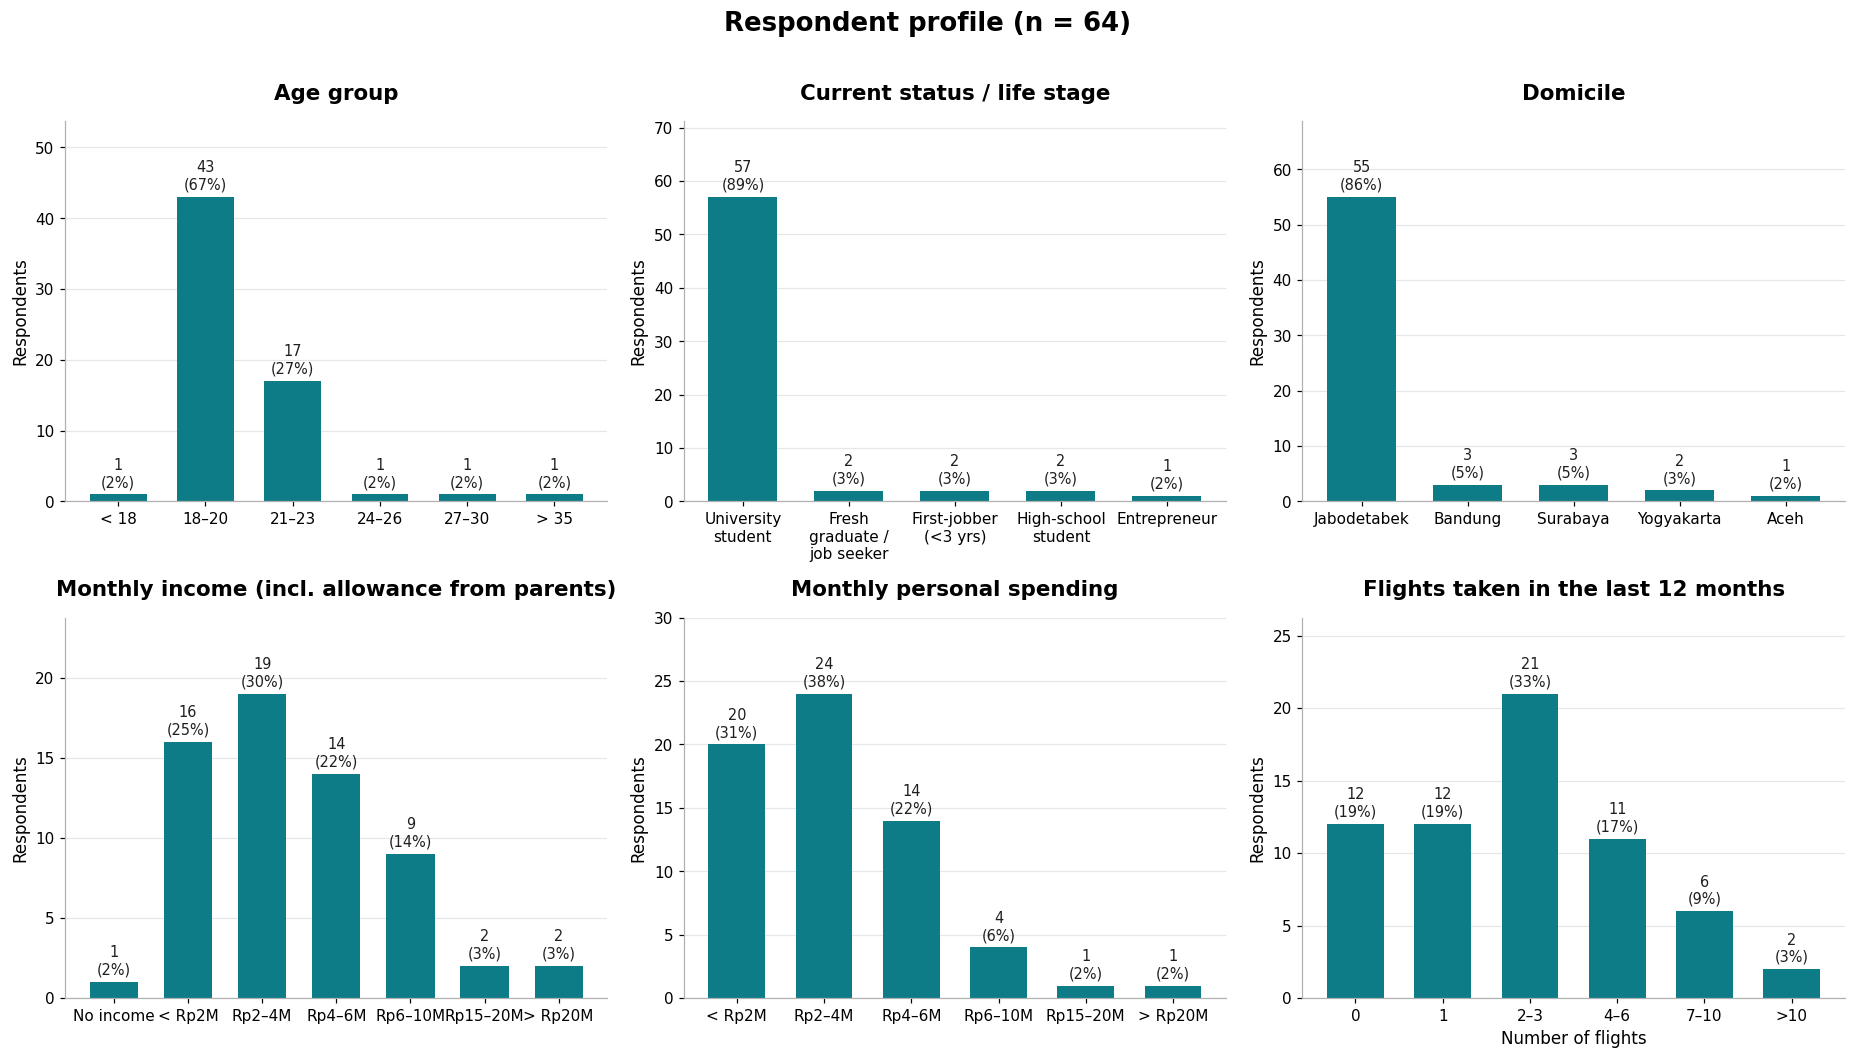

                     Share of sample
Age 18–23                        94%
University students              89%
Jabodetabek-based                86%
Flew in last 2 years             88%
Income ≤ Rp4M                    56%
Income > Rp6M                    20%


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9.5))
count_bar(df["age"], "Age group", order=AGE_ORDER, ax=axes[0, 0])
count_bar(df["status"], "Current status / life stage", ax=axes[0, 1], rotate=0)
count_bar(df["domicile"], "Domicile", ax=axes[0, 2])
count_bar(df["income"], "Monthly income (incl. allowance from parents)", order=MONEY_ORDER, ax=axes[1, 0])
count_bar(df["expense"], "Monthly personal spending", order=MONEY_ORDER, ax=axes[1, 1])
count_bar(df["flights_12m"], "Flights taken in the last 12 months", order=FREQ_ORDER, ax=axes[1, 2])
axes[1, 2].set_xlabel("Number of flights")
fig.suptitle(f"Respondent profile (n = {N})", fontsize=17, fontweight="bold", y=1.01)
finish(fig, "02_respondent_profile")

profile = pd.DataFrame({
    "Age 18–23": [f"{df['age'].isin(['18–20','21–23']).mean()*100:.0f}%"],
    "University students": [f"{(df['status']=='University student').mean()*100:.0f}%"],
    "Jabodetabek-based": [f"{(df['domicile']=='Jabodetabek').mean()*100:.0f}%"],
    "Flew in last 2 years": [f"{(df['flew_2y']=='Yes').mean()*100:.0f}%"],
    "Income ≤ Rp4M": [f"{df['income'].isin(['No income','< Rp2M','Rp2–4M']).mean()*100:.0f}%"],
    "Income > Rp6M": [f"{(df['income_tier']=='High (> Rp6M)').mean()*100:.0f}%"],
}, index=["Share of sample"]).T
print(profile.to_string())

**Reading the profile.** The sample is a tight youth cohort: almost everyone is 18-23 and a university student living in Greater Jakarta. Financially they are *budget-constrained but not homogeneous* - about half live on Rp2-6M a month, a quarter on less than Rp2M, and a fifth on more than Rp6M. Crucially for Garuda, **~88% have flown in the past two years**, so the survey reflects actual travellers, not hypothetical ones.

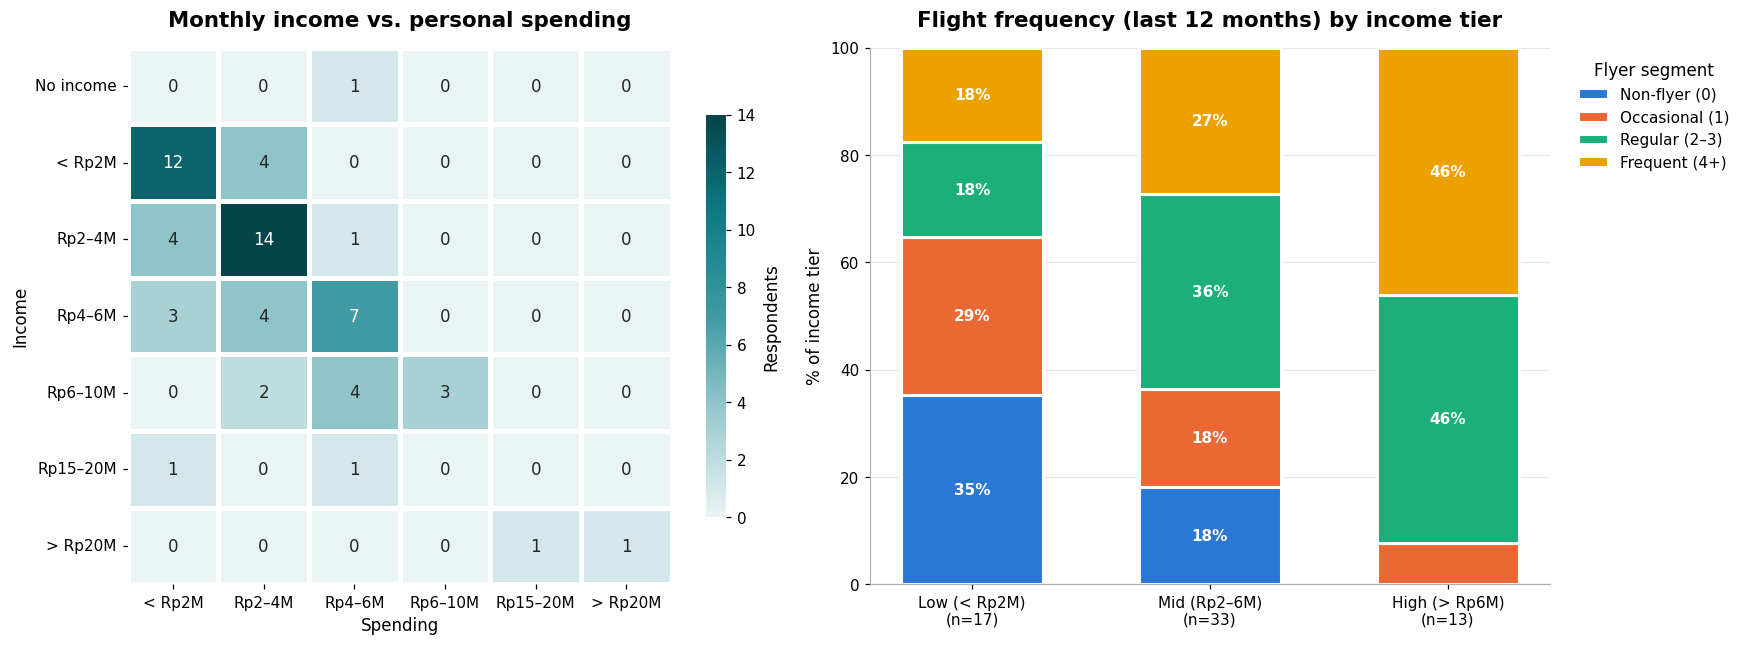

Share of respondents who are 'Frequent (4+)' flyers by income tier:
income_tier
Low (< Rp2M)     18.0
Mid (Rp2–6M)     27.0
High (> Rp6M)    46.0


In [8]:
# ---- Financial capacity: income vs spending, and flight frequency by income --
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ct = pd.crosstab(df["income"], df["expense"]).reindex(index=MONEY_ORDER, columns=MONEY_ORDER).dropna(how="all").dropna(axis=1, how="all").fillna(0).astype(int)
sns.heatmap(ct, annot=True, fmt="d", cmap=TEAL_CMAP, linewidths=2, linecolor="white", ax=axes[0],
            cbar_kws={"label": "Respondents", "shrink": 0.75})
axes[0].set_title("Monthly income vs. personal spending"); axes[0].set_xlabel("Spending"); axes[0].set_ylabel("Income")
axes[0].grid(False)

tab = pd.crosstab(df["income_tier"], df["flyer_segment"], normalize="index") * 100
tab = tab.loc[["Low (< Rp2M)", "Mid (Rp2–6M)", "High (> Rp6M)"]]
n_by = df["income_tier"].value_counts()
bottom = np.zeros(len(tab))
for i, seg in enumerate(tab.columns):
    bars = axes[1].bar([f"{t}\n(n={n_by[t]})" for t in tab.index], tab[seg], bottom=bottom, color=CAT[i], width=0.6,
                       label=seg, edgecolor="white", linewidth=2)
    for b, v in zip(bars, tab[seg]):
        if v >= 8:
            axes[1].text(b.get_x() + b.get_width()/2, b.get_y() + v/2, f"{v:.0f}%", ha="center", va="center", color="white", fontsize=10, fontweight="bold")
    bottom += tab[seg].values
axes[1].set_ylim(0, 100); axes[1].set_ylabel("% of income tier"); axes[1].set_title("Flight frequency (last 12 months) by income tier")
axes[1].legend(title="Flyer segment", bbox_to_anchor=(1.02, 1), loc="upper left"); axes[1].grid(axis="x", visible=False)
finish(fig, "02b_income_vs_spending_and_frequency")

print("Share of respondents who are 'Frequent (4+)' flyers by income tier:")
print((df.groupby("income_tier")["flyer_segment"].apply(lambda s: (s == "Frequent (4+)").mean()*100).round(0)).to_string())

**Insight - spending power tracks flight frequency.** Higher-income respondents fly far more often: frequent flyers (4+ trips a year) are rare in the low-income tier but common in the high-income tier. This matters for Garuda's business case: the most *valuable* youth segment is not "all students" but the sub-group with disposable income and a real travel rhythm - and, as Sections 8-9 show, it is precisely the group Garuda is currently losing.

## 3. Travel Behaviour & the Booking Journey

Why do young travelers fly, and where do they compare and buy tickets? This tells Garuda *where* to build awareness and *what trips* to design propositions around.

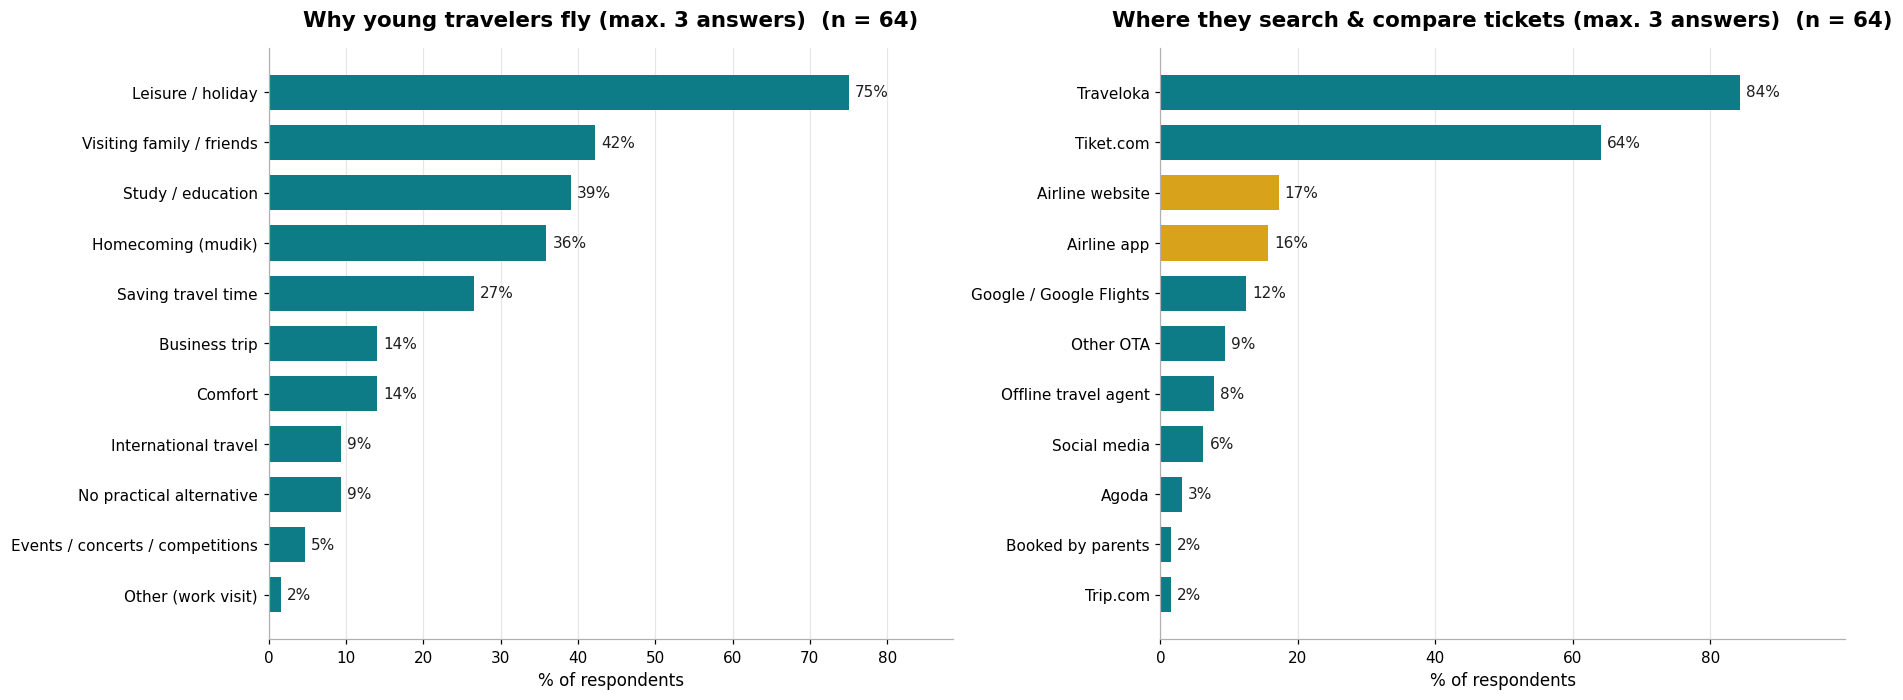

Use Traveloka and/or Tiket.com : 92%
Use ANY airline-direct channel  : 30%   (gold bars)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
hbar_pct(multi_pct("trip_purpose"), "Why young travelers fly (max. 3 answers)", ax=axes[0], n=N)
hbar_pct(multi_pct("booking_channels"), "Where they search & compare tickets (max. 3 answers)", ax=axes[1], n=N,
         highlight=["Airline website", "Airline app"])
finish(fig, "03_trip_purpose_and_channels")

direct = ((IND["booking_channels"]["Airline website"] + IND["booking_channels"]["Airline app"]) > 0).mean() * 100
ota    = ((IND["booking_channels"]["Traveloka"] + IND["booking_channels"]["Tiket.com"]) > 0).mean() * 100
print(f"Use Traveloka and/or Tiket.com : {ota:.0f}%")
print(f"Use ANY airline-direct channel  : {direct:.0f}%   (gold bars)")

**Insight - a leisure-and-family cohort that lives inside OTAs.** Three in four fly for holidays, and family visits, study-related trips and *mudik* (homecoming) follow - trips that are emotionally important yet highly price-benchmarked. The journey starts on **Traveloka (84%) and Tiket.com (64%)**, while fewer than one in three ever touch an airline's own website or app. For Garuda this means (1) the first impression is a *price-sorted OTA list*, where a full-service fare looks expensive by default, and (2) direct-channel benefits (bundles, GarudaMiles perks) are invisible to most young travelers unless they are surfaced inside OTAs or pushed through social media.

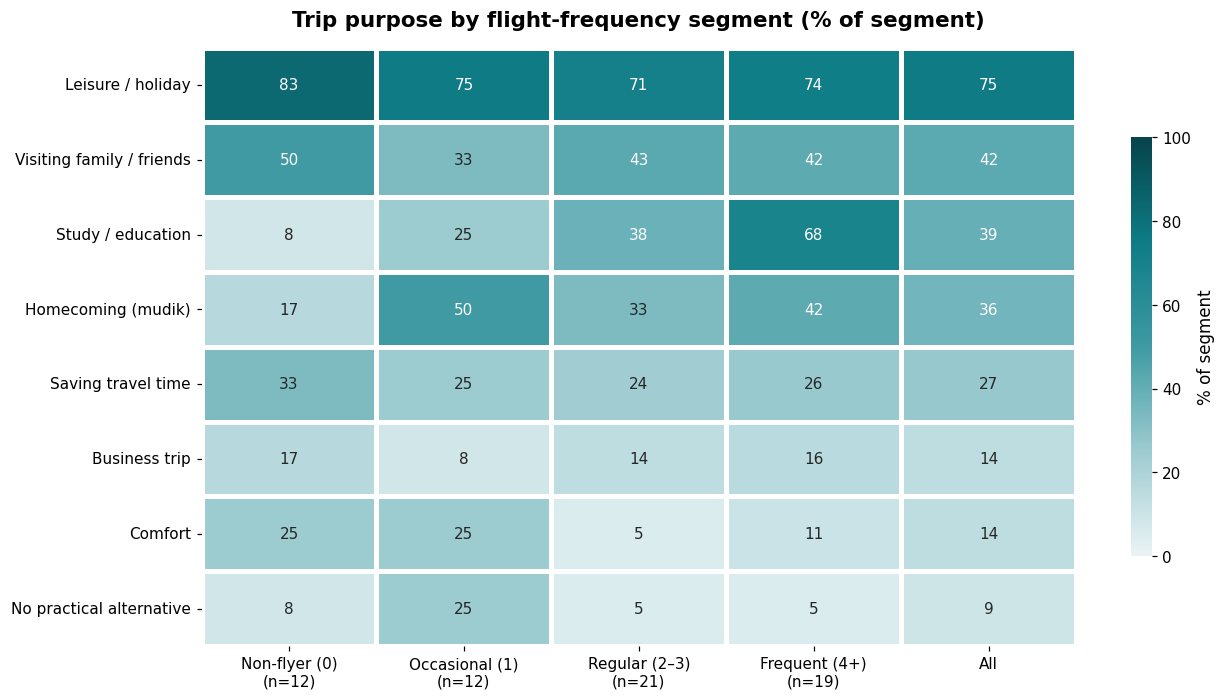

In [10]:
# ---- Trip purpose by flyer segment -----------------------------------------
fig, ax = plt.subplots(figsize=(12, 6.5))
seg_heatmap("trip_purpose", "flyer_segment", "Trip purpose by flight-frequency segment (% of segment)", top=8, ax=ax)
finish(fig, "03b_purpose_by_frequency")

Frequent flyers differ from the rest: **study/education trips are cited by 68% of frequent flyers versus at most 38% of the other segments**, and homecoming stays high for anyone who flies at all. This is a signal that **students from outside Jakarta who commute between campus and home** form a naturally high-frequency, predictable-route segment (e.g., Jakarta-Medan, Jakarta-Makassar, Jakarta-Denpasar) that a youth fare bundle could target.

## 4. What Drives Airline Choice?

Respondents picked up to five factors that most influence which airline they choose. This is the *consideration* stage of the funnel.

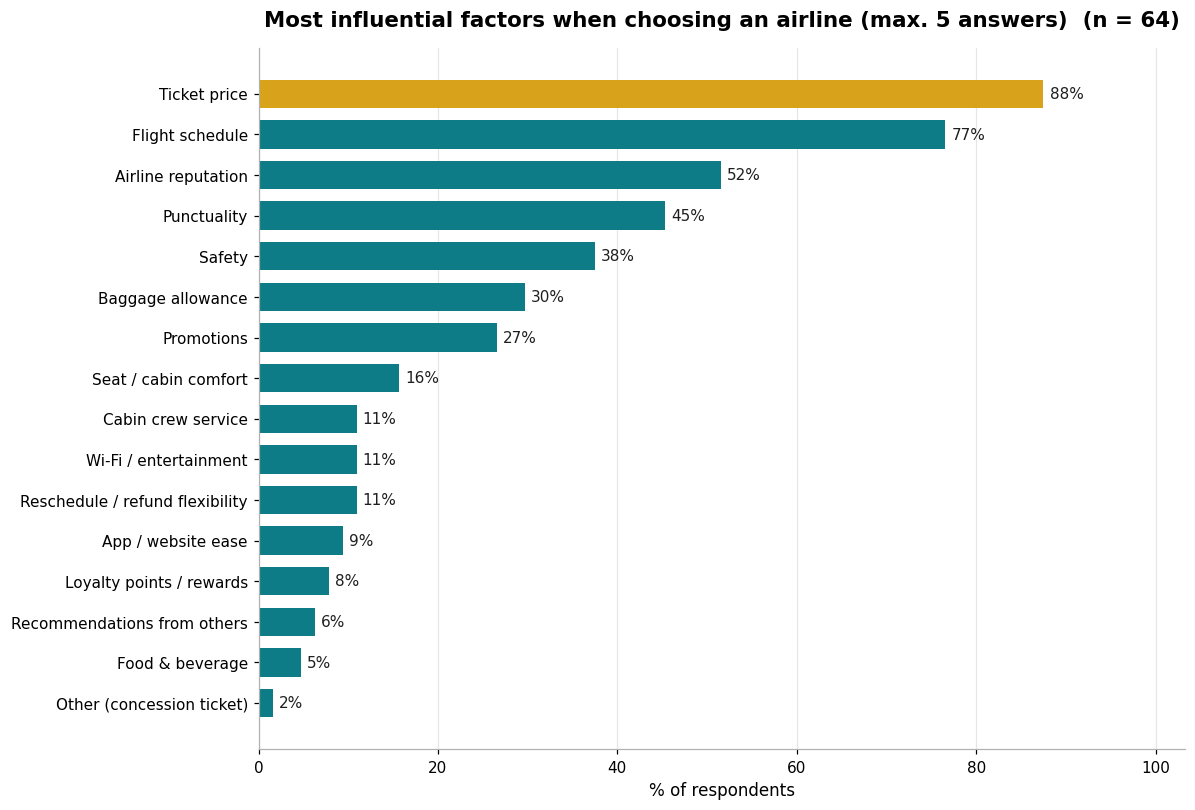

Chose 'Ticket price'                          : 88%
Chose price AND at least one quality factor  : 75%
Chose ONLY price/schedule/promo (no quality)  : 5%


In [11]:
fig, ax = hbar_pct(multi_pct("choice_factors"), "Most influential factors when choosing an airline (max. 5 answers)",
                   n=N, figsize=(11, 7.5), highlight=["Ticket price"])
finish(fig, "04_choice_factors")

cf = IND["choice_factors"]
quality = ["Airline reputation", "Punctuality", "Safety", "Seat / cabin comfort", "Cabin crew service"]
print(f"Chose 'Ticket price'                          : {cf['Ticket price'].mean()*100:.0f}%")
print(f"Chose price AND at least one quality factor  : {((cf['Ticket price']==1) & (cf[quality].sum(axis=1)>0)).mean()*100:.0f}%")
print(f"Chose ONLY price/schedule/promo (no quality)  : {((cf[['Ticket price','Flight schedule','Promotions']].sum(axis=1)==cf.sum(axis=1)) & (cf.sum(axis=1)>0)).mean()*100:.0f}%")

**Insight - price is the entry ticket, not the whole story.** 88% list ticket price and 77% flight schedule, but **reputation (52%), punctuality (45%) and safety (38%)** follow immediately - and the overwhelming majority who cite price *also* cite at least one quality factor. Only a small minority are "pure" price-schedule-promo choosers. Meanwhile classic full-service differentiators (cabin crew, food, Wi-Fi, loyalty) are chosen by fewer than 12%: **young travelers do not use soft in-flight extras to shortlist airlines - they use trust and reliability.**

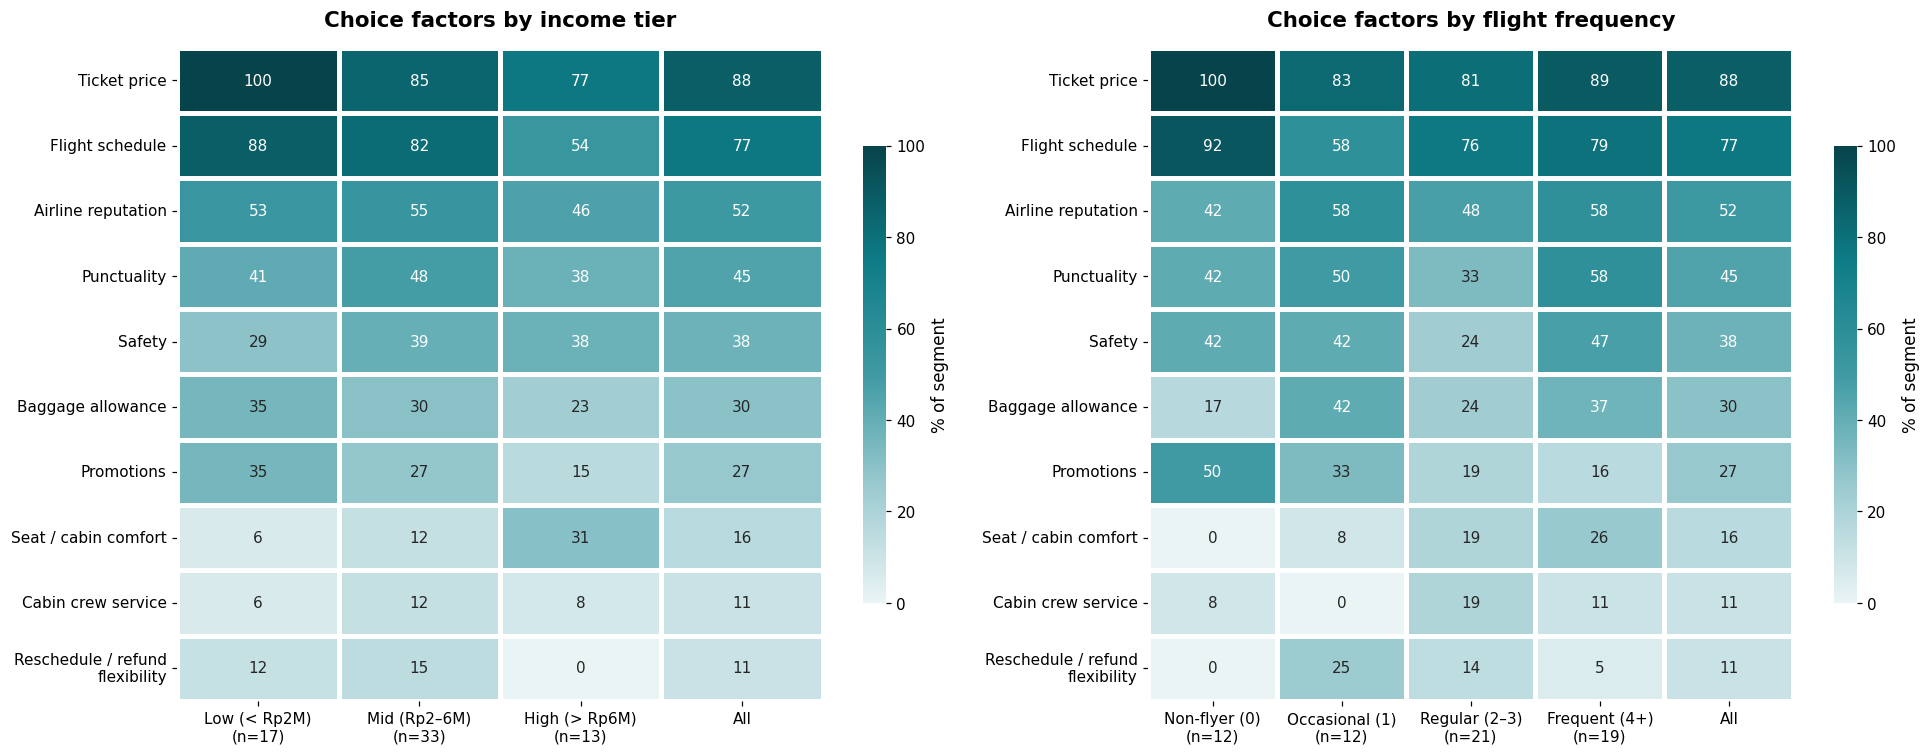

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
seg_heatmap("choice_factors", "income_tier", "Choice factors by income tier", top=10, ax=axes[0])
seg_heatmap("choice_factors", "flyer_segment", "Choice factors by flight frequency", top=10, ax=axes[1])
finish(fig, "04b_choice_factors_by_segment")

Price is universal in the low-income tier (100%) but softens with income (77% in the high tier), and the **high-income tier is the only group where seat / cabin comfort becomes a shortlisting factor (31% vs 6-12%)** while promotions fade (15%). Frequent flyers index highest on **punctuality (58%), reputation (58%) and baggage (37%)** - they have more to lose from delays and carry more - whereas non-flyers lean on promotions (50%). The natural full-service audience is therefore the *experienced, higher-income* young traveler, whose criteria already look like Garuda's proposition.

## 5. Price Sensitivity & Willingness to Pay for Premium

The case explicitly warns against winning through discounting. So: *how much* extra would young travelers pay for a demonstrably better experience, and *why* do they usually not choose the pricier airline?

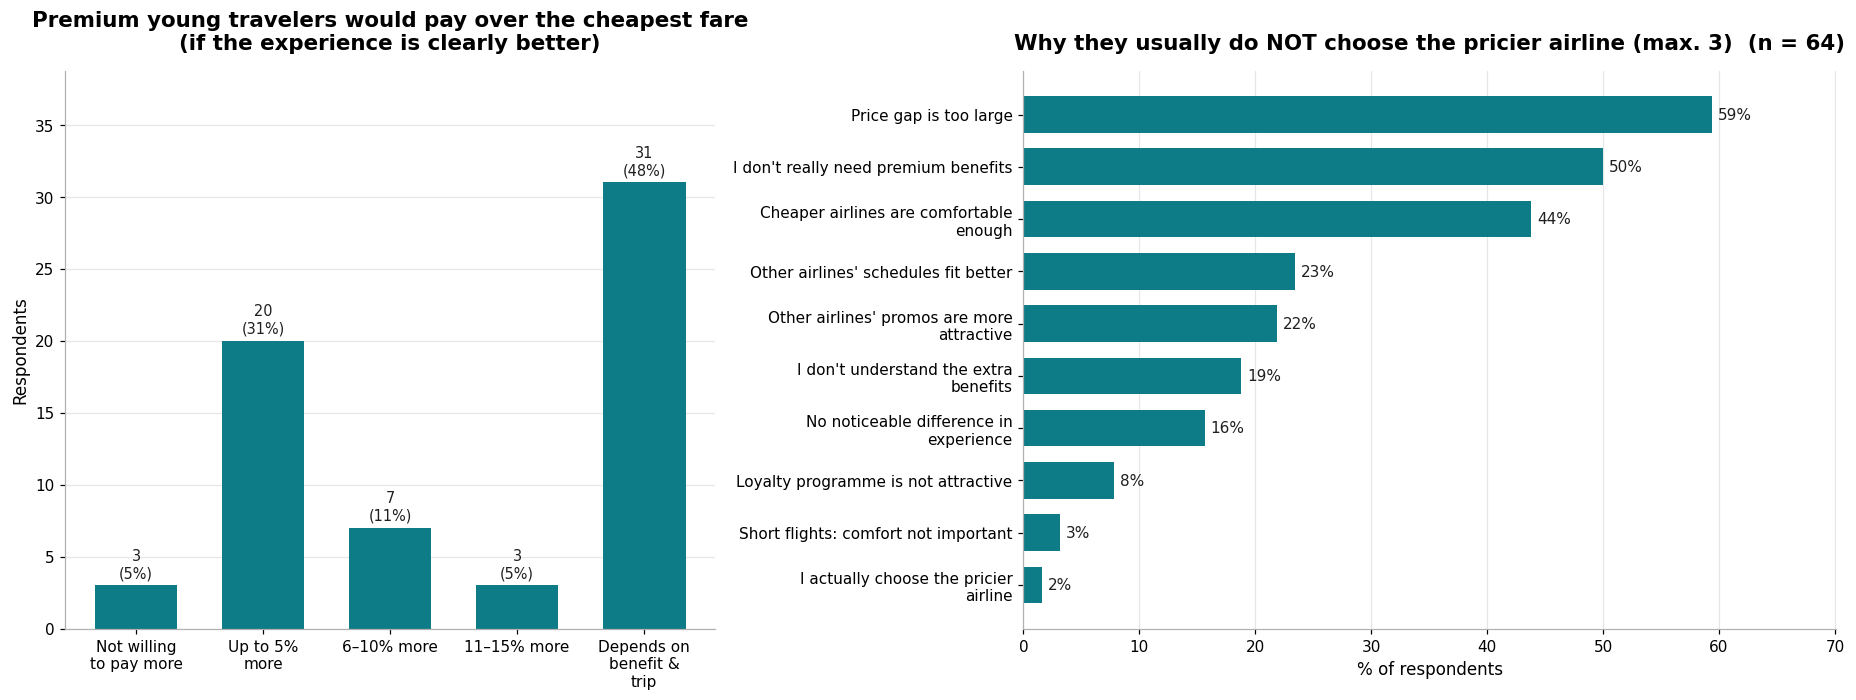

Would pay a *fixed* premium (5-15%)        : 47%
Conditional ('depends on benefit & trip')  : 48%
Refuse to pay more                         : 5%
Mean stated premium among fixed answers    : 6.5%

Barrier is about *understanding / relevance* (don't understand, no noticeable difference, don't need): 69% of respondents


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5), gridspec_kw={"width_ratios": [1, 1.25]})
count_bar(df["wtp_premium"], "Premium young travelers would pay over the cheapest fare\n(if the experience is clearly better)",
          order=WTP_ORDER, ax=axes[0], color=TEAL)
axes[0].set_ylabel("Respondents")
hbar_pct(multi_pct("reasons_not_premium"), "Why they usually do NOT choose the pricier airline (max. 3)", ax=axes[1], n=N, wrap_w=36)
finish(fig, "05_wtp_and_barriers")

any_premium = df["wtp_premium"].isin(["Up to 5% more", "6–10% more", "11–15% more"]).mean()*100
print(f"Would pay a *fixed* premium (5-15%)        : {any_premium:.0f}%")
print(f"Conditional ('depends on benefit & trip')  : {(df['wtp_premium']=='Depends on benefit & trip').mean()*100:.0f}%")
print(f"Refuse to pay more                         : {(df['wtp_premium']=='Not willing to pay more').mean()*100:.0f}%")
print(f"Mean stated premium among fixed answers    : {df['wtp_num'].mean():.1f}%")
rp = IND["reasons_not_premium"]
understanding = ["I don't understand the extra benefits", "No noticeable difference in experience", "I don't really need premium benefits"]
print(f"\nBarrier is about *understanding / relevance* (don't understand, no noticeable difference, don't need): "
      f"{(rp[understanding].sum(axis=1)>0).mean()*100:.0f}% of respondents")

**Insight - the WTP is real but small and conditional.** Only 5% refuse outright to pay more. Half say their willingness *depends on the benefit and the trip*, and a third would pay a modest fixed premium (mostly ≤5%). The barriers confirm the diagnosis: the price gap feels too large (59%), but almost as many say **they don't need the premium benefits (50%) or that cheaper airlines are comfortable enough (44%)** - and nearly one in five *don't understand what the extra benefits are*. The problem is not that youth refuse premium; it is that **Garuda's premium is not legible or relevant enough to justify the gap**.

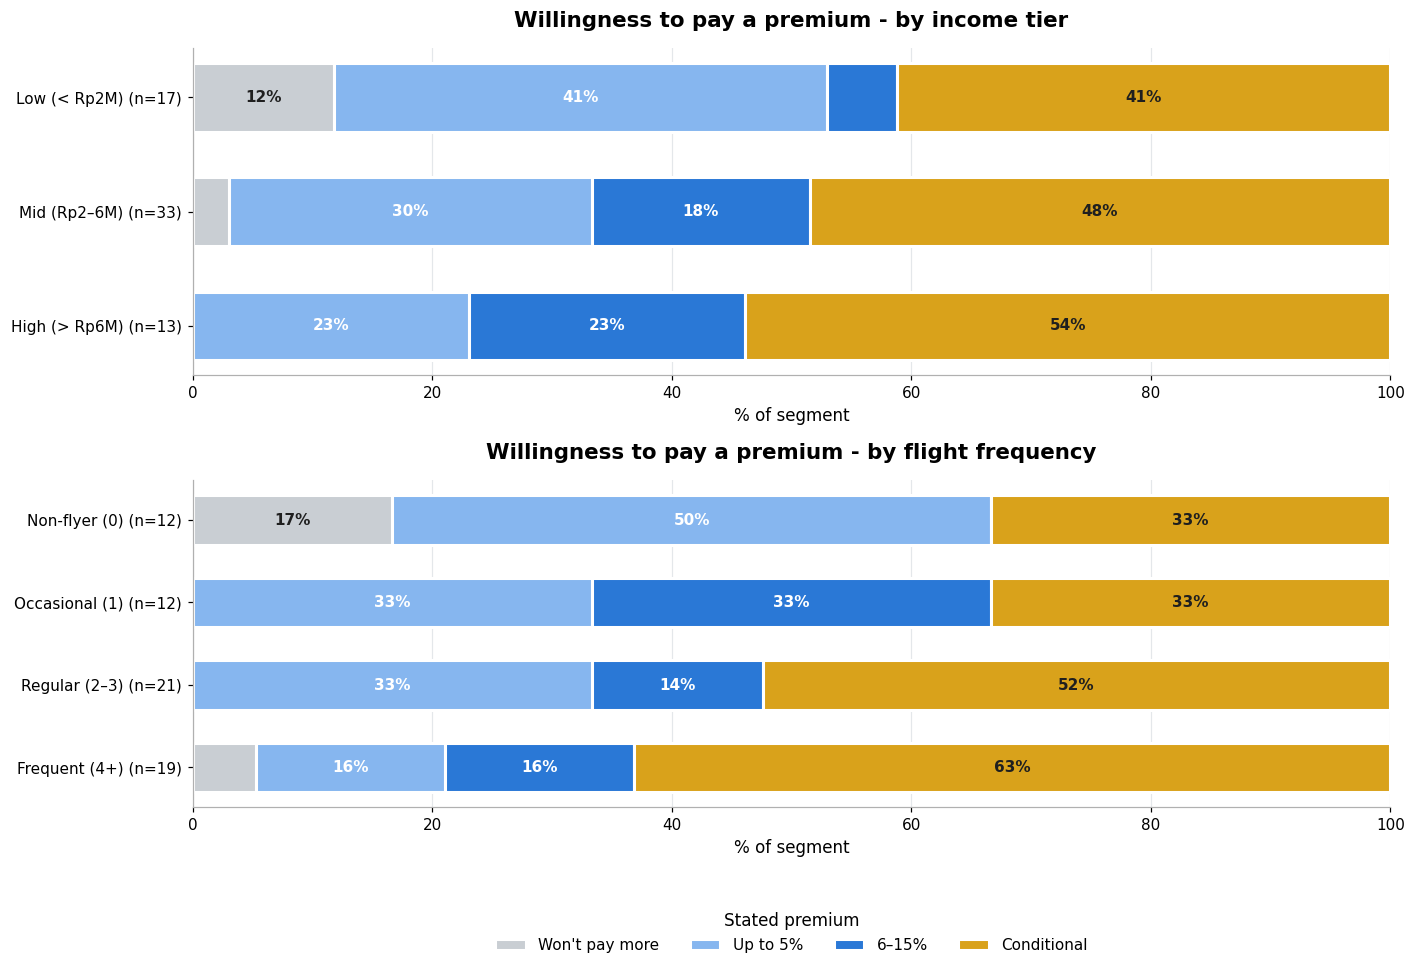

Spearman rho(income, fixed WTP %) = 0.30, p = 0.085  (n = 33)

Share answering 'Conditional' by flyer segment:
flyer_segment
Non-flyer (0)     33.0
Occasional (1)    33.0
Regular (2–3)     52.0
Frequent (4+)     63.0


In [14]:
# ---- WTP by income tier and by flight frequency (100% stacked) ----------------
def stacked_pct(seg, order_seg, ax, title):
    tab = pd.crosstab(df[seg], df["wtp_group"], normalize="index").reindex(columns=WTP_GROUP_ORDER).fillna(0) * 100
    tab = tab.loc[[o for o in order_seg if o in tab.index]]
    n_by = df[seg].value_counts()
    colors = ["#C9CED3", "#86B6EF", "#2A78D6", GOLD]
    bottom = np.zeros(len(tab))
    for i, g in enumerate(tab.columns):
        bars = ax.barh([f"{t} (n={n_by[t]})" for t in tab.index], tab[g], left=bottom, color=colors[i], label=g, height=0.6, edgecolor="white", linewidth=2)
        for b, v in zip(bars, tab[g]):
            if v >= 8:
                ax.text(b.get_x() + v/2, b.get_y() + b.get_height()/2, f"{v:.0f}%", ha="center", va="center", fontsize=10,
                        color=("white" if i in (1, 2) else INK), fontweight="bold")
        bottom += tab[g].values
    ax.set_xlim(0, 100); ax.set_xlabel("% of segment"); ax.set_title(title); ax.grid(axis="y", visible=False)
    ax.invert_yaxis()

fig, axes = plt.subplots(2, 1, figsize=(13, 9))
stacked_pct("income_tier", ["Low (< Rp2M)", "Mid (Rp2–6M)", "High (> Rp6M)"], axes[0], "Willingness to pay a premium - by income tier")
stacked_pct("flyer_segment", ["Non-flyer (0)", "Occasional (1)", "Regular (2–3)", "Frequent (4+)"], axes[1], "Willingness to pay a premium - by flight frequency")
axes[1].legend(title="Stated premium", ncol=4, bbox_to_anchor=(0.5, -0.28), loc="upper center")
finish(fig, "05b_wtp_by_segment")

# Simple ordinal test: does stated fixed WTP rise with income? (Spearman on respondents with a fixed answer)
sub = df.dropna(subset=["wtp_num", "income_mid"])
rho, p = stats.spearmanr(sub["income_mid"], sub["wtp_num"])
print(f"Spearman rho(income, fixed WTP %) = {rho:.2f}, p = {p:.3f}  (n = {len(sub)})")
print("\nShare answering 'Conditional' by flyer segment:")
print(df.groupby("flyer_segment")["wtp_group"].apply(lambda s: (s == "Conditional").mean()*100).round(0).to_string())

**Insight - conditionality grows with income and frequency.** Outright refusal exists only in the low-income tier (12%); the share willing to pay a fixed 6-15% rises from 6% (low) to 23% (high income), and the "it depends on the benefit" answer climbs from a third of non-flyers to **63% of frequent flyers**. That is the signature of a **value-seeking (not price-seeking) customer**: they can be moved to a higher fare, but only by a benefit that is specific to the trip - flexibility for a semester commute, baggage for a homecoming, punctuality for a competition or business trip.

## 6. What Makes a Premium Fare Feel "Worth It"?

Respondents chose up to five benefits that would most justify a higher fare. This is the raw material for Garuda's *youth value proposition*.

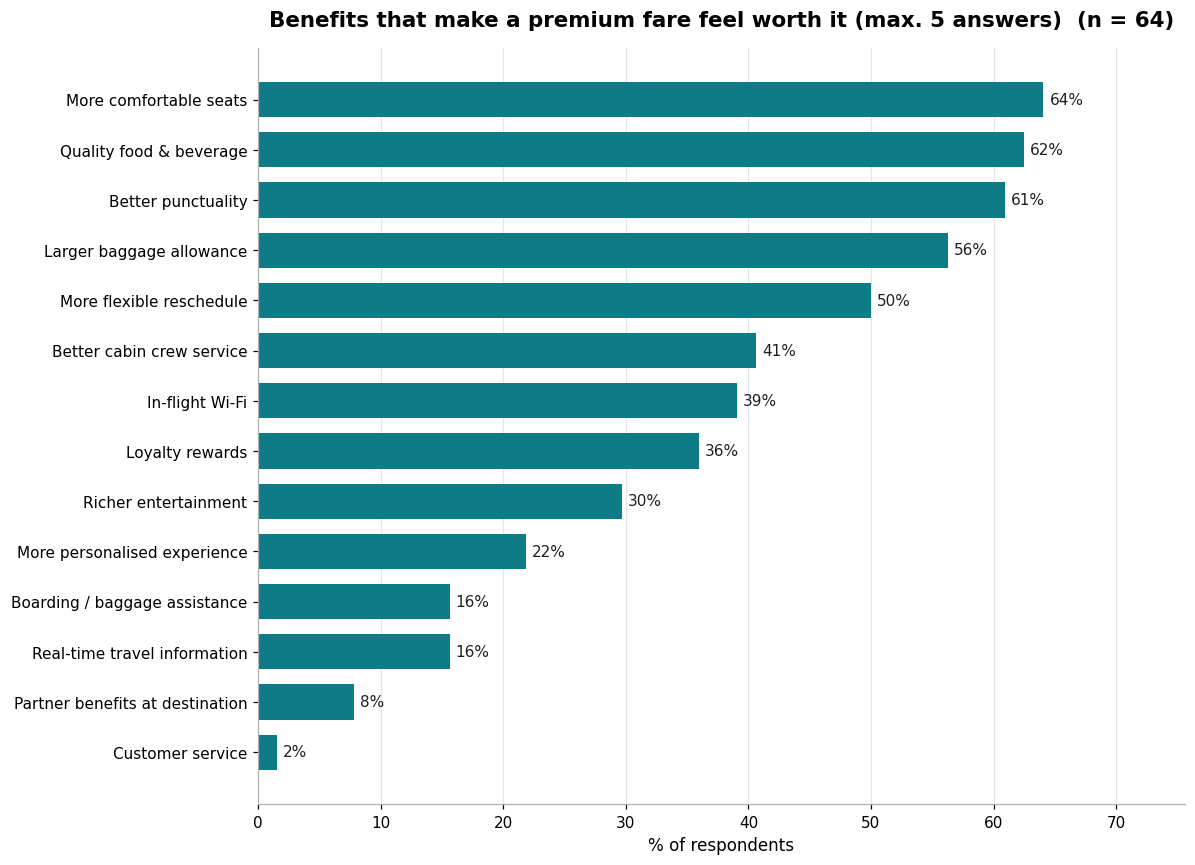

In [15]:
fig, ax = hbar_pct(multi_pct("worth_it_benefits"), "Benefits that make a premium fare feel worth it (max. 5 answers)",
                   n=N, figsize=(11, 8))
finish(fig, "06_worth_it_benefits")

**Insight - "premium" to Gen-Z means tangible, trip-critical basics.** The top five justifiers are **comfortable seats (64%), quality food & beverage (62%), better punctuality (61%), larger baggage (56%) and flexible rescheduling (50%)**. Softer or aspirational items - personalised experience, real-time information, partner perks at the destination - rank at the bottom. Garuda already delivers most of the top five; the gap is that young travelers do not *experience* or *see* them before purchase.

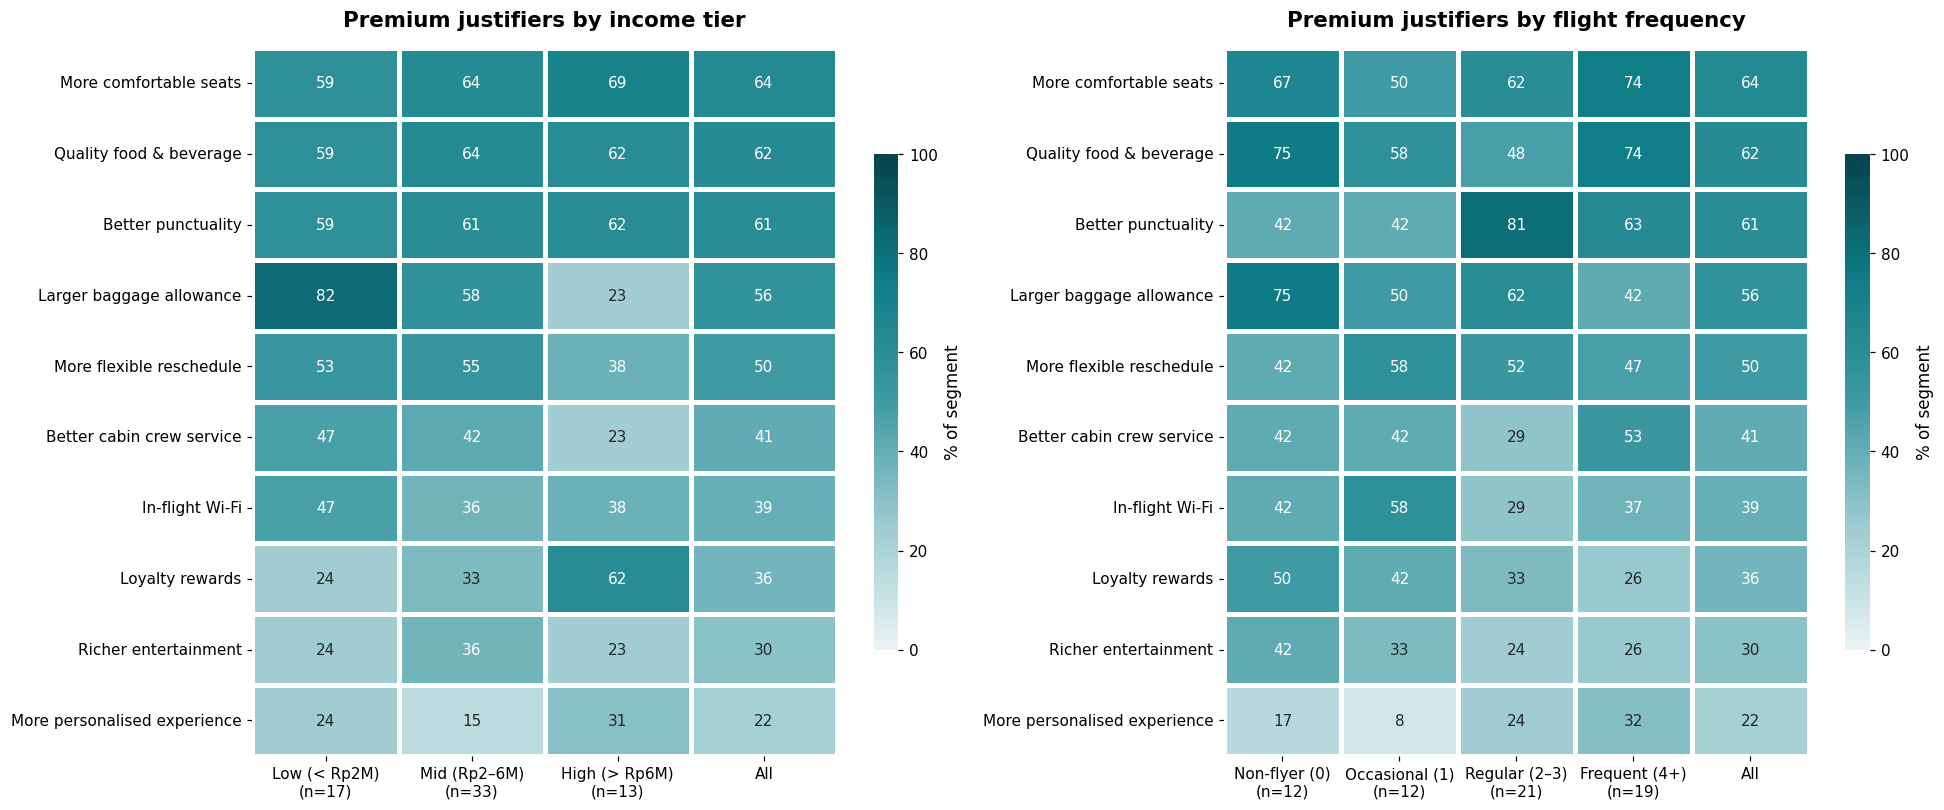

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
seg_heatmap("worth_it_benefits", "income_tier", "Premium justifiers by income tier", top=10, ax=axes[0])
seg_heatmap("worth_it_benefits", "flyer_segment", "Premium justifiers by flight frequency", top=10, ax=axes[1])
finish(fig, "06b_worth_it_by_segment")

**Insight - the same "premium" means different things by segment.** Seats, food and punctuality are universal, but **baggage is the #1 justifier for low-income respondents (82%) and almost irrelevant for the high-income tier (23%)**, while **loyalty rewards matter most to the high-income tier (62% vs 24%)**. Regular flyers (2-3 trips) put punctuality first (81%). A single premium message will not fit everyone: the entry-level youth bundle should lead with baggage & flexibility, while the affluent traveler should be courted with rewards, comfort and reliability.

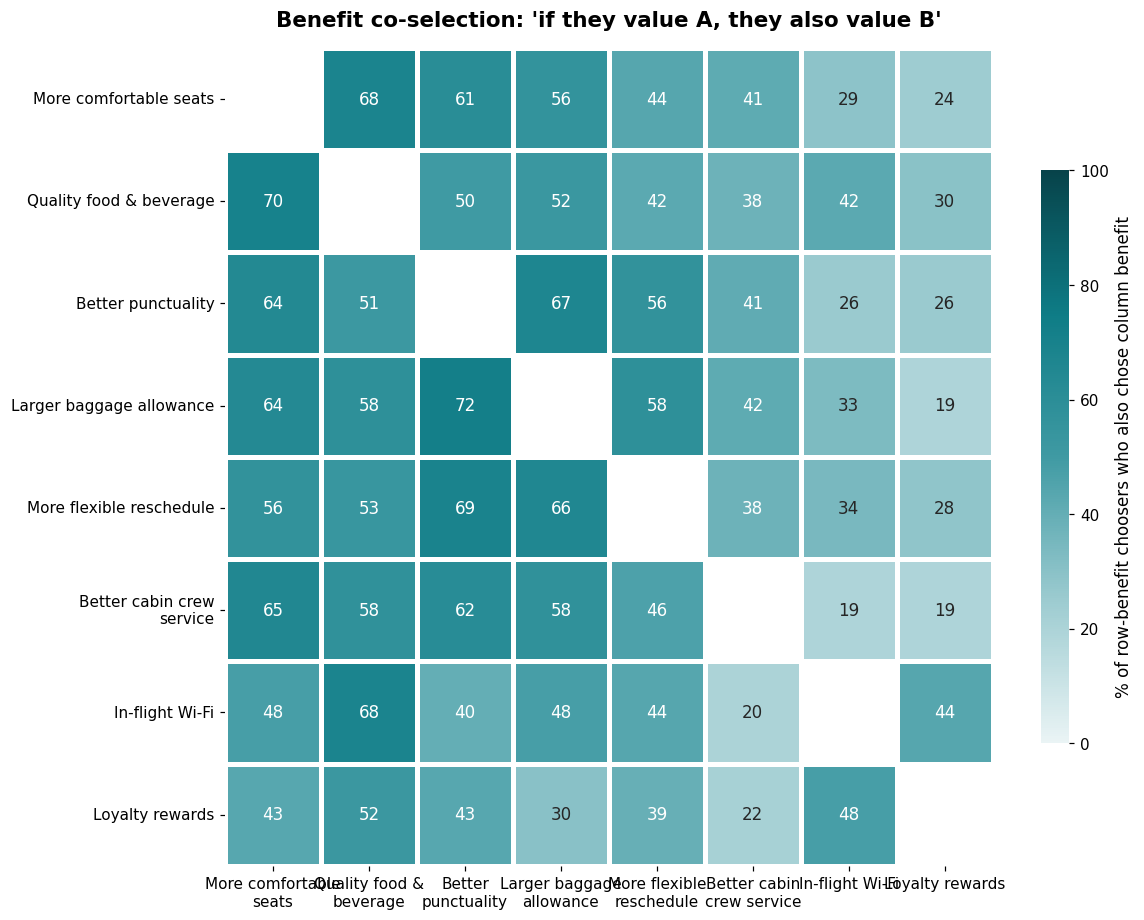

In [17]:
# ---- Which benefits are chosen TOGETHER? (co-selection / bundle logic) -------
wb = IND["worth_it_benefits"]
top8 = multi_pct("worth_it_benefits").head(8).index
co = pd.DataFrame(index=top8, columns=top8, dtype=float)
for a in top8:
    for b in top8:
        co.loc[a, b] = (wb[a] & wb[b]).sum() / wb[a].sum() * 100     # P(b | a)
fig, ax = plt.subplots(figsize=(11, 8.5))
mask = np.eye(len(top8), dtype=bool)
sns.heatmap(co.astype(float), annot=True, fmt=".0f", cmap=TEAL_CMAP, mask=mask, linewidths=2, linecolor="white",
            cbar_kws={"label": "% of row-benefit choosers who also chose column benefit", "shrink": 0.7}, ax=ax, vmin=0, vmax=100)
ax.set_xticklabels(wrap(top8, 16), rotation=0); ax.set_yticklabels(wrap(top8, 24), rotation=0)
ax.set_title("Benefit co-selection: 'if they value A, they also value B'"); ax.grid(False)
finish(fig, "06c_benefit_cooccurrence")

**Bundle logic.** Benefits cluster naturally: seat comfort travels with food & beverage (~70% co-selection - an *on-board comfort* bundle), while baggage, punctuality and flexible rescheduling travel together (66-72% - a *travel-certainty* bundle). In-flight Wi-Fi pairs with food and with loyalty rewards rather than with the certainty items. Two clear proposition archetypes emerge for a youth fare family: **"Comfort+"** (seat, meal, connectivity) and **"Certainty+"** (baggage, flexibility, on-time promise).

## 7. Attitude Statements - What Is Truly Valued vs. Merely Expected?

Seventeen statements were rated on a 1-5 agreement scale (1 = strongly disagree, 5 = strongly agree). We look at the distribution of every statement, group them into five themes, and then contrast *stated importance* with *willingness to pay for it*.

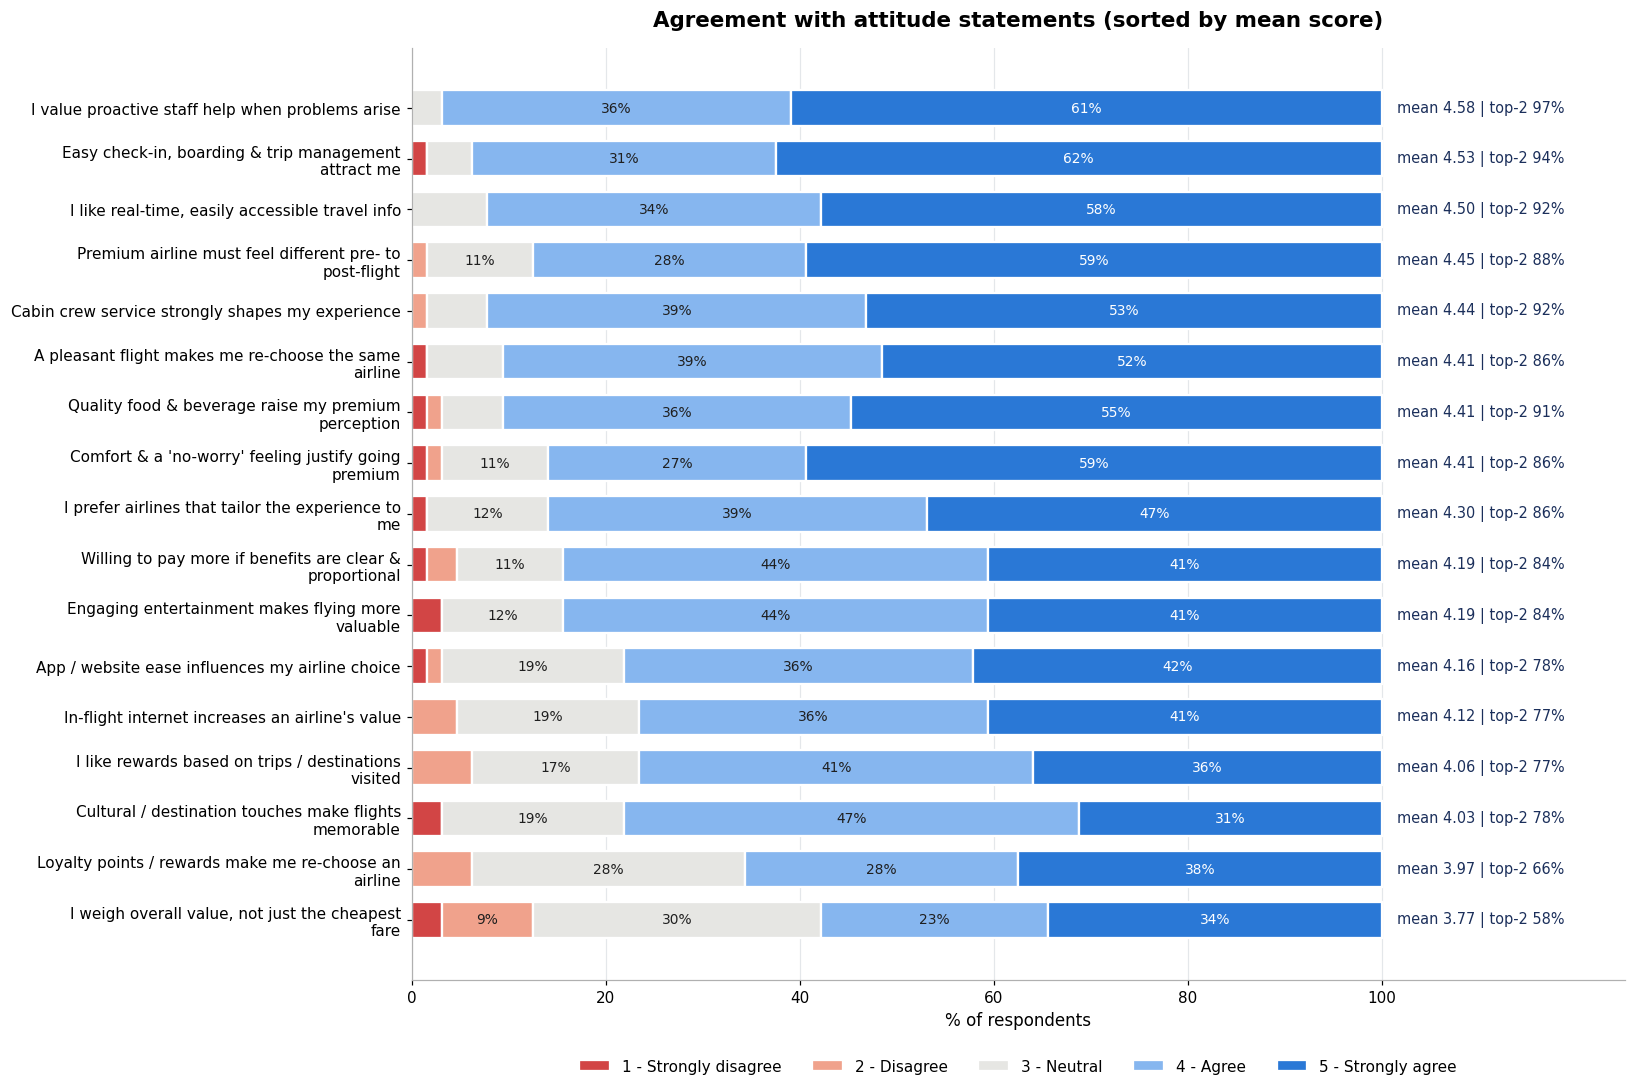

                                                          Mean (1-5)  Top-2-box %   Std
I value proactive staff help when problems arise                4.58         97.0  0.56
Easy check-in, boarding & trip management attract me            4.53         94.0  0.73
I like real-time, easily accessible travel info                 4.50         92.0  0.64
Premium airline must feel different pre- to post-flight         4.45         88.0  0.75
Cabin crew service strongly shapes my experience                4.44         92.0  0.69
Comfort & a 'no-worry' feeling justify going premium            4.41         86.0  0.87
Quality food & beverage raise my premium perception             4.41         91.0  0.81
A pleasant flight makes me re-choose the same airline           4.41         86.0  0.78
I prefer airlines that tailor the experience to me              4.30         86.0  0.81
Willing to pay more if benefits are clear & proportional        4.19         84.0  0.87
Engaging entertainment makes fly

In [18]:
# ---- Diverging stacked bar of all Likert items ------------------------------
dist = pd.DataFrame({c: df[c].round().value_counts(normalize=True).reindex([1,2,3,4,5]).fillna(0)*100 for c in LIKERT_COLS}).T
means = df[LIKERT_COLS].mean()
top2  = (df[LIKERT_COLS] >= 4).mean()*100
order = means.sort_values().index

fig, ax = plt.subplots(figsize=(15, 10))
left = np.zeros(len(order))
labels_scale = ["1 - Strongly disagree", "2 - Disagree", "3 - Neutral", "4 - Agree", "5 - Strongly agree"]
for i, sc in enumerate([1,2,3,4,5]):
    vals = dist.loc[order, sc].values
    bars = ax.barh(range(len(order)), vals, left=left, color=LIKERT_COLORS[i], label=labels_scale[i], height=0.7, edgecolor="white", linewidth=1.5)
    for j, (v, l) in enumerate(zip(vals, left)):
        if v >= 9:
            ax.text(l + v/2, j, f"{v:.0f}%", ha="center", va="center", fontsize=9, color=("white" if sc in (1,5) else INK))
    left += vals
for j, c in enumerate(order):
    ax.text(101.5, j, f"mean {means[c]:.2f} | top-2 {top2[c]:.0f}%", va="center", fontsize=9.5, color=NAVY)
ax.set_yticks(range(len(order))); ax.set_yticklabels(wrap([LIKERT_LABELS[c] for c in order], 48), fontsize=10)
ax.set_xlim(0, 125); ax.set_xticks([0, 20, 40, 60, 80, 100]); ax.set_xlabel("% of respondents"); ax.set_title("Agreement with attitude statements (sorted by mean score)")
ax.legend(ncol=5, bbox_to_anchor=(0.5, -0.07), loc="upper center"); ax.grid(axis="y", visible=False)
finish(fig, "07_likert_distribution")

summary = pd.DataFrame({"Mean (1-5)": means.round(2), "Top-2-box %": top2.round(0), "Std": df[LIKERT_COLS].std().round(2)})
summary.index = [LIKERT_LABELS[c] for c in summary.index]
print(summary.sort_values("Mean (1-5)", ascending=False).to_string())

**Insight - service, ease and peace of mind score highest; pure price-indifference scores lowest.** The strongest agreement is with *proactive staff help*, *easy check-in/boarding*, *real-time information*, *premium must feel different end-to-end* and *comfort / no-worry feeling*. The single weakest statement is "I weigh overall value, not just the cheapest fare" (mean ≈ 3.8, only 58% agree) - **young travelers agree that great service matters, yet admit that in the moment of booking the cheapest fare still wins.** Loyalty points are the most *divided* item (high spread), suggesting today's miles programmes do not resonate with all youth.

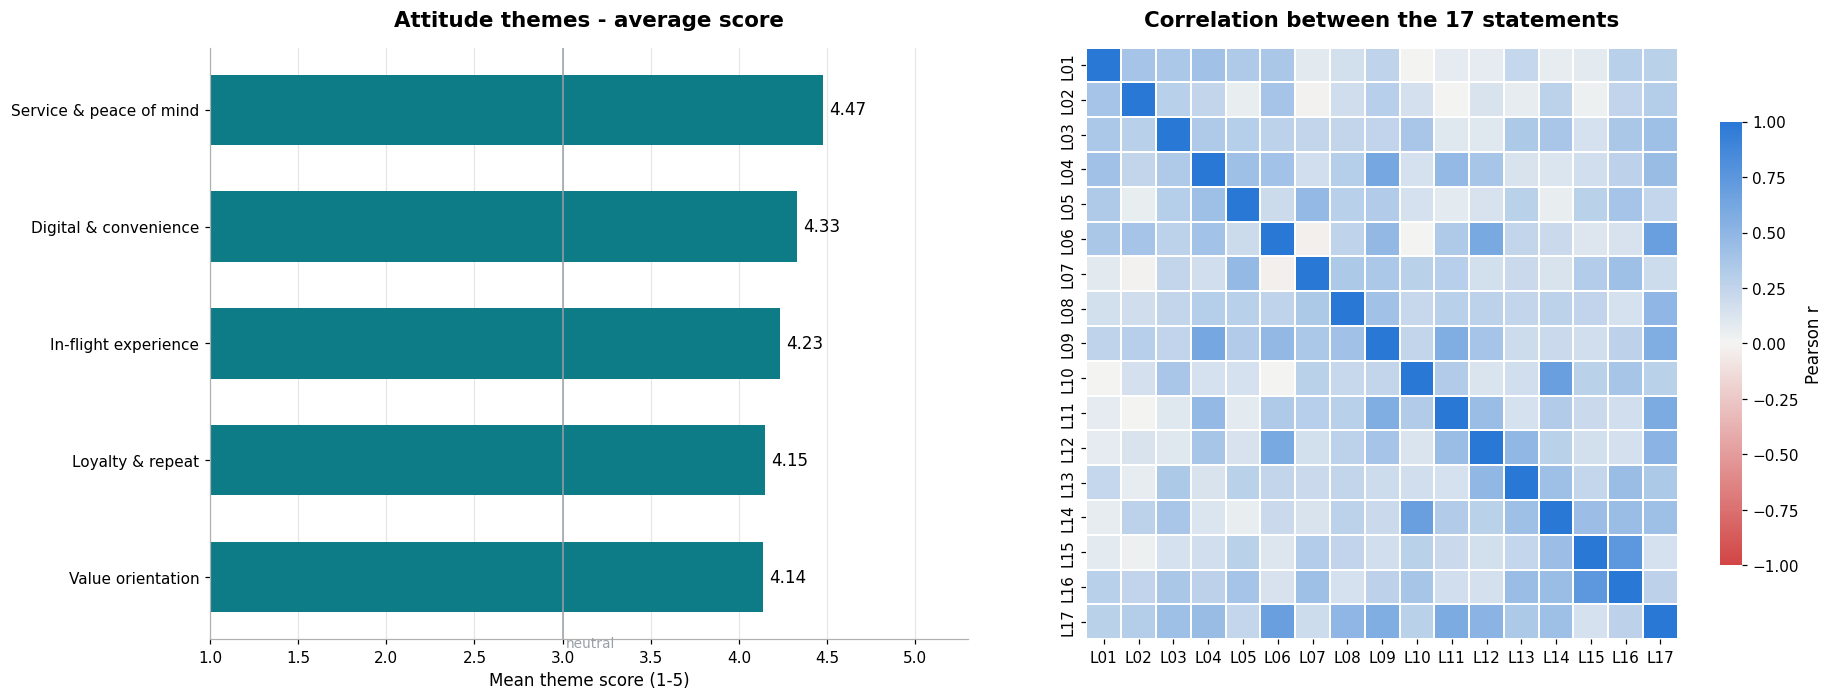

Statement codes:
  L01 = Willing to pay more if benefits are clear & proportional
  L02 = I weigh overall value, not just the cheapest fare
  L03 = Premium airline must feel different pre- to post-flight
  L04 = App / website ease influences my airline choice
  L05 = I like real-time, easily accessible travel info
  L06 = Easy check-in, boarding & trip management attract me
  L07 = In-flight internet increases an airline's value
  L08 = I prefer airlines that tailor the experience to me
  L09 = Engaging entertainment makes flying more valuable
  L10 = Quality food & beverage raise my premium perception
  L11 = Cultural / destination touches make flights memorable
  L12 = Cabin crew service strongly shapes my experience
  L13 = I value proactive staff help when problems arise
  L14 = Comfort & a 'no-worry' feeling justify going premium
  L15 = Loyalty points / rewards make me re-choose an airline
  L16 = I like rewards based on trips / destinations visited
  L17 = A pleasant flight make

In [19]:
# ---- Theme scores and correlation between statements ------------------------
theme_means = df[THEME_COLS].mean().rename(lambda s: s.replace("theme_", "")).sort_values()
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5), gridspec_kw={"width_ratios": [1, 1.1]})
bars = axes[0].barh(theme_means.index, theme_means.values, color=TEAL, height=0.6)
axes[0].bar_label(bars, labels=[f"{v:.2f}" for v in theme_means.values], padding=4)
axes[0].axvline(3, color=GREY, linewidth=1); axes[0].text(3.02, -0.6, "neutral", color=GREY, fontsize=9)
axes[0].set_xlim(1, 5.3); axes[0].set_xlabel("Mean theme score (1-5)"); axes[0].set_title("Attitude themes - average score"); axes[0].grid(axis="y", visible=False)

corr = df[LIKERT_COLS].corr()
corr.index = corr.columns = [c[:3] for c in LIKERT_COLS]
sns.heatmap(corr, cmap=LinearSegmentedColormap.from_list("div", ["#D24545", "#F4F4F2", "#2A78D6"]), vmin=-1, vmax=1, center=0,
            square=True, linewidths=1, linecolor="white", ax=axes[1], cbar_kws={"shrink": 0.75, "label": "Pearson r"})
axes[1].set_title("Correlation between the 17 statements"); axes[1].grid(False)
finish(fig, "07b_theme_scores_and_correlation")
print("Statement codes:")
for c in LIKERT_COLS:
    print(f"  {c[:3]} = {LIKERT_LABELS[c]}")

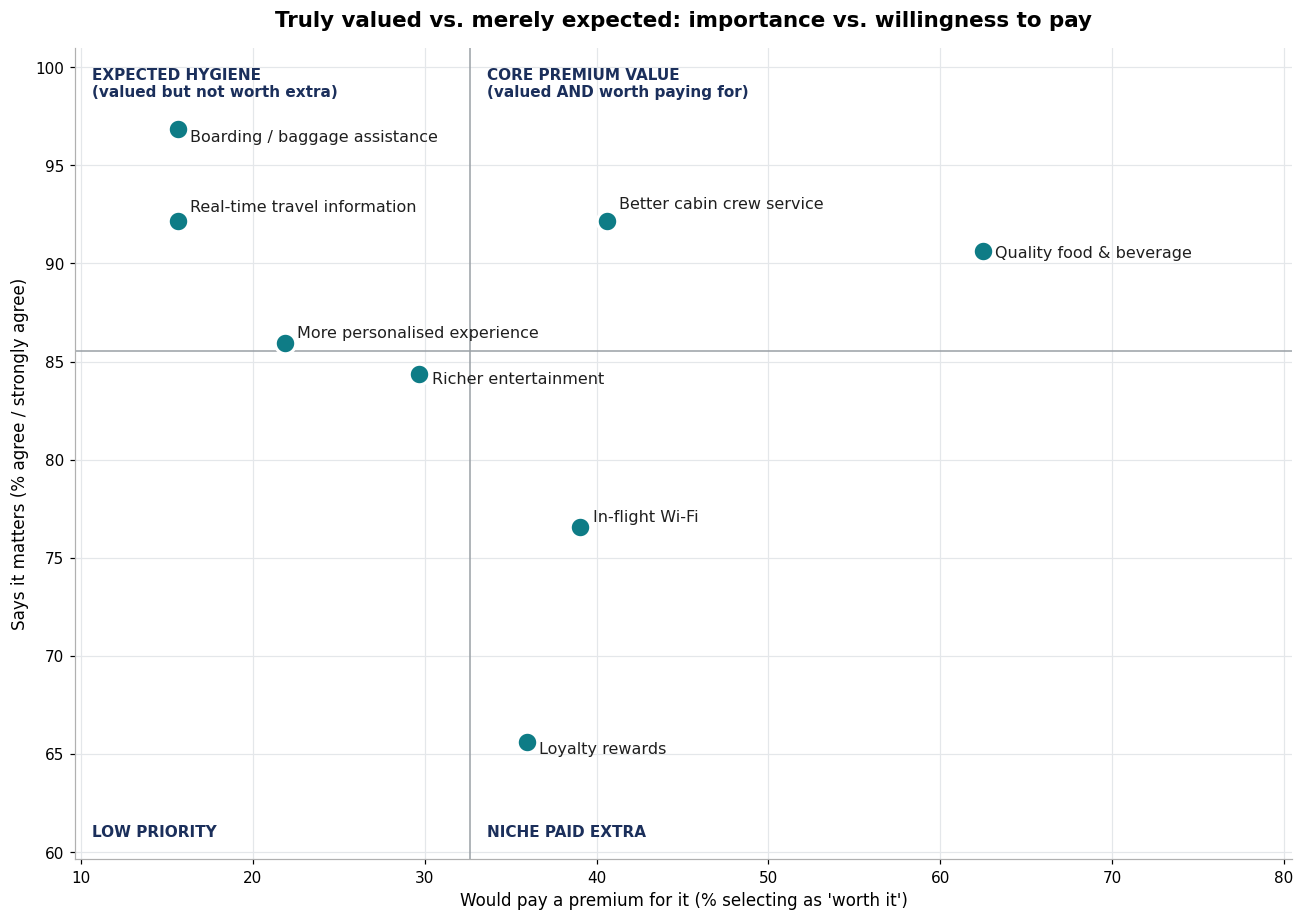

                               Would pay for it (%)  Say it matters (top-2-box %)
Quality food & beverage                        62.0                          91.0
Better cabin crew service                      41.0                          92.0
In-flight Wi-Fi                                39.0                          77.0
Loyalty rewards                                36.0                          66.0
Richer entertainment                           30.0                          84.0
More personalised experience                   22.0                          86.0
Real-time travel information                   16.0                          92.0
Boarding / baggage assistance                  16.0                          97.0


In [20]:
# ---- VALUED vs EXPECTED matrix ----------------------------------------------
# x = share who would PAY for the benefit (worth-it selection), y = share who say it matters (Likert top-2-box)
pairs = {
    "Quality food & beverage":      "L10_food_quality",
    "In-flight Wi-Fi":              "L07_inflight_internet",
    "Richer entertainment":         "L09_entertainment",
    "Better cabin crew service":    "L12_cabin_crew_service",
    "Loyalty rewards":              "L15_loyalty_points",
    "More personalised experience": "L08_personalised_experience",
    "Real-time travel information": "L05_realtime_info",
    "Boarding / baggage assistance":"L13_proactive_staff",
}
wi = multi_pct("worth_it_benefits")
mat = pd.DataFrame({"Would pay for it (%)": [wi[k] for k in pairs],
                    "Say it matters (top-2-box %)": [top2[v] for v in pairs.values()]}, index=list(pairs))
xm, ym = mat.iloc[:, 0].mean(), mat.iloc[:, 1].mean()

fig, ax = plt.subplots(figsize=(12, 8.5))
ax.axvline(xm, color=GREY, linewidth=1); ax.axhline(ym, color=GREY, linewidth=1)
ax.scatter(mat.iloc[:, 0], mat.iloc[:, 1], s=180, color=TEAL, edgecolor="white", linewidth=2, zorder=3)
offsets = {"Quality food & beverage": (8, -4), "In-flight Wi-Fi": (8, 4), "Richer entertainment": (8, -6),
           "Better cabin crew service": (8, 8), "Loyalty rewards": (8, -8), "More personalised experience": (8, 4),
           "Real-time travel information": (8, 6), "Boarding / baggage assistance": (8, -8)}
for name, (x, y) in mat.iterrows():
    dx, dy = offsets.get(name, (8, 4))
    ax.annotate(name, (x, y), xytext=(dx, dy), textcoords="offset points", fontsize=10.5, color=INK,
                ha=("right" if dx < 0 else "left"))
x_lo, x_hi = mat.iloc[:,0].min() - 6, mat.iloc[:,0].max() + 18
y_lo = mat.iloc[:,1].min() - 6
ax.text(xm + 1, 100, "CORE PREMIUM VALUE\n(valued AND worth paying for)", color=NAVY, fontsize=10, fontweight="bold", va="top")
ax.text(x_lo + 1, 100, "EXPECTED HYGIENE\n(valued but not worth extra)", color=NAVY, fontsize=10, fontweight="bold", va="top")
ax.text(xm + 1, y_lo + 1, "NICHE PAID EXTRA", color=NAVY, fontsize=10, fontweight="bold", va="bottom")
ax.text(x_lo + 1, y_lo + 1, "LOW PRIORITY", color=NAVY, fontsize=10, fontweight="bold", va="bottom")
ax.set_xlabel("Would pay a premium for it (% selecting as 'worth it')"); ax.set_ylabel("Says it matters (% agree / strongly agree)")
ax.set_xlim(x_lo, x_hi); ax.set_ylim(y_lo, 101)
ax.set_title("Truly valued vs. merely expected: importance vs. willingness to pay")
finish(fig, "07c_valued_vs_expected")
print(mat.round(0).sort_values("Would pay for it (%)", ascending=False).to_string())

**Insight - the "premium paradox".** Almost every benefit is *rated important* (80-97% agreement) but only a few *command a premium*. **Food & beverage and cabin crew service** sit in the core-value quadrant: valued *and* worth paying for. **Real-time information, proactive assistance and a personalised experience are hygiene**: young travelers expect them from any airline and will not pay extra - so Garuda should deliver them flawlessly but *not* price them. **In-flight Wi-Fi and loyalty rewards are "niche paid extras"**: fewer people say they matter, yet more than a third would pay for them - ideal as optional add-ons or as the hook for a specific segment rather than as part of the core bundle. Loyalty rewards in particular are the *least agreed-upon* statement of all, which reads as a redesign opportunity for GarudaMiles rather than a selling point in its current form.

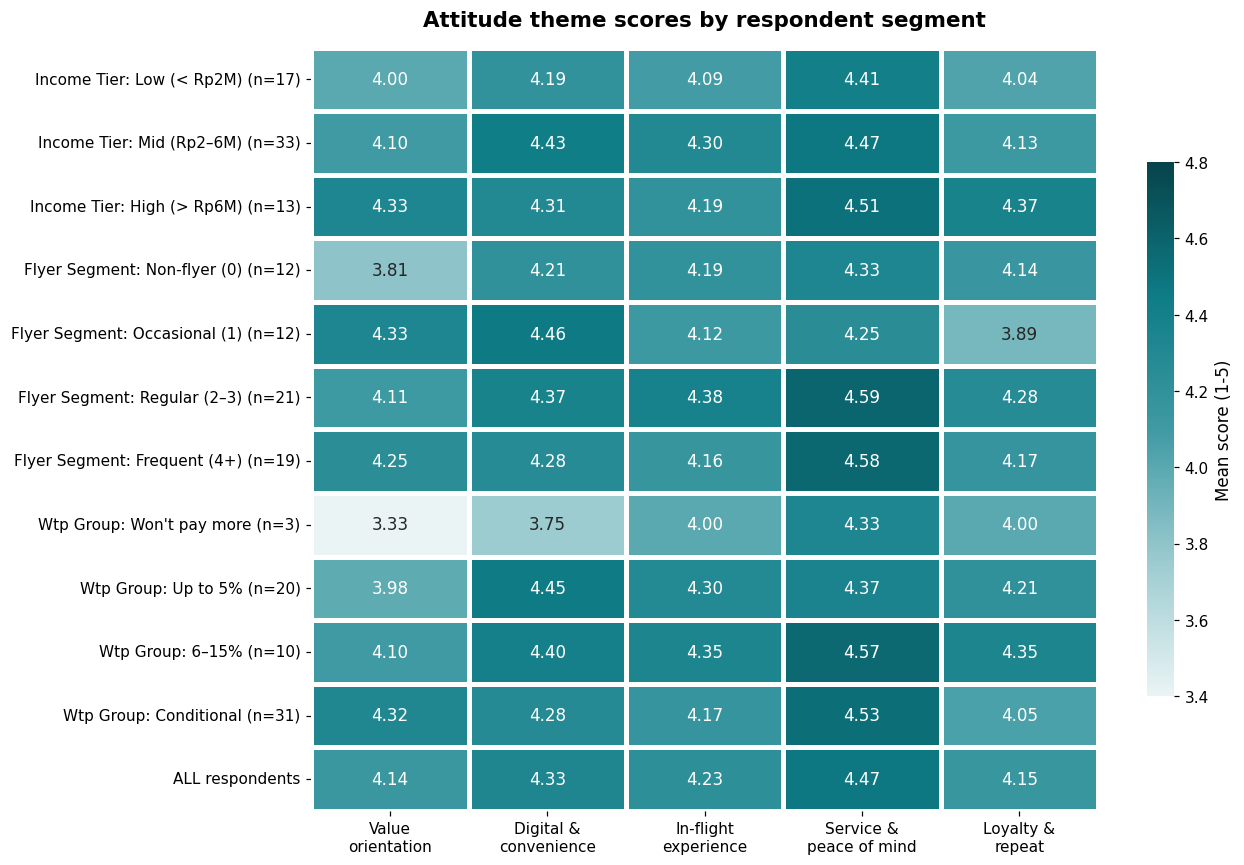

In [21]:
# ---- Theme scores by segment (do attitudes differ by who you are?) -----------
seg_tables = []
for seg, order_ in [("income_tier", ["Low (< Rp2M)", "Mid (Rp2–6M)", "High (> Rp6M)"]),
                    ("flyer_segment", ["Non-flyer (0)", "Occasional (1)", "Regular (2–3)", "Frequent (4+)"]),
                    ("wtp_group", WTP_GROUP_ORDER)]:
    t = df.groupby(seg)[THEME_COLS].mean().reindex(order_)
    t.index = [f"{seg.replace('_',' ').title()}: {i} (n={int((df[seg]==i).sum())})" for i in t.index]
    seg_tables.append(t)
seg_tab = pd.concat(seg_tables); seg_tab.columns = [c.replace("theme_", "") for c in seg_tab.columns]
seg_tab.loc["ALL respondents"] = df[THEME_COLS].mean().values

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(seg_tab, annot=True, fmt=".2f", cmap=TEAL_CMAP, vmin=3.4, vmax=4.8, linewidths=2, linecolor="white", ax=ax,
            cbar_kws={"label": "Mean score (1-5)", "shrink": 0.7})
ax.set_title("Attitude theme scores by respondent segment"); ax.set_xlabel(""); ax.set_ylabel(""); ax.grid(False)
ax.set_xticklabels(wrap(seg_tab.columns, 14), rotation=0)
finish(fig, "07d_theme_by_segment")

Attitudes are remarkably consistent across income and frequency: service & peace of mind is the top theme in every segment. The clearest gradient is on **Value orientation**, which rises with the willingness to pay - from 3.33 among the few who "won't pay more" (n = 3, indicative only) to 4.32 among those who say "it depends on the benefit" - and it is also lowest among non-flyers (3.81). The premium message will land best with the *conditional* majority, not by trying to convert the price-only minority.

## 8. Garuda Indonesia Deep-Dive: Consideration & Retention Levers

Two questions target Garuda directly: *which airline would you consider for your next trip?* and *if Garuda is pricier, what would still make you choose it?*

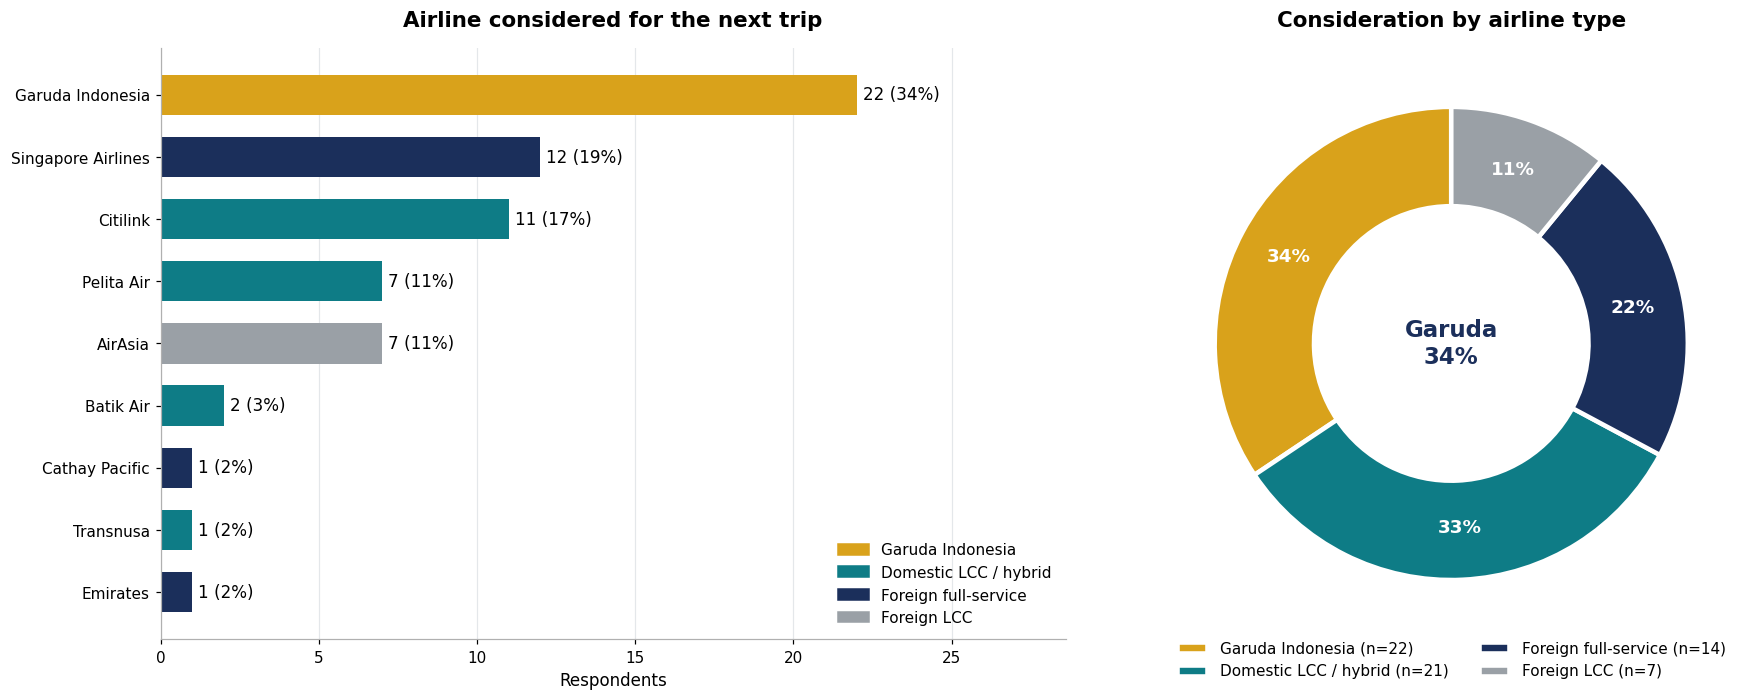

Would consider Garuda Indonesia next            : 22 of 64 (34%)
Garuda Group incl. Citilink                      : 33 of 64 (52%)
Foreign full-service (SQ / Cathay / Emirates)    : 14 (22%)


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5), gridspec_kw={"width_ratios": [1.15, 1]})
vc = df["next_airline"].value_counts()
colors = [GOLD if a == "Garuda Indonesia" else (TEAL if AIRLINE_GROUP[a] == "Domestic LCC / hybrid" else (NAVY if AIRLINE_GROUP[a] == "Foreign full-service" else GREY)) for a in vc.index]
bars = axes[0].barh(vc.index[::-1], vc.values[::-1], color=colors[::-1], height=0.65)
axes[0].bar_label(bars, labels=[f"{v} ({v/N*100:.0f}%)" for v in vc.values[::-1]], padding=4)
axes[0].set_xlim(0, vc.max()*1.3); axes[0].set_title("Airline considered for the next trip"); axes[0].set_xlabel("Respondents"); axes[0].grid(axis="y", visible=False)
axes[0].legend(handles=[Patch(color=GOLD, label="Garuda Indonesia"), Patch(color=TEAL, label="Domestic LCC / hybrid"),
                        Patch(color=NAVY, label="Foreign full-service"), Patch(color=GREY, label="Foreign LCC")], loc="lower right")

grp = df["airline_group"].value_counts()
grp_colors = {"Garuda Indonesia": GOLD, "Domestic LCC / hybrid": TEAL, "Foreign full-service": NAVY, "Foreign LCC": GREY}
wedges, texts, autotexts = axes[1].pie(grp.values, labels=None, colors=[grp_colors[g] for g in grp.index], startangle=90,
                                       autopct=lambda p: f"{p:.0f}%", pctdistance=0.78, wedgeprops=dict(width=0.42, edgecolor="white", linewidth=3),
                                       textprops=dict(color="white", fontsize=12, fontweight="bold"))
axes[1].legend(wedges, [f"{g} (n={v})" for g, v in grp.items()], loc="upper center", bbox_to_anchor=(0.5, 0.02), ncol=2)
axes[1].set_title("Consideration by airline type"); axes[1].text(0, 0, f"Garuda\n{df['considers_garuda'].mean()*100:.0f}%", ha="center", va="center", fontsize=15, fontweight="bold", color=NAVY)
finish(fig, "08_next_airline_consideration")

print(f"Would consider Garuda Indonesia next            : {df['considers_garuda'].sum()} of {N} ({df['considers_garuda'].mean()*100:.0f}%)")
print(f"Garuda Group incl. Citilink                      : {df['garuda_group'].sum()} of {N} ({df['garuda_group'].mean()*100:.0f}%)")
print(f"Foreign full-service (SQ / Cathay / Emirates)    : {(df['airline_group']=='Foreign full-service').sum()} ({(df['airline_group']=='Foreign full-service').mean()*100:.0f}%)")

**Insight - Garuda is the single most considered airline (34%), but two-thirds of youth look elsewhere.** The competition is not only LCCs: **Singapore Airlines alone attracts 19%** - young travelers who *want* a full-service experience but do not automatically see Garuda as the best one. Combined with Citilink, the Garuda Group captures just over half of consideration, which frames the strategic tension: how to lift Garuda mainline without simply cannibalising Citilink.

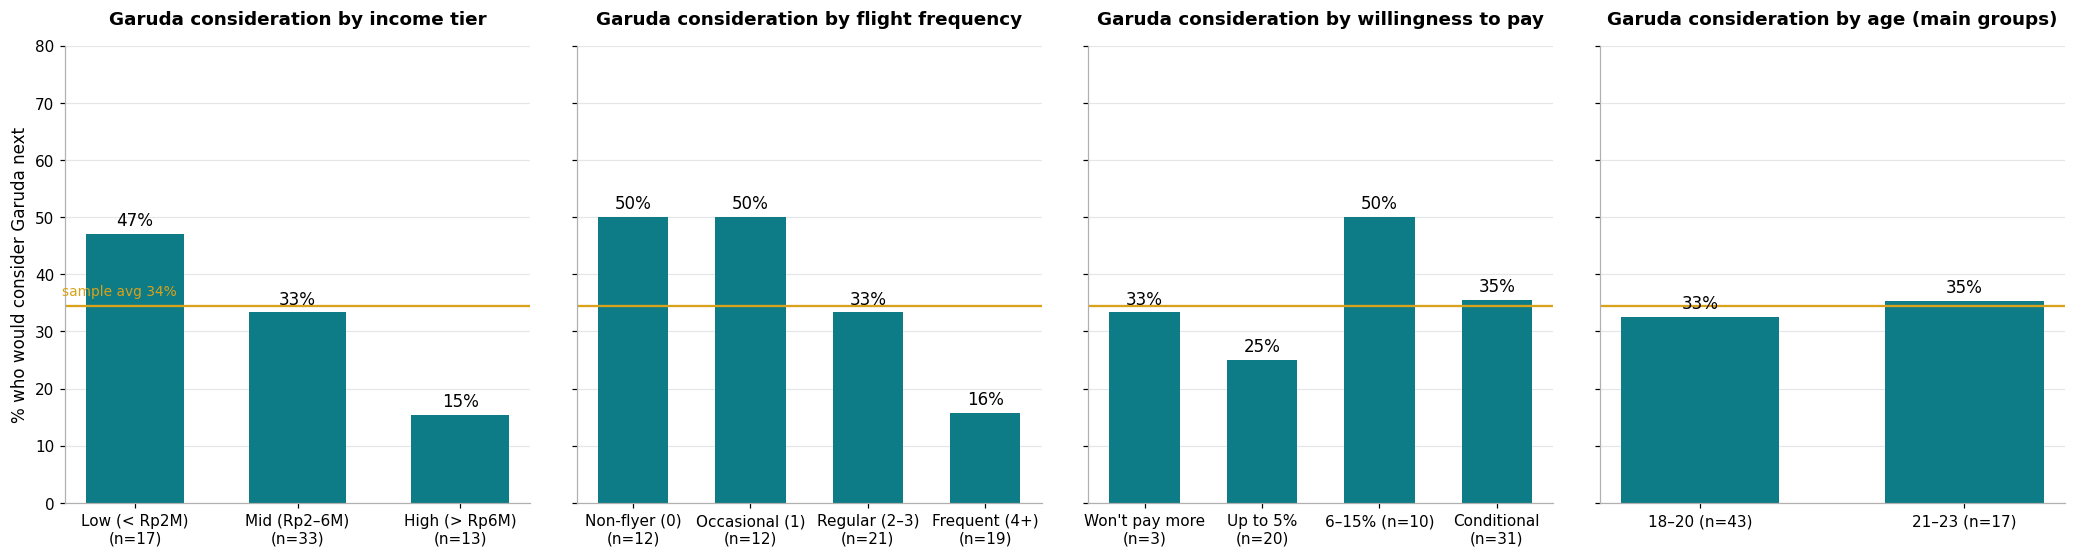

In [23]:
# ---- Who considers Garuda? Consideration rate by segment ---------------------
def rate_by(seg, order_):
    g = df.groupby(seg)["considers_garuda"].agg(["mean", "size"]).reindex(order_)
    g["mean"] *= 100
    return g

panels = [("income_tier", ["Low (< Rp2M)", "Mid (Rp2–6M)", "High (> Rp6M)"], "by income tier"),
          ("flyer_segment", ["Non-flyer (0)", "Occasional (1)", "Regular (2–3)", "Frequent (4+)"], "by flight frequency"),
          ("wtp_group", WTP_GROUP_ORDER, "by willingness to pay"),
          ("age", ["18–20", "21–23"], "by age (main groups)")]
fig, axes = plt.subplots(1, 4, figsize=(19, 5.2), sharey=True)
for ax, (seg, order_, ttl) in zip(axes, panels):
    g = rate_by(seg, order_)
    bars = ax.bar(wrap([f"{i}\n(n={int(n)})" for i, n in zip(g.index, g["size"])], 14), g["mean"], color=TEAL, width=0.6)
    ax.bar_label(bars, labels=[f"{v:.0f}%" for v in g["mean"]], padding=3)
    ax.axhline(df["considers_garuda"].mean()*100, color=GOLD, linewidth=1.5)
    ax.set_title(f"Garuda consideration {ttl}", fontsize=12); ax.set_ylim(0, 80); ax.grid(axis="x", visible=False)
axes[0].set_ylabel("% who would consider Garuda next")
axes[0].text(-0.45, df["considers_garuda"].mean()*100 + 2, f"sample avg {df['considers_garuda'].mean()*100:.0f}%", color=GOLD, fontsize=9)
finish(fig, "08b_garuda_consideration_by_segment")

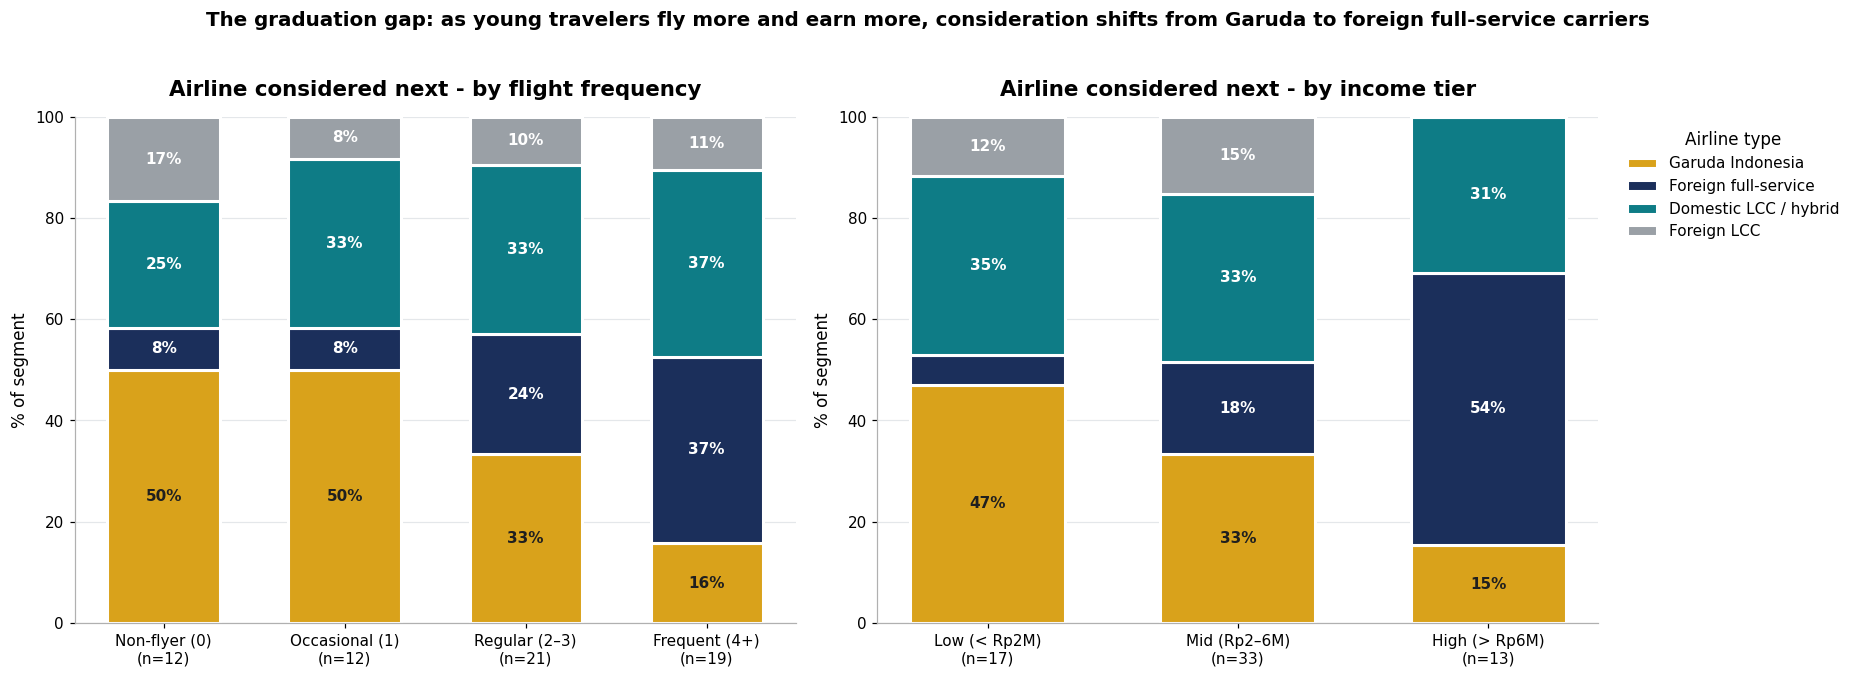

In [24]:
# ---- The "graduation gap": where does consideration go as youth fly more and earn more? ----
GROUP_ORDER = ["Garuda Indonesia", "Foreign full-service", "Domestic LCC / hybrid", "Foreign LCC"]
GROUP_COLOR = {"Garuda Indonesia": GOLD, "Foreign full-service": NAVY, "Domestic LCC / hybrid": TEAL, "Foreign LCC": GREY}

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
for ax, (seg, order_, ttl) in zip(axes, [("flyer_segment", ["Non-flyer (0)", "Occasional (1)", "Regular (2–3)", "Frequent (4+)"], "flight frequency"),
                                         ("income_tier", ["Low (< Rp2M)", "Mid (Rp2–6M)", "High (> Rp6M)"], "income tier")]):
    tab = (pd.crosstab(df[seg], df["airline_group"], normalize="index") * 100).reindex(index=order_, columns=GROUP_ORDER).fillna(0)
    n_by = df[seg].value_counts()
    bottom = np.zeros(len(tab))
    for gname in GROUP_ORDER:
        bars = ax.bar([f"{i}\n(n={n_by[i]})" for i in tab.index], tab[gname], bottom=bottom, color=GROUP_COLOR[gname], width=0.62,
                      label=gname, edgecolor="white", linewidth=2)
        for b, v in zip(bars, tab[gname]):
            if v >= 8:
                ax.text(b.get_x() + b.get_width()/2, b.get_y() + v/2, f"{v:.0f}%", ha="center", va="center", fontsize=10,
                        color=("white" if gname != "Garuda Indonesia" else INK), fontweight="bold")
        bottom += tab[gname].values
    ax.set_ylim(0, 100); ax.set_ylabel("% of segment"); ax.set_title(f"Airline considered next - by {ttl}"); ax.grid(axis="x", visible=False)
axes[1].legend(title="Airline type", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("The graduation gap: as young travelers fly more and earn more, consideration shifts from Garuda to foreign full-service carriers",
             fontsize=13, fontweight="bold", y=1.02)
finish(fig, "08b2_graduation_gap")

**Insight - the "graduation gap": Garuda is the default of the inexperienced, and loses travelers as they grow.** Consideration is **50% among non-flyers and occasional flyers, but only 16% among frequent flyers**, and it falls from 47% in the low-income tier to **15% in the high-income tier** - where **54% would rather fly Singapore Airlines or another foreign full-service carrier**. In other words, Garuda enjoys strong *aspirational* pull with young people who have barely flown, but the moment they gain income and flight experience they compare it with foreign premium carriers and drift away. Consideration is also highest among those who would pay a fixed 6-15% premium (50%) - the willing-to-pay youth exist; Garuda is losing the *experienced* ones. The strategic priority is therefore **retention through the growth curve** (a ladder from first flight to frequent flyer), not merely acquisition.

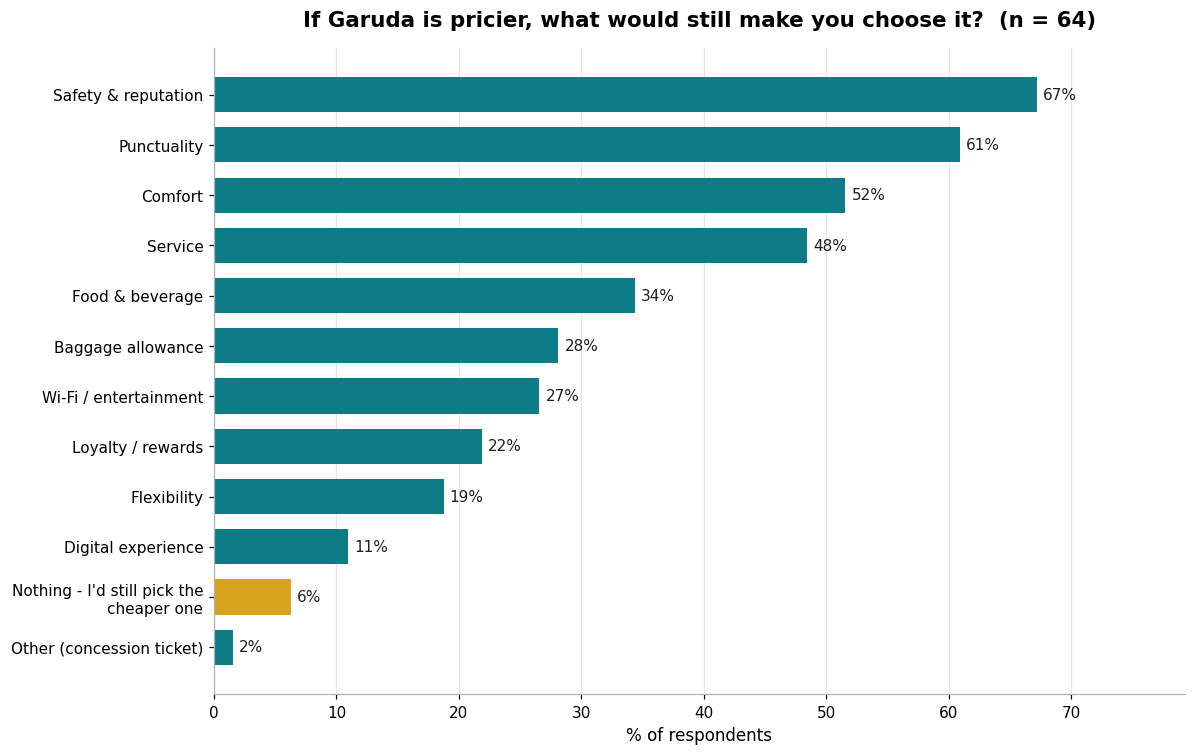

In [25]:
# ---- Retention levers: what keeps them on Garuda when it is pricier ------------
fig, ax = hbar_pct(multi_pct("garuda_stay_reasons"), "If Garuda is pricier, what would still make you choose it?",
                   n=N, figsize=(11, 7), highlight=["Nothing - I'd still pick the cheaper one"])
finish(fig, "08c_garuda_retention_levers")

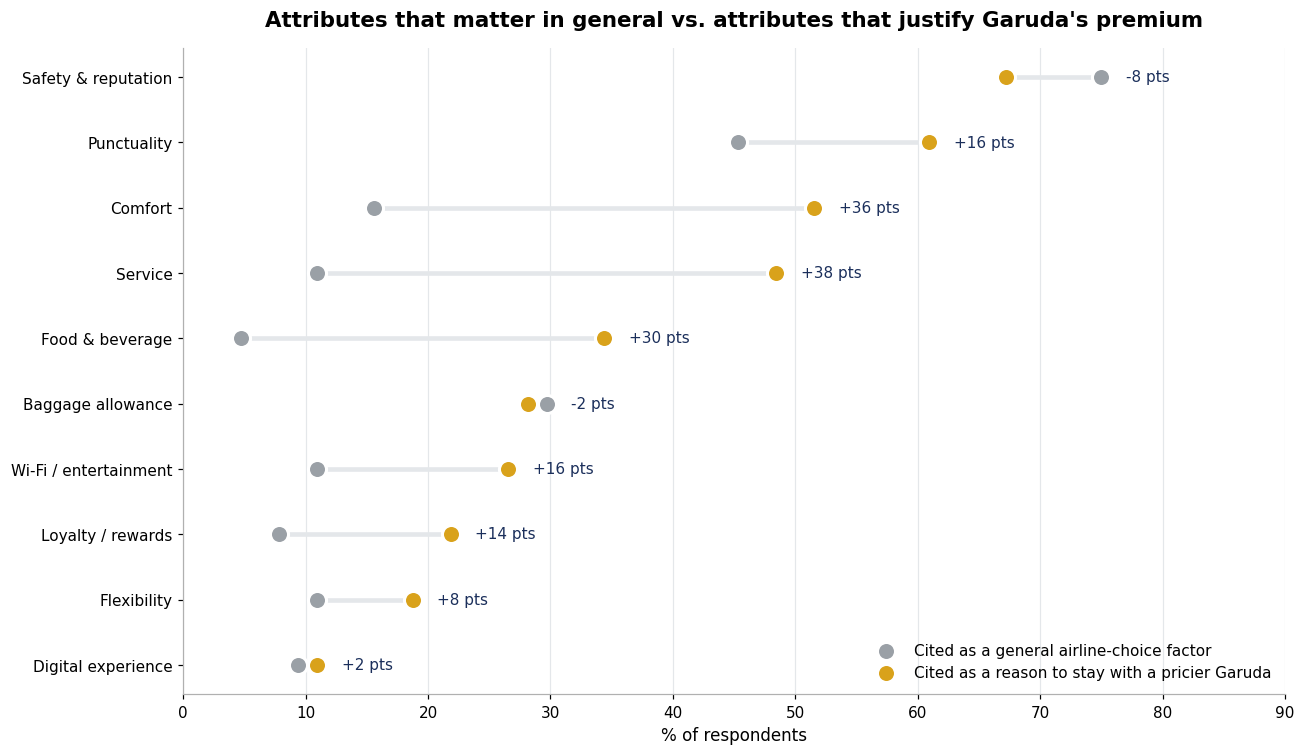

In [26]:
# ---- Dumbbell: general choice factor vs. reason to stay with pricier Garuda -----
align = {  # Garuda stay reason -> general choice factor(s) that map to it
    "Safety & reputation": ["Safety", "Airline reputation"], "Punctuality": ["Punctuality"], "Comfort": ["Seat / cabin comfort"],
    "Service": ["Cabin crew service"], "Food & beverage": ["Food & beverage"], "Baggage allowance": ["Baggage allowance"],
    "Wi-Fi / entertainment": ["Wi-Fi / entertainment"], "Loyalty / rewards": ["Loyalty points / rewards"],
    "Flexibility": ["Reschedule / refund flexibility"], "Digital experience": ["App / website ease"],
}
cfp, gsp = multi_pct("choice_factors"), multi_pct("garuda_stay_reasons")
cfi = IND["choice_factors"]
rows = []
for stay, general in align.items():
    rows.append({"Attribute": stay, "General": (cfi[general].sum(axis=1) > 0).mean()*100, "Garuda": gsp[stay]})
db = pd.DataFrame(rows).sort_values("Garuda")

fig, ax = plt.subplots(figsize=(12, 7))
for i, r in enumerate(db.itertuples()):
    ax.plot([r.General, r.Garuda], [i, i], color=LIGHTGREY, linewidth=3, zorder=1)
ax.scatter(db["General"], range(len(db)), s=140, color=GREY, label="Cited as a general airline-choice factor", zorder=3, edgecolor="white", linewidth=2)
ax.scatter(db["Garuda"], range(len(db)), s=140, color=GOLD, label="Cited as a reason to stay with a pricier Garuda", zorder=3, edgecolor="white", linewidth=2)
for i, r in enumerate(db.itertuples()):
    ax.text(max(r.General, r.Garuda) + 2, i, f"{r.Garuda - r.General:+.0f} pts", va="center", fontsize=10, color=NAVY)
ax.set_yticks(range(len(db))); ax.set_yticklabels(db["Attribute"])
ax.set_xlabel("% of respondents"); ax.set_xlim(0, 90); ax.grid(axis="y", visible=False)
ax.set_title("Attributes that matter in general vs. attributes that justify Garuda's premium"); ax.legend(loc="lower right")
finish(fig, "08d_choice_vs_garuda_levers")

**Insight - Garuda's licence to charge more is trust + reliability + comfort.** When the question shifts from "any airline" to "a pricier Garuda", **service (+37 pts), comfort (+36), food & beverage (+29) and punctuality (+16)** all jump, and safety & reputation - already table stakes in general - remains the single strongest lever at 67%. Only 6% say *nothing* would keep them. The brand equity is intact - Garuda's premium is credible **as long as it is framed as certainty and care rather than as luxury**.

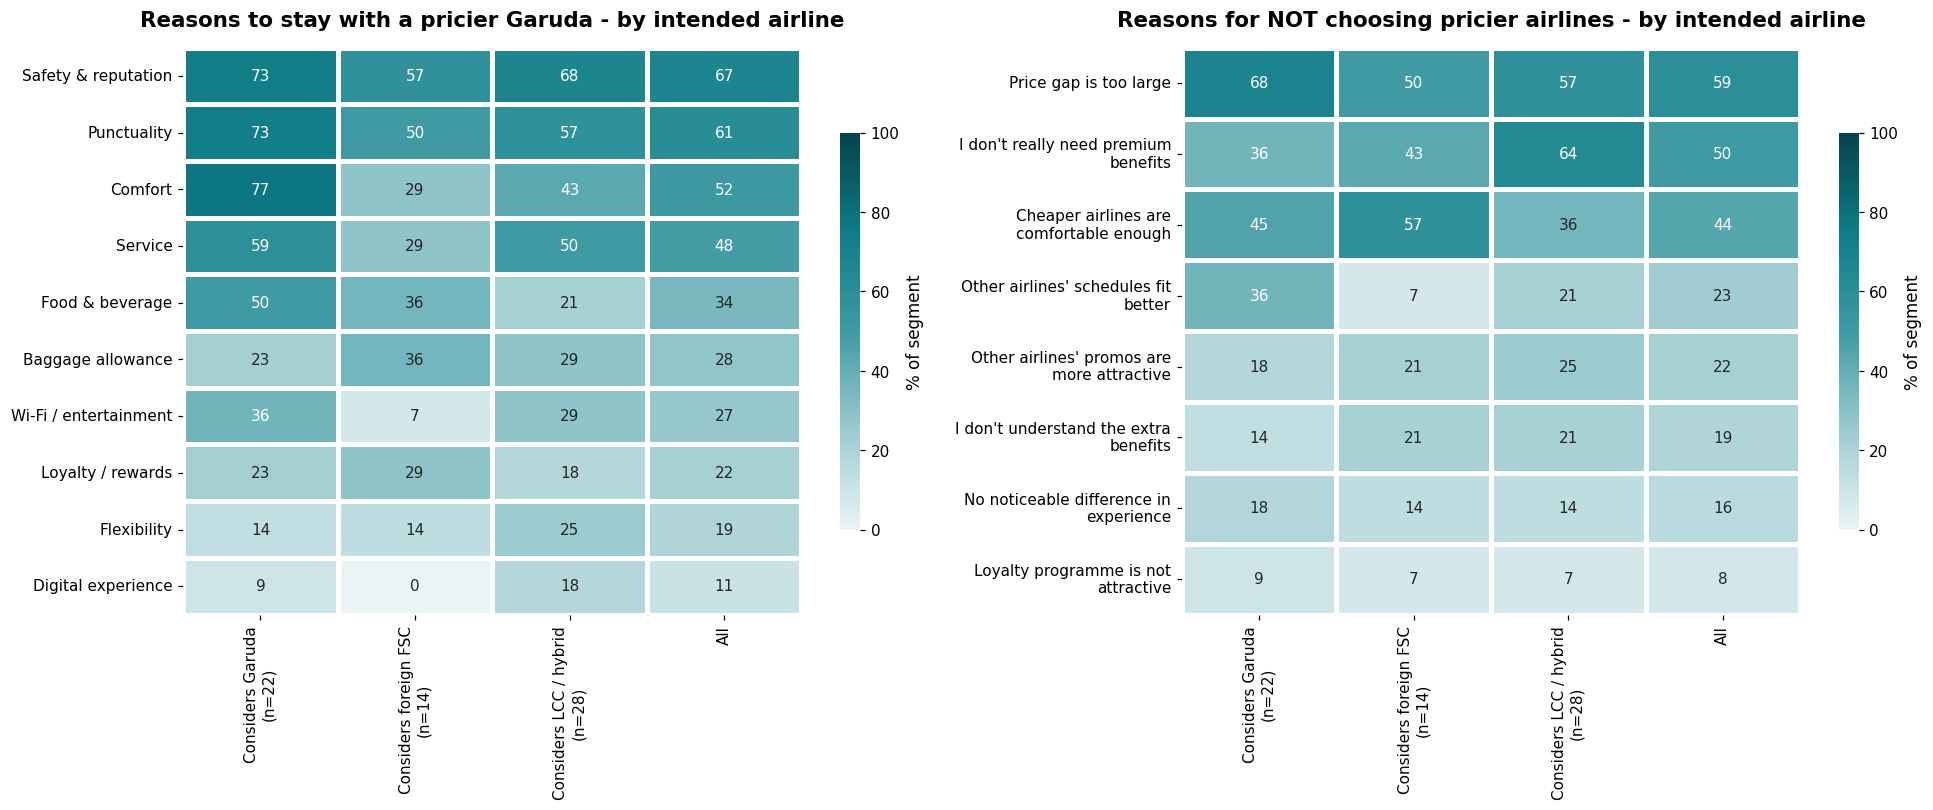

intent_group             Considers Garuda  Considers foreign FSC  Considers LCC / hybrid
wtp_num                              7.73                   5.83                    5.94
flights_num                          1.91                   5.21                    2.84
income_mid                           3.64                   8.89                    3.54
Value orientation                    4.14                   4.14                    4.13
Digital & convenience                4.26                   4.18                    4.46
In-flight experience                 4.25                   4.09                    4.29
Service & peace of mind              4.45                   4.45                    4.50
Loyalty & repeat                     3.99                   4.23                    4.23


In [27]:
# ---- Do Garuda-intenders and non-intenders want different things? ------------
df["intent_group"] = np.select([df["considers_garuda"], df["airline_group"] == "Foreign full-service"],
                               ["Considers Garuda", "Considers foreign FSC"], default="Considers LCC / hybrid")
INTENT_ORDER = ["Considers Garuda", "Considers foreign FSC", "Considers LCC / hybrid"]
df["intent_group"] = pd.Categorical(df["intent_group"], INTENT_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
seg_heatmap("garuda_stay_reasons", "intent_group", "Reasons to stay with a pricier Garuda - by intended airline", top=10, ax=axes[0], order=INTENT_ORDER)
seg_heatmap("reasons_not_premium", "intent_group", "Reasons for NOT choosing pricier airlines - by intended airline", top=8, ax=axes[1], order=INTENT_ORDER)
finish(fig, "08e_levers_by_intent_group")

print(df.groupby("intent_group")[["wtp_num", "flights_num", "income_mid"] + THEME_COLS].mean().round(2).rename(columns=lambda c: c.replace("theme_", "")).T.to_string())

**Insight - three different conversations.**
* **Garuda-intenders** credit Garuda with the whole package - comfort (77%), punctuality (73%), safety (73%), service (59%), food (50%) - and state the highest fixed WTP (7.7%). Yet their #1 barrier is still the **price gap (68%)** and, uniquely, *other airlines' schedules fit better* (36%): they want Garuda but need the gap to feel justified and the schedule/network to fit their routes. The job is to *convert and retain* them before income growth pulls them toward Singapore Airlines.
* **Foreign-FSC intenders** (mostly Singapore Airlines) are the highest-income, most frequent flyers (5.2 trips/yr, income ~Rp9M). They **do not credit Garuda with comfort or service (29% each)** and say cheaper airlines are comfortable enough (57%) - for them Garuda's premium is *undifferentiated*, not overpriced. Product consistency (fleet, IFE, crew) is the lever.
* **LCC / hybrid intenders** say they "don't need premium benefits" (64%) and the gap is too large (57%) - a *relevance* problem. They need a lean, legible entry product that makes the gap feel small and the benefit obvious, not a discount.

## 9. Data-Driven Segmentation - Young Traveler Personas (K-Means)

The case asks Garuda to segment youth "beyond age alone". We cluster respondents on **attitudes (5 theme scores), willingness to pay, flight frequency and income**, standardised, and choose the number of clusters with the silhouette score.

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

feat_cols = THEME_COLS + ["wtp_num", "flights_num", "income_mid"]
X = df[feat_cols].copy()
X["wtp_num"] = X["wtp_num"].fillna(df["wtp_num"].mean())   # 'depends' answers -> mean of fixed answers
X = X.fillna(X.mean())
Xs = StandardScaler().fit_transform(X)

sil = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=25, random_state=42).fit(Xs)
    sil[k] = silhouette_score(Xs, km.labels_)
best_k = max(sil, key=sil.get)
print("Silhouette score by k:", {k: round(v, 3) for k, v in sil.items()}, "-> best k =", best_k)

K = 3 if (best_k == 2 and sil[3] >= sil[2] - 0.03) else best_k   # prefer 3 personas if nearly as good as 2 (more actionable)
km = KMeans(n_clusters=K, n_init=25, random_state=42).fit(Xs)
df["cluster"] = km.labels_

prof = df.groupby("cluster")[feat_cols].mean()
prof["n"] = df["cluster"].value_counts().sort_index()
prof["Garuda consideration %"] = df.groupby("cluster")["considers_garuda"].mean()*100
prof["Foreign FSC %"] = df.groupby("cluster")["airline_group"].apply(lambda s: (s == "Foreign full-service").mean()*100)
prof["Conditional WTP %"] = df.groupby("cluster")["wtp_group"].apply(lambda s: (s == "Conditional").mean()*100)
prof.columns = [c.replace("theme_", "") for c in prof.columns]
print(f"\nCluster profile (K = {K}):")
print(prof.round(2).T.to_string())

Silhouette score by k: {2: 0.235, 3: 0.251, 4: 0.228, 5: 0.189, 6: 0.168} -> best k = 3

Cluster profile (K = 3):
cluster                      0      1      2
Value orientation         4.37   3.62   4.44
Digital & convenience     4.42   3.93   4.59
In-flight experience      4.14   3.73   4.62
Service & peace of mind   4.37   4.03   4.82
Loyalty & repeat          4.22   3.50   4.59
wtp_num                   5.00   6.43   6.76
flights_num               8.22   1.98   2.34
income_mid               12.89   2.96   3.74
n                         9.00  23.00  32.00
Garuda consideration %   11.11  39.13  37.50
Foreign FSC %            66.67  13.04  15.62
Conditional WTP %        77.78  39.13  46.88


{'Affluent Jet-Setters': 9, 'Experience Enthusiasts': 32, 'Pragmatic Budget Flyers': 23}


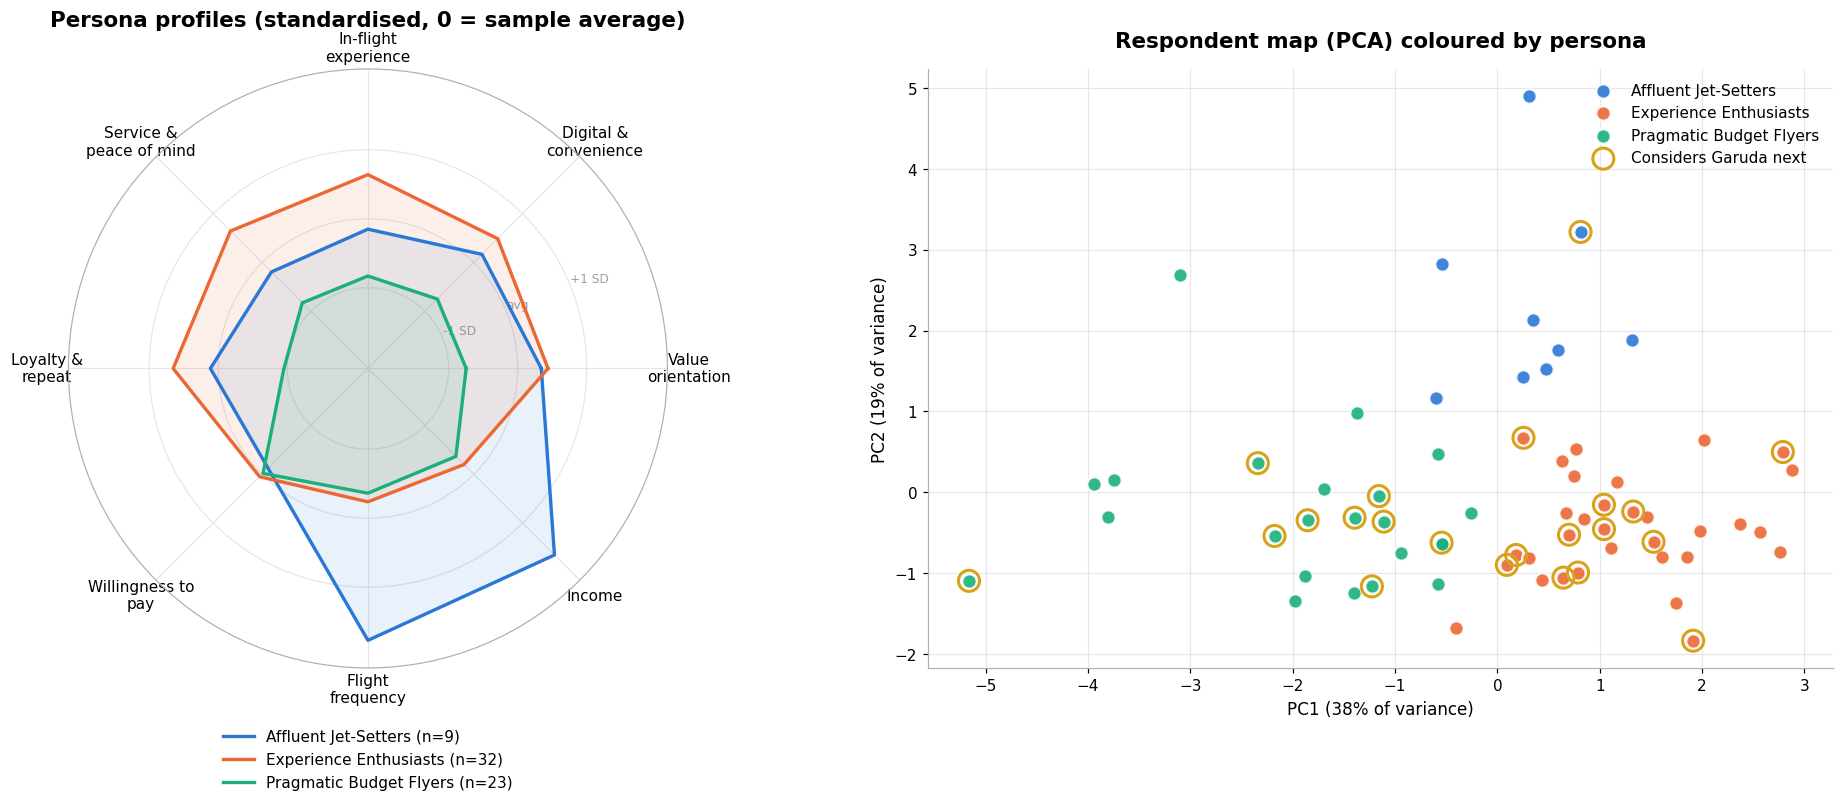

In [29]:
# ---- Name the personas from their profile (rule-based, so the names follow the data) ------
# 1) the cluster that flies (and earns) the most -> "Affluent Jet-Setters"
# 2) of the rest, the cluster with the strongest service/experience attitudes -> "Experience Enthusiasts"
# 3) the remaining cluster(s) -> "Pragmatic Budget Flyers"
PERSONA = {}
remaining = list(prof.index)
jet = prof.loc[remaining, "flights_num"].idxmax(); PERSONA[jet] = "Affluent Jet-Setters"; remaining.remove(jet)
if remaining:
    ent = prof.loc[remaining, "Service & peace of mind"].idxmax(); PERSONA[ent] = "Experience Enthusiasts"; remaining.remove(ent)
for i, c in enumerate(remaining):
    PERSONA[c] = "Pragmatic Budget Flyers" if i == 0 else f"Pragmatic Budget Flyers {i+1}"
df["persona"] = df["cluster"].map(PERSONA)
PERSONA_ORDER = [p for p in ["Affluent Jet-Setters", "Experience Enthusiasts", "Pragmatic Budget Flyers"] if p in PERSONA.values()] + \
                [p for p in PERSONA.values() if p not in ["Affluent Jet-Setters", "Experience Enthusiasts", "Pragmatic Budget Flyers"]]
PERSONA_COLOR = {p: CAT[i] for i, p in enumerate(PERSONA_ORDER)}
print({PERSONA[c]: int((df["cluster"] == c).sum()) for c in PERSONA})

# radar chart of standardised profiles
theme_short = [t for t in THEMES] + ["Willingness to pay", "Flight frequency", "Income"]
Z = pd.DataFrame(Xs, columns=feat_cols, index=df.index).groupby(df["persona"]).mean().reindex(PERSONA_ORDER)
angles = np.linspace(0, 2*np.pi, len(feat_cols), endpoint=False).tolist(); angles += angles[:1]

fig = plt.figure(figsize=(18, 7.5))
ax = fig.add_subplot(1, 2, 1, polar=True)
for p in PERSONA_ORDER:
    vals = Z.loc[p].tolist(); vals += vals[:1]
    ax.plot(angles, vals, color=PERSONA_COLOR[p], linewidth=2.2, label=f"{p} (n={int((df['persona']==p).sum())})")
    ax.fill(angles, vals, color=PERSONA_COLOR[p], alpha=0.10)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(wrap(theme_short, 14), fontsize=10)
lim = float(np.abs(Z.values).max()) + 0.4
ax.set_yticks([-1, 0, 1]); ax.set_yticklabels(["-1 SD", "avg", "+1 SD"], fontsize=8, color=GREY); ax.set_ylim(-lim, lim)
ax.set_title("Persona profiles (standardised, 0 = sample average)", pad=28); ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=1)

ax2 = fig.add_subplot(1, 2, 2)
pca = PCA(n_components=2, random_state=42).fit(Xs); P = pca.transform(Xs)
for p in PERSONA_ORDER:
    m = (df["persona"] == p).values
    ax2.scatter(P[m, 0], P[m, 1], s=90, color=PERSONA_COLOR[p], label=p, edgecolor="white", linewidth=1.5, alpha=0.9)
gm = df["considers_garuda"].values
ax2.scatter(P[gm, 0], P[gm, 1], s=190, facecolor="none", edgecolor=GOLD, linewidth=2, label="Considers Garuda next", zorder=4)
ax2.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% of variance)"); ax2.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% of variance)")
ax2.set_title("Respondent map (PCA) coloured by persona"); ax2.legend(loc="best")
finish(fig, "09_personas_radar_pca")

,Affluent Jet-Setters,Experience Enthusiasts,Pragmatic Budget Flyers
Respondents,9,32,23
Share of sample,14%,50%,36%
Avg flights / yr,8.2,2.3,2.0
Income > Rp6M,67%,16%,9%
Fixed WTP 6-15%,0%,19%,17%
Conditional WTP,78%,47%,39%
Value orientation (1-5),4.37,4.44,3.62
Service & peace of mind (1-5),4.37,4.82,4.03
Loyalty & repeat (1-5),4.22,4.59,3.5
Considers Garuda next,11%,38%,39%


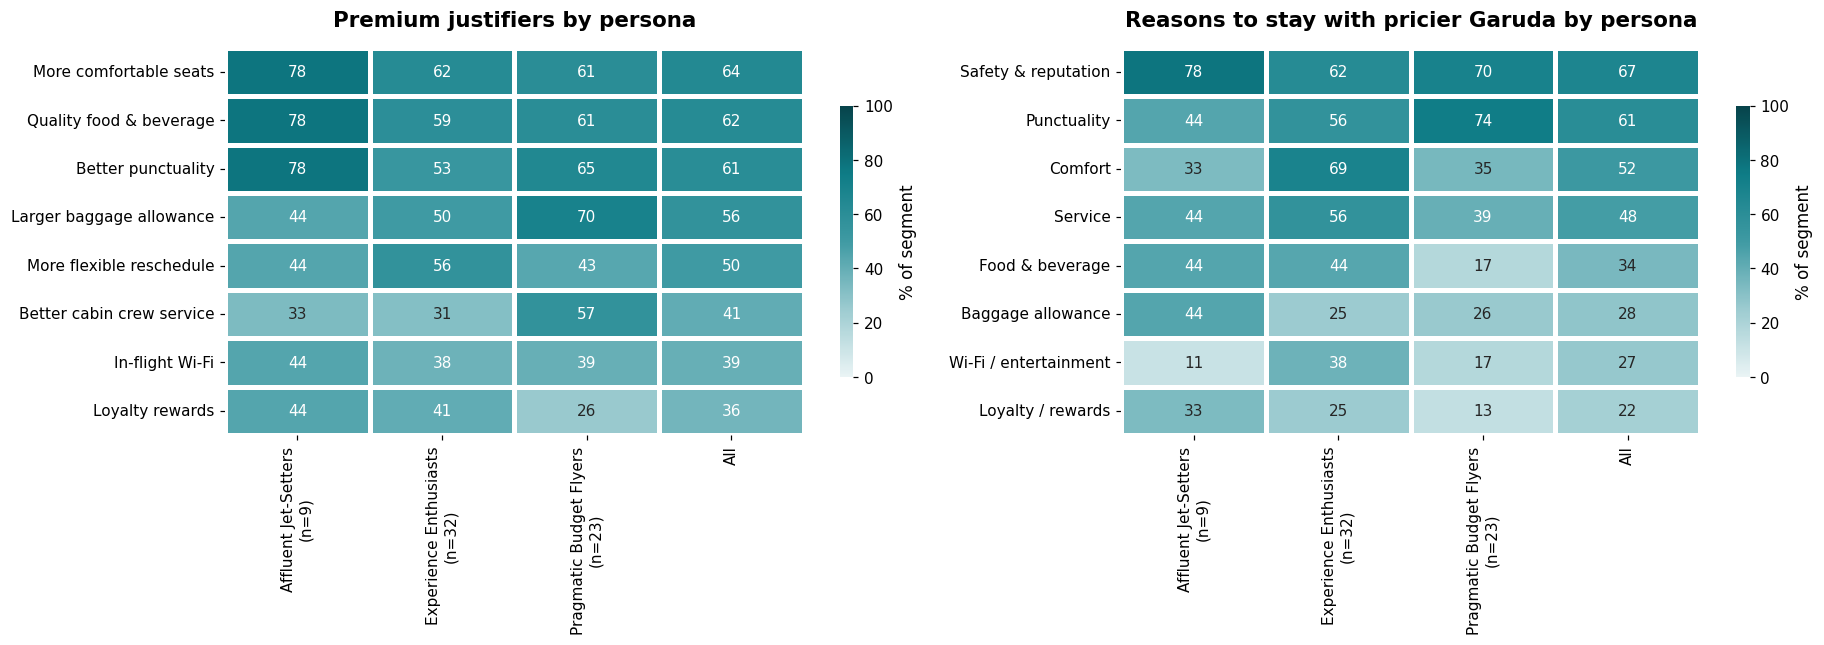

In [30]:
# ---- Persona scorecard --------------------------------------------------------
card = pd.DataFrame(index=PERSONA_ORDER)
g = df.groupby("persona")
card["Respondents"] = g.size()
card["Share of sample"] = (g.size()/N*100).round(0).astype(int).astype(str) + "%"
card["Avg flights / yr"] = g["flights_num"].mean().round(1)
card["Income > Rp6M"] = (g["income_tier"].apply(lambda s: (s == "High (> Rp6M)").mean()*100)).round(0).astype(int).astype(str) + "%"
card["Fixed WTP 6-15%"] = (g["wtp_group"].apply(lambda s: (s == "6–15%").mean()*100)).round(0).astype(int).astype(str) + "%"
card["Conditional WTP"] = (g["wtp_group"].apply(lambda s: (s == "Conditional").mean()*100)).round(0).astype(int).astype(str) + "%"
card["Value orientation (1-5)"] = g["theme_Value orientation"].mean().round(2)
card["Service & peace of mind (1-5)"] = g["theme_Service & peace of mind"].mean().round(2)
card["Loyalty & repeat (1-5)"] = g["theme_Loyalty & repeat"].mean().round(2)
card["Considers Garuda next"] = (g["considers_garuda"].mean()*100).round(0).astype(int).astype(str) + "%"
card["Considers foreign FSC"] = (g["airline_group"].apply(lambda s: (s == "Foreign full-service").mean()*100)).round(0).astype(int).astype(str) + "%"
card["Top trip purposes"] = [", ".join(multi_pct("trip_purpose", df["persona"] == p).head(3).index) for p in PERSONA_ORDER]
card["Top premium justifiers"] = [", ".join(multi_pct("worth_it_benefits", df["persona"] == p).head(3).index) for p in PERSONA_ORDER]
display(card.T)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
seg_heatmap("worth_it_benefits", "persona", "Premium justifiers by persona", top=8, ax=axes[0], order=PERSONA_ORDER, min_n=3)
seg_heatmap("garuda_stay_reasons", "persona", "Reasons to stay with pricier Garuda by persona", top=8, ax=axes[1], order=PERSONA_ORDER, min_n=3)
finish(fig, "09b_persona_benefit_heatmaps")

**How to read the personas.** The clustering separates the cohort along two axes - *travel capacity* (income x frequency) and *attitude toward the premium experience* - rather than by age:

* **Affluent Jet-Setters (≈14%)** - ~8 flights a year, two-thirds earn > Rp6M, 78% say their premium is "conditional on the benefit", and they fly mainly for study and leisure. They are the most valuable young travelers in the sample, yet **two-thirds would choose a foreign full-service carrier next and only ~1 in 10 Garuda**. Their premium justifiers are punctuality, seats and food. *Strategy: win back on consistency* - reliability guarantees, cabin/IFE consistency on their routes, and a youth tier of GarudaMiles with travel-based rewards (the reward type they like most).
* **Experience Enthusiasts (≈50%)** - the largest group; moderate income, 2-3 flights a year, the **highest scores on every attitude theme** (service 4.8, loyalty 4.6) and the highest share willing to pay a fixed 6-15% premium. Garuda consideration is highest here (~38%). *Strategy: make the value legible and shareable* - transparent Comfort+/Certainty+ bundles surfaced inside OTAs, creator content around leisure and *mudik* trips, and referral mechanics so their enthusiasm recruits peers.
* **Pragmatic Budget Flyers (≈36%)** - the lowest income and the weakest attitudes toward premium (value orientation 3.6, loyalty 3.5), flying about twice a year. They still consider Garuda at the sample average because it is the *default trusted name*, but they are the most price-anchored. *Strategy: nurture, don't discount* - Citilink as the entry point with a visible upgrade path, campus touchpoints, and baggage-led bundles for homecoming trips.

(Cluster sizes and exact metrics are in the scorecard above; with n = 64 the personas are indicative and should be validated on a larger sample.)

## 10. What Statistically Separates Garuda Considerers from the Rest?

To move from description to evidence we (a) compare Garuda-intenders vs. others on every numeric variable with a non-parametric test, and (b) fit a regularised logistic regression to see which factors, jointly, predict Garuda consideration. With n = 64 these are directional, but they discipline the storyline.

Variables most associated with considering Garuda next (sorted by p-value):
                                                Variable  Garuda-intenders  Others   Diff  Cohen's d  p-value (Mann-Whitney)
                                          Flights / year             1.909   3.631 -1.722     -0.603                   0.022
    I like rewards based on trips / destinations visited             3.864   4.167 -0.303     -0.343                   0.125
                                 Income (Rp M, midpoint)             3.643   5.321 -1.679     -0.338                   0.131
                                 THEME: Loyalty & repeat             3.992   4.226 -0.234     -0.344                   0.152
        I value proactive staff help when problems arise             4.455   4.643 -0.188     -0.339                   0.196
   Loyalty points / rewards make me re-choose an airline             3.773   4.071 -0.299     -0.312                   0.237
                                    Stated fixed 

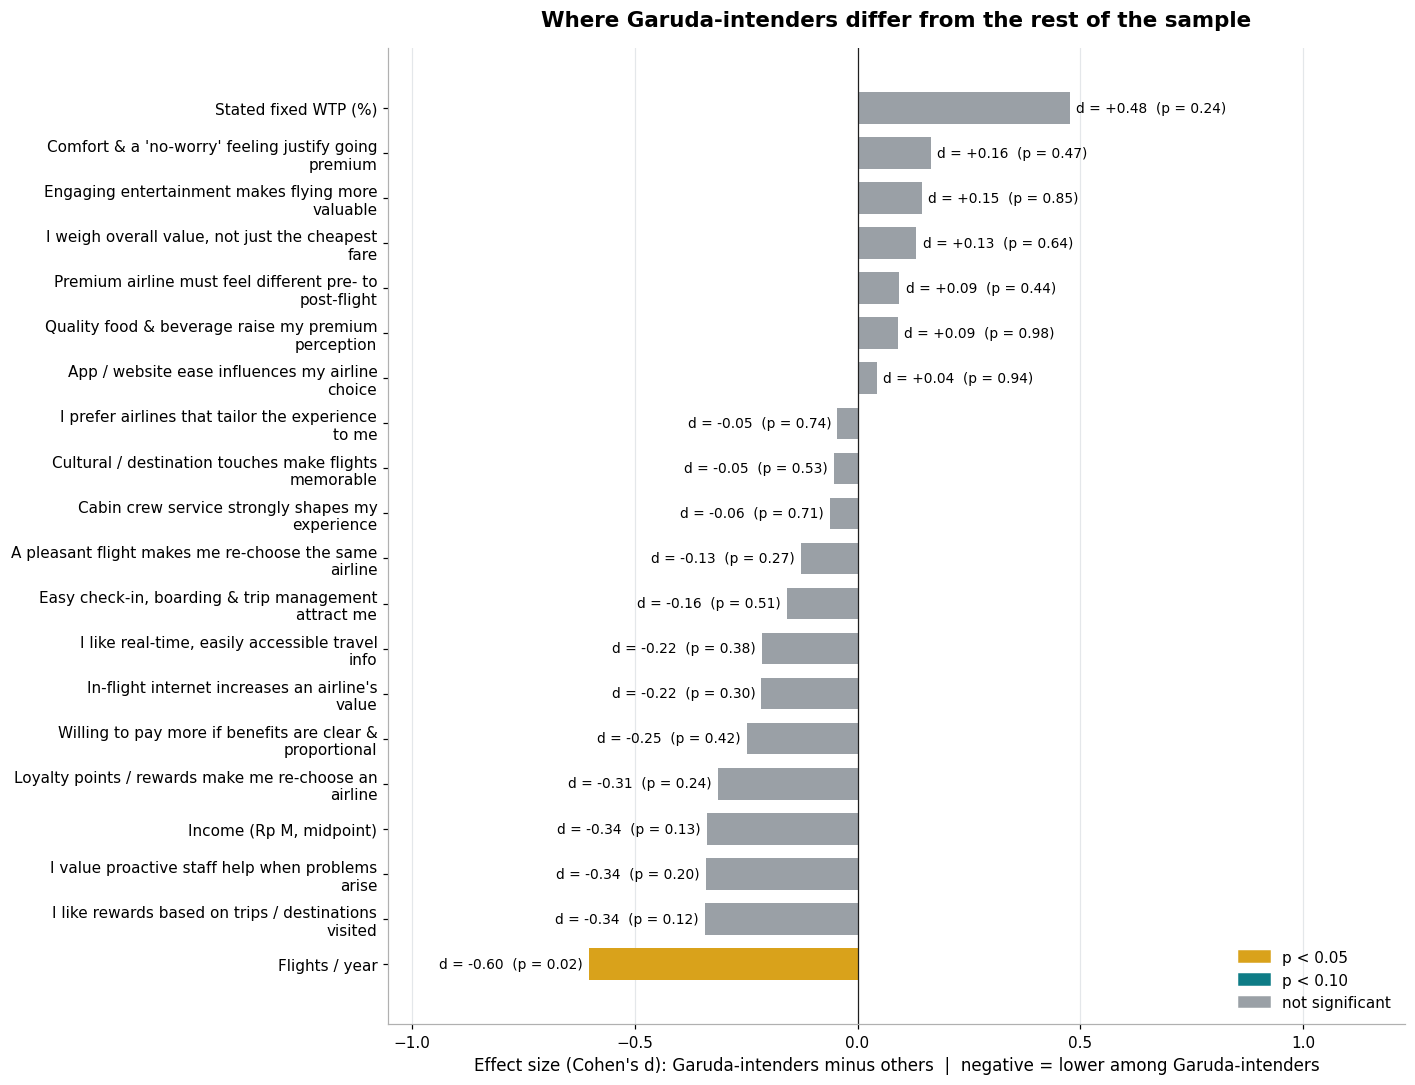

In [31]:
num_vars = {**{c: LIKERT_LABELS[c] for c in LIKERT_COLS}, **{c: c.replace("theme_", "THEME: ") for c in THEME_COLS},
            "wtp_num": "Stated fixed WTP (%)", "flights_num": "Flights / year", "income_mid": "Income (Rp M, midpoint)"}
def cohens_d(a, b):
    sp = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / sp if sp > 0 else 0.0

rows = []
for c, lab in num_vars.items():
    a = df.loc[df["considers_garuda"], c].dropna(); b = df.loc[~df["considers_garuda"], c].dropna()
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    rows.append({"Variable": lab, "Garuda-intenders": a.mean(), "Others": b.mean(), "Diff": a.mean()-b.mean(),
                 "Cohen's d": cohens_d(a, b), "p-value (Mann-Whitney)": p})
tests = pd.DataFrame(rows).sort_values("p-value (Mann-Whitney)")
print("Variables most associated with considering Garuda next (sorted by p-value):")
print(tests.head(12).round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 10))
t = tests[~tests["Variable"].str.startswith("THEME")].sort_values("Cohen's d")
colors = [GOLD if p < 0.05 else (TEAL if p < 0.10 else GREY) for p in t["p-value (Mann-Whitney)"]]
bars = ax.barh(wrap(t["Variable"], 46), t["Cohen's d"], color=colors, height=0.7)
ax.axvline(0, color=INK, linewidth=0.8)
ax.bar_label(bars, labels=[f"d = {d:+.2f}  (p = {p:.2f})" for d, p in zip(t["Cohen's d"], t["p-value (Mann-Whitney)"])], padding=4, fontsize=9)
ax.set_xlabel("Effect size (Cohen's d): Garuda-intenders minus others  |  negative = lower among Garuda-intenders")
ax.set_title("Where Garuda-intenders differ from the rest of the sample"); ax.grid(axis="y", visible=False)
ax.set_xlim(min(t["Cohen's d"].min(), 0) - 0.45, max(t["Cohen's d"].max(), 0) + 0.75)
ax.legend(handles=[Patch(color=GOLD, label="p < 0.05"), Patch(color=TEAL, label="p < 0.10"), Patch(color=GREY, label="not significant")], loc="lower right")
finish(fig, "10_garuda_intenders_vs_others")

5-fold CV ROC-AUC = 0.62 ± 0.11 | accuracy = 0.58 (majority-class baseline 0.66)


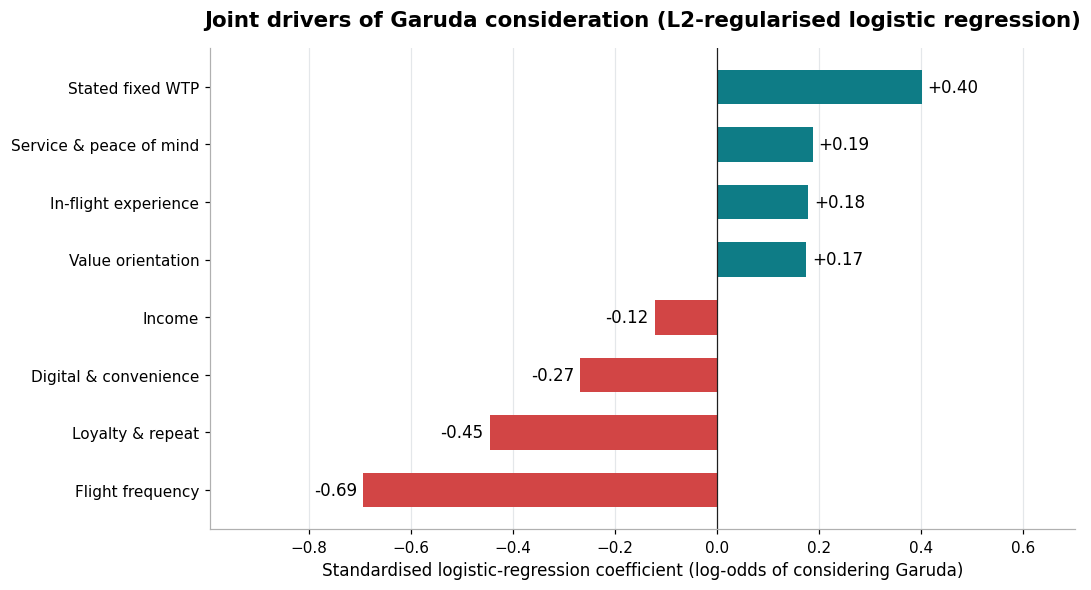

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline

model_feats = THEME_COLS + ["wtp_num", "flights_num", "income_mid"]
Xm = df[model_feats].copy()
Xm["wtp_num"] = Xm["wtp_num"].fillna(Xm["wtp_num"].mean()); Xm = Xm.fillna(Xm.mean())
y = df["considers_garuda"].astype(int)

pipe = make_pipeline(StandardScaler(), LogisticRegression(C=0.5, max_iter=1000))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc = cross_val_score(pipe, Xm, y, cv=cv, scoring="roc_auc")
acc = cross_val_score(pipe, Xm, y, cv=cv, scoring="accuracy")
pipe.fit(Xm, y)
coef = pd.Series(pipe[-1].coef_[0], index=[f.replace("theme_", "") for f in model_feats]).sort_values()
coef.index = coef.index.str.replace("wtp_num", "Stated fixed WTP").str.replace("flights_num", "Flight frequency").str.replace("income_mid", "Income")

print(f"5-fold CV ROC-AUC = {auc.mean():.2f} ± {auc.std():.2f} | accuracy = {acc.mean():.2f} (majority-class baseline {1-y.mean():.2f})")
fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(coef.index, coef.values, color=[TEAL if v > 0 else "#D24545" for v in coef.values], height=0.6)
ax.axvline(0, color=INK, linewidth=0.8); ax.bar_label(bars, labels=[f"{v:+.2f}" for v in coef.values], padding=4)
ax.set_xlabel("Standardised logistic-regression coefficient (log-odds of considering Garuda)")
ax.set_title("Joint drivers of Garuda consideration (L2-regularised logistic regression)"); ax.grid(axis="y", visible=False)
ax.set_xlim(min(coef.min(), 0) - 0.3, max(coef.max(), 0) + 0.3)
finish(fig, "10b_logistic_drivers")

**Insight - Garuda's consideration problem is an *experience* problem, not an *attitude* problem.** Attitudes barely separate Garuda-intenders from everyone else - all young travelers want service, ease and peace of mind. The one statistically significant separator is **flight frequency (negative, p ≈ 0.02)**: the more a young person flies, the *less* likely they are to pick Garuda, with income pointing the same way. In the joint model, flight frequency and the *loyalty & repeat* theme carry the largest negative weights while *stated fixed WTP* is the strongest positive one: Garuda-intenders are willing to pay a bit more, but they are **not** the ones who care most about loyalty rewards - which means today's GarudaMiles is neither what attracts them nor what retains the frequent flyers who care about rewards. The weak cross-validated AUC (≈0.6 at n = 64) is itself informative: **nothing in "what youth value" predicts choosing Garuda - the lived comparison with other carriers does.** Hence the strategy must change what experienced young flyers *experience and remember*, not only what they *believe*.

## 11. Voice of the Customer - Open-Ended Answers

Two optional free-text questions asked what airlines in general, and Garuda specifically, should improve. We (1) code every answer into themes with a transparent keyword dictionary, (2) show the most frequent words (translated to English), and (3) surface representative verbatims.

Airlines in general: what should improve?: 24 substantive answers out of 64 respondents
Garuda Indonesia: what should be developed?: 25 substantive answers out of 64 respondents


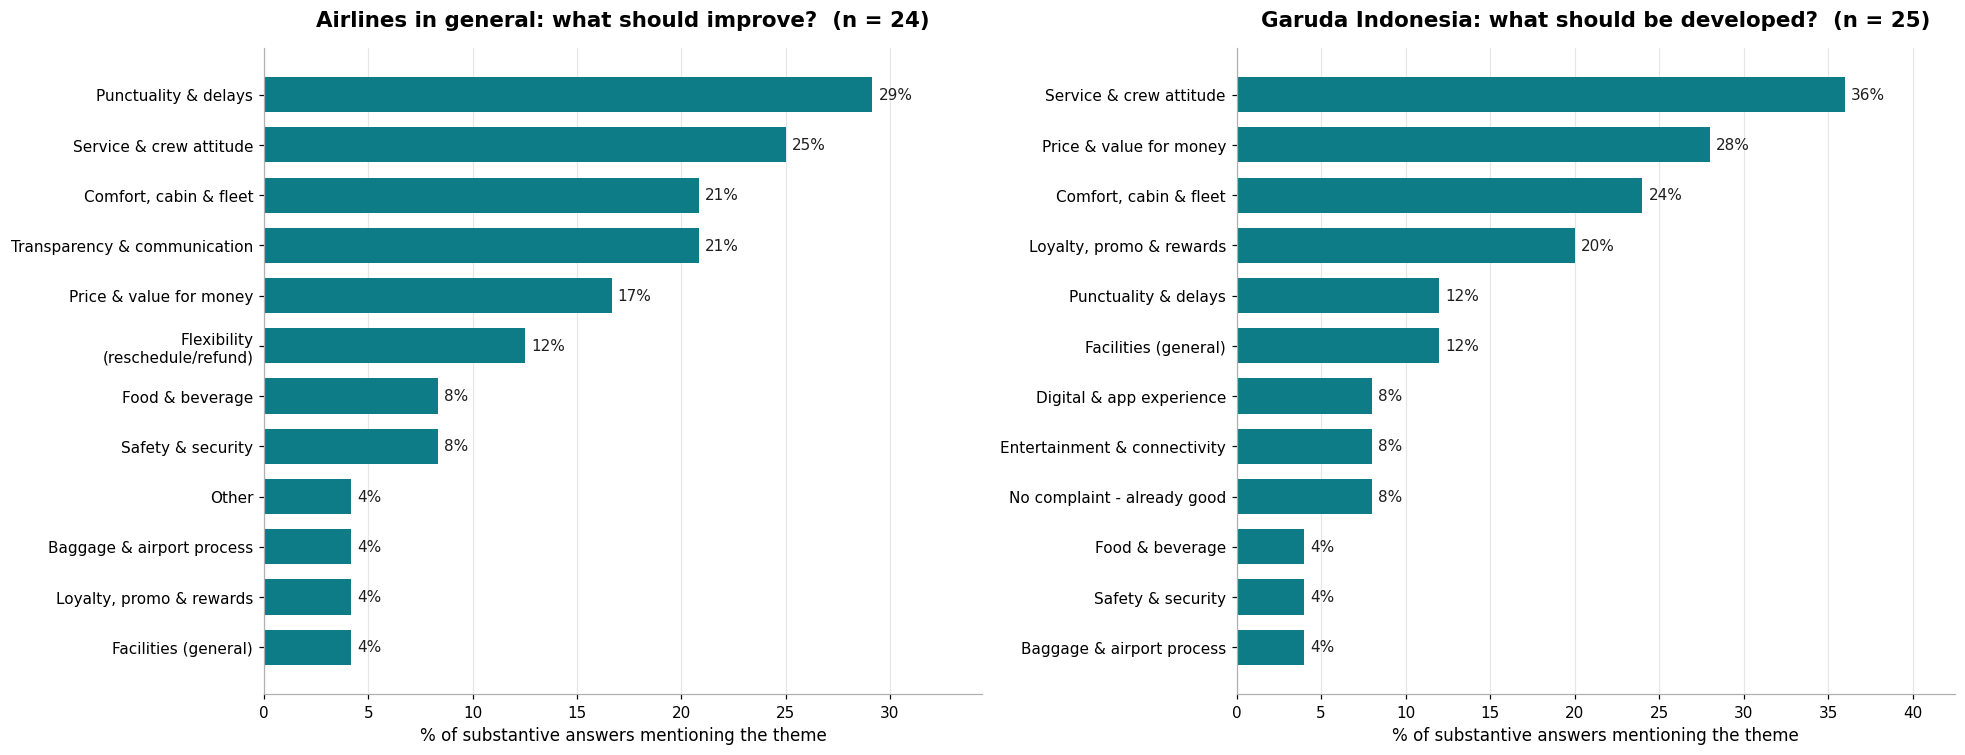

In [33]:
NON_ANSWERS = {"-", "", "tidak ada", "tidak adaa", "tidak ada jugaa", "imisstxhuhu", "belum ada karena saya jarang naik pesawat",
               "saya belum pernah naik garuda indonesia, jadi belum tau banget"}
NO_COMPLAINT = ["sudah bagus", "udah bagus", "sudah sangat bagus"]

# keyword patterns are regular expressions; \b guards short words (e.g. 'aman' must not match 'kenyamanan')
THEME_RULES = {
    "Punctuality & delays":            [r"tepat", r"delay", r"jadwal", r"\bwaktu", r"efisen", r"efisien"],
    "Price & value for money":         [r"harga", r"\bprice", r"mahal", r"\bfare", r"tercekik", r"sebanding", r"\bvalue", r"monopoli"],
    "Service & crew attitude":         [r"pelayanan", r"service", r"pramugar", r"\bcrew", r"\bstaf", r"judes", r"\brude", r"ramah", r"hospitality", r"proaktif", r"response", r"manajemen"],
    "Comfort, cabin & fleet":          [r"nyaman", r"legroom", r"\bspace", r"kursi", r"armada", r"\bfleet", r"interior", r"usang", r"\btua\b", r"lini pesawat"],
    "Flexibility (reschedule/refund)": [r"reschedule", r"refund", r"fleksib", r"cancel"],
    "Food & beverage":                 [r"\bmakan", r"cemilan", r"\bminum", r"snack", r"porsi"],
    "Entertainment & connectivity":    [r"entertainment", r"\bife\b", r"wi-?fi", r"layar", r"monitor", r"internet"],
    "Loyalty, promo & rewards":        [r"promo", r"reward", r"\bpoin", r"\bpoint", r"cashback", r"diskon", r"loyalty", r"upgrade"],
    "Digital & app experience":        [r"\bapps?\b", r"digital", r"aplikasi", r"akses"],
    "Transparency & communication":    [r"transparan", r"komunikasi", r"informasi", r"kejelasan", r"peraturan", r"dipertanggungjawabkan", r"turbulence", r"kondisi"],
    "Safety & security":               [r"\baman\b", r"keamanan"],
    "Baggage & airport process":       [r"bagasi", r"\bgate", r"boarding", r"overhead"],
    "Facilities (general)":            [r"fasilitas", r"facilities"],
}

def code_text(text):
    if not isinstance(text, str):
        return None
    t = text.strip().lower()
    if t in NON_ANSWERS or "tipu" in t:
        return None
    if any(k in t for k in NO_COMPLAINT):
        return ["No complaint - already good"]
    hits = [theme for theme, pats in THEME_RULES.items() if any(re.search(p, t) for p in pats)]
    return hits or ["Other"]

coded = {}
for col, label in [("open_improve_general", "Airlines in general: what should improve?"), ("open_improve_garuda", "Garuda Indonesia: what should be developed?")]:
    c = df[col].apply(code_text)
    valid = c.dropna()
    cnt = Counter(t for lst in valid for t in lst)
    coded[label] = (pd.Series(cnt).sort_values(ascending=False) / len(valid) * 100, len(valid))
    print(f"{label}: {len(valid)} substantive answers out of {N} respondents")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (label, (s, n)) in zip(axes, coded.items()):
    hbar_pct(s, label, xlabel="% of substantive answers mentioning the theme", ax=ax, n=n, wrap_w=30)
finish(fig, "11_open_ended_themes")

**Insight - for airlines in general the #1 complaints are punctuality and service attitude, plus transparency when things go wrong; for Garuda specifically it is service consistency, price-versus-facilities and an ageing product.** When asked about Garuda, respondents talk about *crew and ground-staff attitude* (the most frequent theme), *fares that feel disproportionate to the facilities* (fleet, laggy IFE screens), and *promotions / loyalty mechanics* that could make the fare feel fairer. Nobody asks Garuda to become cheap; they ask it to **make the premium feel justified and consistent**.

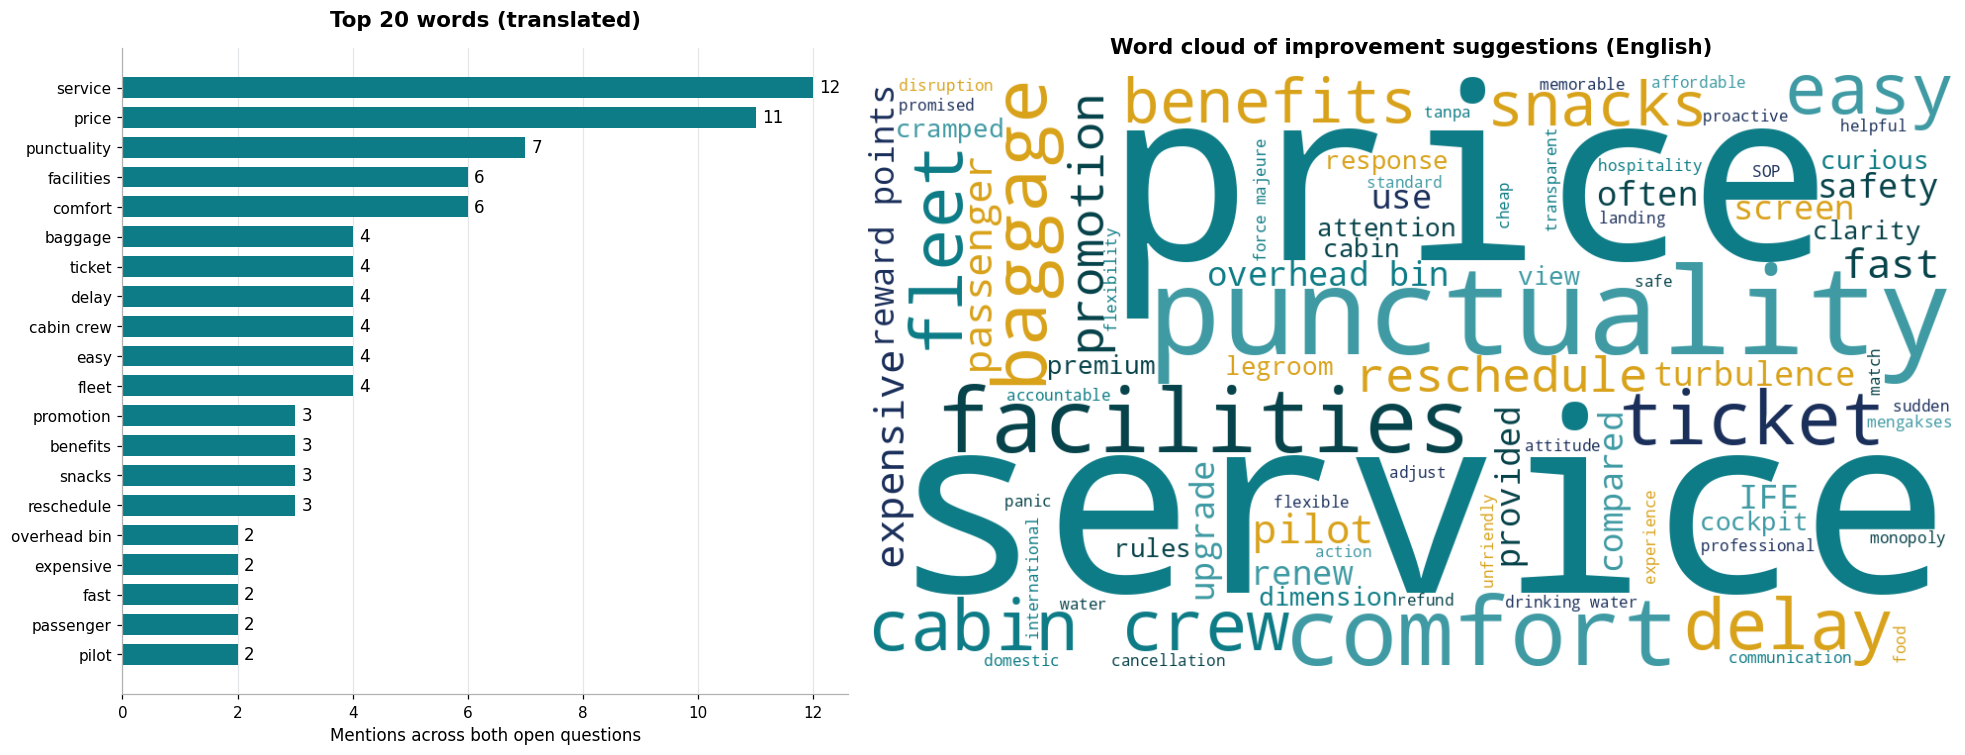

In [34]:
# ---- Most frequent words (Indonesian tokens translated to English) + word cloud --
STOP = set("""yang dan di ke dari untuk dengan pada saya aku juga ada tidak ga gak nya itu ini kalau kalo klo bisa lebih agar supaya
sudah udah jadi karena soalnya seperti misalkan misalnya atau apa apalagi bgt banget sangat masih menurut sih sihh yaa ya yaak
bagi para oleh serta akan harus perlu mungkin boleh saat ketika tapi tetapi terkadang kadang semua contoh cont sebagai
jauh mau bilang terima adanya sekarang khususnya dalam luar negeri baik hal segi lagi buat bs kl yg dgn sama
maupun namun selain jika nambah orang mereka kita gitu lah dong deh kan tuh dapat dapet sedikit
cuman pernah naik pesawat maskapai penerbangan airlines airline garuda indonesia penumpang pengalaman menggunakan
dikembangkan ditingkatkan tingkatkan meningkatkan improve improvements dibutuhkan diperlukan menurutku aja doang tau
tidaknya adalah ialah pun begitu bukan hanya tetap selama semoga memilih dilaksanakan seharusnya benar memang
dipaksa alasan pengguna dipastikan tentunya klo yaa memungkinkan menarik banyak kurang short medium long flight
kelas rendah termasuk dilengkapkan terkendala mendasar ngerti dunia sulit marginnya tipis sebaiknya permainan
kongkalikong dihentikan walau sebenarnya kemahalan paling perbanyak jangan kejauhan boleh masuk terutama cukup membuat
sedang terus terlalu keluar turun merasa per daripada bawa jujurr diliat sediain rasa kuat mengetahui menghadapi lainnya
perjalanan benar exceed dimension allow take off full bagasikan permen ringan sudah pengalaman bagus bs jadi seharusnya
melebihi bisa mengembangkan terkadang selain dapat kualitas menjadi salah satu cara mereka lebih ketika menarik
benar-benar sekali sekalipun kondisi terjadi secara berasal kembali sihhh dll lion""".split())

TRANSLATE = {
    "ketepatan": "punctuality", "tepat": "punctuality", "waktu": "time", "delay": "delay", "jadwal": "schedule",
    "harga": "price", "harganya": "price", "mahal": "expensive", "tiket": "ticket", "murah": "cheap", "fare": "fare",
    "pelayanan": "service", "service": "service", "pelayanannya": "service", "pramugari": "cabin crew", "pramugara": "cabin crew",
    "staff": "staff", "ramah": "friendly", "keramahan": "friendliness", "judes": "unfriendly", "rude": "rude", "proaktif": "proactive",
    "kenyamanan": "comfort", "nyaman": "comfort", "kursi": "seat", "legroom": "legroom", "space": "space",
    "armada": "fleet", "fleet": "fleet", "interior": "interior", "usang": "outdated", "tua": "old", "memperbarui": "renew",
    "reschedule": "reschedule", "refund": "refund", "fleksibilitas": "flexibility", "fleksibel": "flexible", "gampang": "easy",
    "makanan": "food", "makan": "food", "cemilan": "snacks", "cemilannya": "snacks", "minum": "drinks", "minuman": "drinks", "porsi": "portion",
    "entertainment": "entertainment", "ife": "IFE", "layar": "screen", "monitor": "screen", "laggy": "laggy",
    "promo": "promo", "promosi": "promotion", "promotion": "promotion", "reward": "rewards", "poin": "points", "point": "points",
    "cashback": "cashback", "diskon": "discount", "loyalty": "loyalty", "upgrade": "upgrade",
    "fasilitas": "facilities", "fasilitasnya": "facilities", "facilities": "facilities", "app": "app", "digital": "digital",
    "transparant": "transparent", "transparan": "transparent", "komunikasi": "communication", "informasi": "information",
    "kejelasan": "clarity", "peraturan": "rules", "keamanan": "safety", "aman": "safe", "turbulence": "turbulence",
    "bagasi": "baggage", "gate": "gate", "kabin": "cabin", "cabin": "cabin", "kualitas": "quality", "konsisten": "consistent",
    "konsistensi": "consistency", "kompetitif": "competitive", "efisensi": "efficiency", "benefit": "benefits", "value": "value",
    "manajemen": "management", "response": "response", "sebanding": "proportionate", "restrukturisasi": "restructuring",
    "ekspansi": "expansion", "skytrax": "Skytrax", "pilot": "pilot", "pemandangan": "view", "hospitality": "hospitality",
    "pengembangan": "development", "business": "business", "ekonomi": "economy", "domestik": "domestic",
    "manfaat": "benefits", "penasaran": "curious", "memorable": "memorable", "terkenang": "memorable", "sikap": "attitude",
    "ruangan": "cockpit", "proses": "process", "pelanggan": "customer", "experience": "experience", "affordable": "affordable",
    "air": "water", "overhead": "overhead bin", "passanger": "passenger", "sop": "SOP", "standard": "standard", "helpfull": "helpful",
    "panik": "panic", "kendala": "disruption", "mendadak": "sudden", "cancel": "cancellation", "force": "force", "majeur": "majeure",
    "cepat": "fast", "gerak": "action", "dijanjikan": "promised", "profesional": "professional", "dipertanggungjawabkan": "accountable",
    "kualitasnya": "quality", "sesuai": "match", "diberikan": "provided", "international": "international", "average": "average",
    "sedikit": "slightly", "dibandingkan": "compared", "tercekik": "strangled", "selangit": "sky-high", "menyesuaikan": "adjust",
    "pengelolaan": "management", "kejelasan": "clarity", "dimensi": "dimension", "melebihi": "exceed", "full": "full",
    "gencar": "aggressive", "lini": "fleet", "monopoli": "monopoly", "kartu": "card", "kredit": "credit", "pake": "use",
    "cc": "credit card", "mudah": "easy", "permudah": "simplify", "reform": "reform", "total": "total", "jelas": "clear",
    "sering": "often", "diperhatikan": "attention", "fast": "fast", "menerbangkan": "fly", "tidur": "idle", "fokus": "focus",
    "sempit": "cramped", "bagus": "good", "turun": "declined", "landing": "landing", "premium": "premium", "kualitas": "quality",
    "pengalaman": "experience", "konsisten": "consistent", "penumpang": "passenger", "panik": "panic", "rasa": "feeling",
}

# multi-word expressions are collapsed first so that e.g. "ketepatan waktu" counts once as "punctuality"
PHRASES = {"ketepatan waktu": "punctuality", "tepat waktu": "punctuality", "ketepatan jadwal": "punctuality",
           "cabin crew": "cabin_crew", "ground staff": "ground_staff", "business class": "business_class",
           "kartu kredit": "credit_card", "force majeur": "force_majeure", "inflight entertainment": "IFE",
           "in-flight entertainment": "IFE", "digital experience": "digital_experience", "wi-fi": "wifi",
           "average delay time": "delay", "lini pesawat": "fleet", "air minum": "drinking_water", "poin reward": "reward_points",
           "loyalty/rewards": "loyalty rewards", "pramugari pramugara": "cabin_crew", "pramugari nya or pramugara nya": "cabin_crew"}

def tokens(text):
    if not isinstance(text, str) or text.strip().lower() in NON_ANSWERS or "tipu" in text.lower():
        return []
    t = text.lower()
    for ph, rep in PHRASES.items():
        t = t.replace(ph, rep)
    words = re.findall(r"[a-zA-Z_\-]{3,}", t)
    out = []
    for w in words:
        w = w.strip("-")
        if w in STOP or len(w) < 3:
            continue
        out.append(TRANSLATE.get(w, w).replace("_", " "))
    return out

all_tokens = [t for col in ["open_improve_general", "open_improve_garuda"] for v in df[col] for t in tokens(v)]
freq = Counter(all_tokens)
top_words = pd.Series(dict(freq.most_common(20))).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={"width_ratios": [1, 1.5]})
bars = axes[0].barh(top_words.index, top_words.values, color=TEAL, height=0.7)
axes[0].bar_label(bars, padding=4); axes[0].set_xlabel("Mentions across both open questions"); axes[0].set_title("Top 20 words (translated)")
axes[0].grid(axis="y", visible=False)

wc = WordCloud(width=1100, height=600, background_color="white", colormap=ListedColormap(["#0E7C86", "#1B2F5B", "#3F9AA3", "#D9A21B", "#07434A"]),
               max_words=80, prefer_horizontal=0.9, random_state=42, collocations=False).generate_from_frequencies(freq)
axes[1].imshow(wc, interpolation="bilinear"); axes[1].axis("off"); axes[1].set_title("Word cloud of improvement suggestions (English)")
finish(fig, "11b_wordcloud_top_words")

In [35]:
# ---- Representative verbatims (original + English translation) ---------------
quotes = [
    ("Punctuality & delays", "Ketepatan waktu sihhh, banyak banget maskapai dengan harga affordable tapi pelayanan kurang seperti sering delay dll",
     "Punctuality, honestly - so many airlines are affordable but the service is lacking, like frequent delays."),
    ("Price & value for money", "Harga selangit, fasilitas tidak sebanding. Harus memperbarui armada yang ada, soalnya sudah tua-tua dan usang.",
     "Sky-high prices, facilities don't match. They must renew the fleet - the planes are old and worn out."),
    ("Price & value for money", "Tiket garuda yang sedikit lebih mahal dibandingkan SQ akan tetapi fasilitas dan average delay time tidak lebih baik dibandingkan SQ",
     "Garuda tickets are slightly pricier than Singapore Airlines, yet facilities and average delay time are not better than SQ."),
    ("Service & crew attitude", "Pelayanan cabin crew dan ground staff nya (kadang rude bgt)",
     "The cabin crew and ground staff service (sometimes really rude)."),
    ("Service & crew attitude", "Ditingkatkan lagi sikap pramugari pramugara agar lebih proaktif dan tingkatkan experience bagi para penumpang agar lebih terkenang",
     "Improve the cabin crew's attitude to be more proactive, and raise the passenger experience so it becomes memorable."),
    ("Consistency end-to-end", "Garuda Indonesia perlu terus mengembangkan kualitas dan konsistensi pengalaman pelanggan, bukan hanya dari sisi pelayanan di dalam pesawat, tetapi juga dari proses sebelum hingga setelah penerbangan",
     "Garuda needs to keep developing the quality and consistency of the customer experience - not only on board, but from before until after the flight."),
    ("Loyalty, promo & rewards", "promotion nya di garuda indonesia misalkan promotion nya dapet cashback 5% kl pake cc atau bisa pake point di kartu kredit buat upgrade ke business class",
     "Garuda's promotions - e.g., 5% cashback when paying with a credit card, or using credit-card points to upgrade to business class."),
    ("Transparency & communication", "Aku ngerti kalau misalnya ada kendala penerbangan ... tapi be transparant aja yaa menurut aku",
     "I understand if there are flight disruptions ... but just be transparent, in my opinion."),
    ("Entertainment & connectivity", "inflight entertainment yang lebih banyak dan layar monitor yang tidak laggy",
     "More in-flight entertainment and screens that are not laggy."),
    ("Digital & app experience", "Value yang jelas. Digital experience total reform (permudah app). Penerbangan yang sering delay",
     "Clear value. A total reform of the digital experience (simplify the app). Flights are often delayed."),
    ("Flexibility (reschedule/refund)", "fleksibilitas reschedule dan gerak cepat saat cancel mendadak (force majeur)",
     "Flexible rescheduling and quick action when there are sudden cancellations (force majeure)."),
    ("Experience idea", "aku sebagai penumpang pesawat penasaran banget sama ruangan pilot dan apa pemandangan yang diliat pilot, jadi kalo memungkinkan pengalaman yang seperti ini mungkin menarik banget untuk dikembangkan.",
     "As a passenger I'm really curious about the cockpit and the view pilots see - if possible, an experience like that would be very interesting to develop."),
]
vb = pd.DataFrame(quotes, columns=["Theme", "Original (Indonesian)", "English translation"])
pd.set_option("display.max_colwidth", 200)
display(vb.style.set_properties(**{"text-align": "left", "white-space": "pre-wrap"}).hide(axis="index"))

Theme,Original (Indonesian),English translation
Punctuality & delays,"Ketepatan waktu sihhh, banyak banget maskapai dengan harga affordable tapi pelayanan kurang seperti sering delay dll","Punctuality, honestly - so many airlines are affordable but the service is lacking, like frequent delays."
Price & value for money,"Harga selangit, fasilitas tidak sebanding. Harus memperbarui armada yang ada, soalnya sudah tua-tua dan usang.","Sky-high prices, facilities don't match. They must renew the fleet - the planes are old and worn out."
Price & value for money,Tiket garuda yang sedikit lebih mahal dibandingkan SQ akan tetapi fasilitas dan average delay time tidak lebih baik dibandingkan SQ,"Garuda tickets are slightly pricier than Singapore Airlines, yet facilities and average delay time are not better than SQ."
Service & crew attitude,Pelayanan cabin crew dan ground staff nya (kadang rude bgt),The cabin crew and ground staff service (sometimes really rude).
Service & crew attitude,Ditingkatkan lagi sikap pramugari pramugara agar lebih proaktif dan tingkatkan experience bagi para penumpang agar lebih terkenang,"Improve the cabin crew's attitude to be more proactive, and raise the passenger experience so it becomes memorable."
Consistency end-to-end,"Garuda Indonesia perlu terus mengembangkan kualitas dan konsistensi pengalaman pelanggan, bukan hanya dari sisi pelayanan di dalam pesawat, tetapi juga dari proses sebelum hingga setelah penerbangan","Garuda needs to keep developing the quality and consistency of the customer experience - not only on board, but from before until after the flight."
"Loyalty, promo & rewards",promotion nya di garuda indonesia misalkan promotion nya dapet cashback 5% kl pake cc atau bisa pake point di kartu kredit buat upgrade ke business class,"Garuda's promotions - e.g., 5% cashback when paying with a credit card, or using credit-card points to upgrade to business class."
Transparency & communication,Aku ngerti kalau misalnya ada kendala penerbangan ... tapi be transparant aja yaa menurut aku,"I understand if there are flight disruptions ... but just be transparent, in my opinion."
Entertainment & connectivity,inflight entertainment yang lebih banyak dan layar monitor yang tidak laggy,More in-flight entertainment and screens that are not laggy.
Digital & app experience,Value yang jelas. Digital experience total reform (permudah app). Penerbangan yang sering delay,Clear value. A total reform of the digital experience (simplify the app). Flights are often delayed.


## 12. Key Insights & Implications for Garuda Indonesia

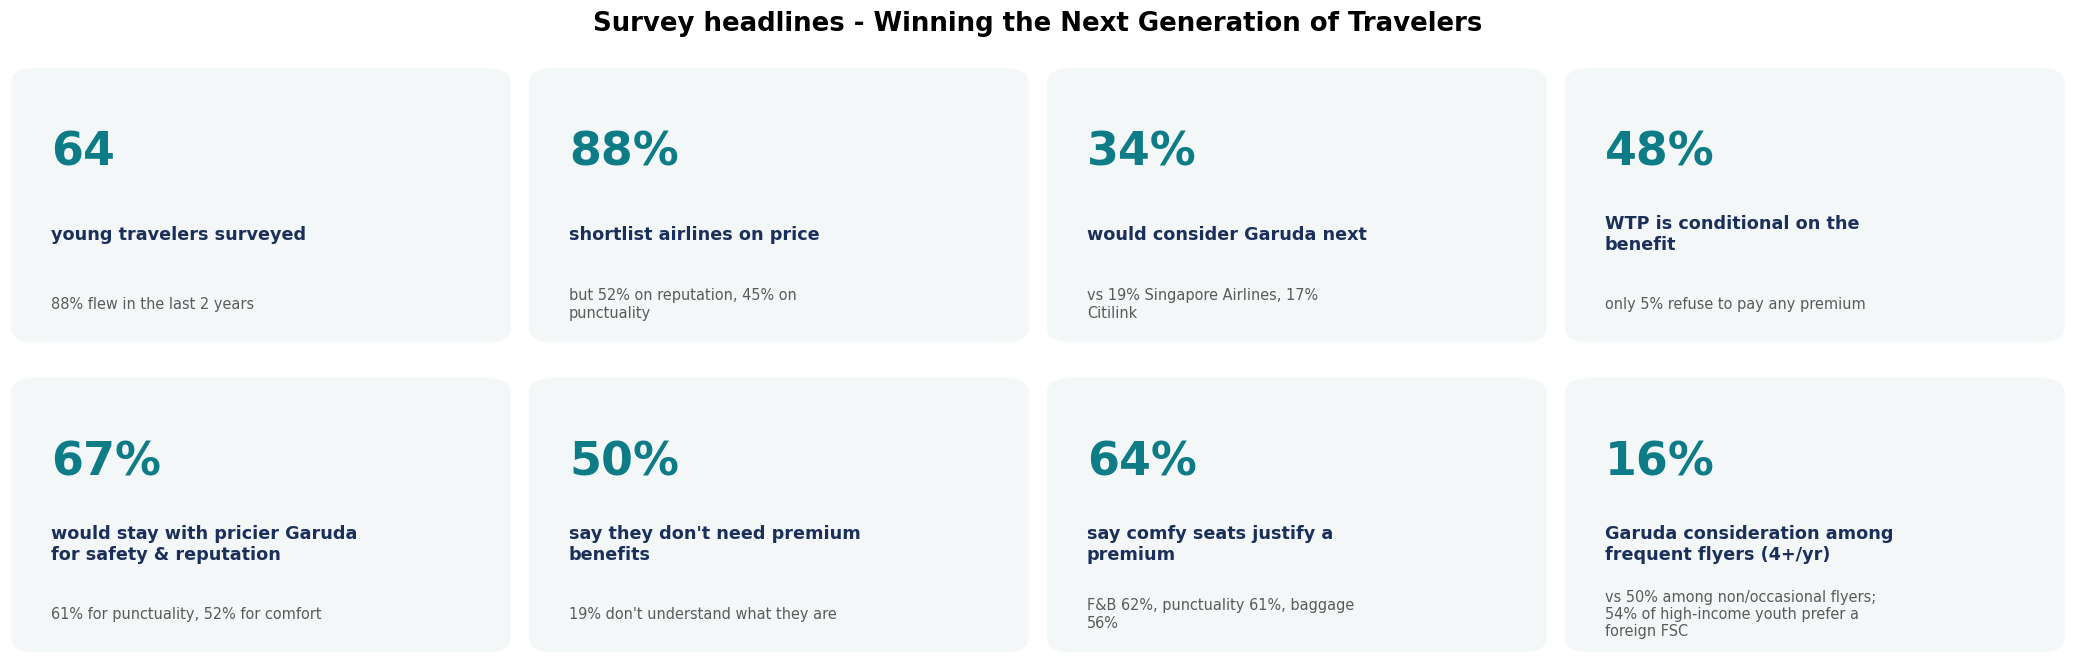

In [36]:
# ============================================================================
# 12.1 HEADLINE NUMBERS (computed live from the data)
# ============================================================================
cf, wb, gs, rp = multi_pct("choice_factors"), multi_pct("worth_it_benefits"), multi_pct("garuda_stay_reasons"), multi_pct("reasons_not_premium")
light = df["flyer_segment"].isin(["Non-flyer (0)", "Occasional (1)"]); freq = df["flyer_segment"] == "Frequent (4+)"
hi_inc = df["income_tier"] == "High (> Rp6M)"
tiles = [
    (f"{N}", "young travelers surveyed", f"{(df['flew_2y']=='Yes').mean()*100:.0f}% flew in the last 2 years"),
    (f"{cf['Ticket price']:.0f}%", "shortlist airlines on price", f"but {cf['Airline reputation']:.0f}% on reputation, {cf['Punctuality']:.0f}% on punctuality"),
    (f"{df['considers_garuda'].mean()*100:.0f}%", "would consider Garuda next", f"vs {(df['next_airline']=='Singapore Airlines').mean()*100:.0f}% Singapore Airlines, {(df['next_airline']=='Citilink').mean()*100:.0f}% Citilink"),
    (f"{(df['wtp_premium']=='Depends on benefit & trip').mean()*100:.0f}%", "WTP is conditional on the benefit", f"only {(df['wtp_premium']=='Not willing to pay more').mean()*100:.0f}% refuse to pay any premium"),
    (f"{gs['Safety & reputation']:.0f}%", "would stay with pricier Garuda for safety & reputation", f"{gs['Punctuality']:.0f}% for punctuality, {gs['Comfort']:.0f}% for comfort"),
    (f"{rp['I don' + chr(39) + 't really need premium benefits']:.0f}%", "say they don't need premium benefits", f"{rp['I don' + chr(39) + 't understand the extra benefits']:.0f}% don't understand what they are"),
    (f"{wb['More comfortable seats']:.0f}%", "say comfy seats justify a premium", f"F&B {wb['Quality food & beverage']:.0f}%, punctuality {wb['Better punctuality']:.0f}%, baggage {wb['Larger baggage allowance']:.0f}%"),
    (f"{df.loc[freq,'considers_garuda'].mean()*100:.0f}%", "Garuda consideration among frequent flyers (4+/yr)", f"vs {df.loc[light,'considers_garuda'].mean()*100:.0f}% among non/occasional flyers; {(df.loc[hi_inc,'airline_group']=='Foreign full-service').mean()*100:.0f}% of high-income youth prefer a foreign FSC"),
]
fig, axes = plt.subplots(2, 4, figsize=(19, 6.2))
for ax, (big, label, sub) in zip(axes.flat, tiles):
    ax.axis("off")
    ax.add_patch(mpl.patches.FancyBboxPatch((0.02, 0.05), 0.96, 0.9, boxstyle="round,pad=0.02,rounding_size=0.05", facecolor="#F3F7F8", edgecolor="none", transform=ax.transAxes))
    ax.text(0.08, 0.68, big, fontsize=30, fontweight="bold", color=TEAL, transform=ax.transAxes, va="center")
    ax.text(0.08, 0.40, textwrap.fill(label, 30), fontsize=11.5, fontweight="bold", color=NAVY, transform=ax.transAxes, va="center")
    ax.text(0.08, 0.16, textwrap.fill(sub, 36), fontsize=9.5, color="#5A5A5A", transform=ax.transAxes, va="center")
fig.suptitle("Survey headlines - Winning the Next Generation of Travelers", fontsize=17, fontweight="bold")
finish(fig, "12_headline_numbers")

### 12.2 The eight insights that matter

1. **Price is the entry ticket, not the decision.** 88% shortlist on price - but reputation, punctuality and safety come next, and hardly anyone shortlists on soft in-flight extras. Youth are *value-seeking*, not merely price-seeking.
2. **The barrier is legibility, not refusal.** Only ~5% refuse to pay any premium; half say "it depends on the benefit". Yet half also say they *don't need* premium benefits and one in five *don't understand* them. Garuda's premium is currently **invisible at the moment of choice** (an OTA price list).
3. **"Premium" to Gen-Z = tangible, trip-critical basics.** Comfortable seats, good food, punctuality, baggage and flexible rescheduling justify a higher fare; personalisation and destination perks do not (yet). Baggage is the top justifier for low-income youth, loyalty rewards for the affluent.
4. **Valued ≠ worth paying for.** Real-time info, proactive help and personalisation are *hygiene* - expected from everyone. Food, crew service and comfort are the *core premium* worth pricing. Wi-Fi and loyalty rewards are niche paid extras; the loyalty statement is the most divisive of all - today's miles logic does not fit young travelers.
5. **Garuda's brand equity is intact - as certainty and care.** When Garuda is pricier, two-thirds would still choose it for safety & reputation, 61% for punctuality, ~half for comfort and service. Only 6% say nothing would keep them.
6. **The graduation gap is the core problem.** Garuda is considered by 50% of non/occasional flyers but only 16% of frequent flyers, and by 47% of low-income vs 15% of high-income youth. The only statistically significant predictor of *not* considering Garuda is flying more. **Garuda wins the inexperienced and loses them as they grow.**
7. **The rival for premium youth is Singapore Airlines, not only LCCs.** One in five prefers a foreign full-service carrier - the highest-income, most frequent flyers - and they do not credit Garuda with comfort or service. Their words: ageing fleet, laggy IFE, inconsistent crew, "no better than SQ for a higher fare". A *consistency* problem, not a price problem.
8. **Segments beyond age.** K-Means yields three personas: *Affluent Jet-Setters* (14%, win back on consistency and travel-based rewards), *Experience Enthusiasts* (50%, make value legible and shareable), *Pragmatic Budget Flyers* (36%, nurture via Citilink and baggage-led bundles).

### 12.3 What this implies for the youth growth strategy

| Funnel stage | Evidence from the survey | Strategic implication (no fare dilution) |
|---|---|---|
| **Awareness** | 84% start on Traveloka / 64% Tiket.com; <30% touch airline channels; leisure, family and *mudik* dominate trip purposes | Surface Garuda's bundle value *inside* OTAs (benefit badges, side-by-side comparison) and reach youth through creators/campus content built around leisure & homecoming moments |
| **Consideration** | Reputation, punctuality, safety are the top non-price shortlisting factors; frequent flyers weigh punctuality & baggage most | Lead communication with an **on-time & care promise** (e.g., transparent delay communication, proactive rebooking) rather than luxury imagery |
| **Trial** | WTP is small (≤5%) and conditional; top justifiers are seat, meal, punctuality, baggage, flexibility | A transparent **youth fare family** ("Comfort+" and "Certainty+") that keeps the headline gap to LCCs small by *unbundling nothing essential but bundling what youth value* - verified student status, not blanket discounts |
| **Repeat / loyalty** | Consideration collapses from ~50% (occasional flyers) to 16% (frequent flyers); frequent flyers value travel-based rewards but do not consider Garuda | Build a **retention ladder** from first flight to frequent flyer: youth tier of GarudaMiles with experience- and destination-based rewards, status fast-track for verified students, credit-card / e-wallet tie-ins, and a visible upgrade path from Citilink |
| **Protect the core** | Foreign-FSC intenders (highest income, 5+ flights/yr) cite inconsistent service, ageing fleet and IFE | Prioritise **consistency of the basics** (crew attitude, IFE reliability, cabin refresh) on youth-heavy and international-competitive routes before adding new extras |

### 12.4 KPIs the pilot should track (mapped to the case's KPI framework)
* **Awareness:** qualified reach among 18-25 on OTA/social placements; aided recall of the youth proposition.
* **Consideration:** share who "would consider Garuda next" - baseline **34% overall and 16% among frequent flyers** in this survey - re-measured on the same instrument after the pilot.
* **Trial:** first-purchase rate of the youth bundle, verified-student redemptions, incremental pax vs. Citilink (cannibalisation check).
* **Repeat / loyalty:** youth-tier GarudaMiles enrolment & activity, repeat-booking rate within 12 months, share of 4+ flights/yr members retained, NPS on punctuality & crew attitude.

> **Limitations reminder.** n = 64, convenience sample, Jakarta-centric and student-heavy. Findings are directional and were used to *shape and prioritise* the strategy, complemented by public market data in the pitch deck.

In [37]:
# ============================================================================
# 12.5 EXPORT CLEAN DATASET & SUMMARY TABLES FOR THE PITCH DECK
# ============================================================================
df.to_csv("dataset_clean.csv", index=False, encoding="utf-8-sig")
with pd.ExcelWriter("survey_summary_tables.xlsx") as xw:
    for col in MULTI_MAPS:
        multi_pct(col).round(1).rename("% of respondents").to_frame().to_excel(xw, sheet_name=col[:31])
    summary.to_excel(xw, sheet_name="likert_summary")
    seg_tab.round(2).to_excel(xw, sheet_name="theme_by_segment")
    card.to_excel(xw, sheet_name="personas")
    tests.round(3).to_excel(xw, sheet_name="garuda_intender_tests", index=False)
print("Exported: dataset_clean.csv, survey_summary_tables.xlsx and", len(list(FIG_DIR.glob("*.png"))), "figures in", FIG_DIR.resolve())

Exported: dataset_clean.csv, survey_summary_tables.xlsx and 28 figures in C:\Users\ASUS\xStyNWx\Documents\BINUS University\Competition\2026\IMCC 2026\Repo\data-analysis\figures
